In [1]:
import os
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
import pandas as pd
import datetime
import copy
from scipy.stats import linregress
import colorcet as cc
from sklearn.neighbors import KernelDensity
from scipy.ndimage import label, binary_dilation, generate_binary_structure, filters, iterate_structure
import warnings

import seaborn as sns
import scipy.stats as st
from scipy.stats import pearsonr, spearmanr, linregress
import pingouin as pg

In [2]:
xr.__version__

'2024.2.0'

In [3]:
def list_dirs(in_dir):
    """
    List sub-directories.
    """
    dirs = []
    for it in os.scandir(in_dir):
        if it.is_dir():
            dirs.append(it.path)
    return dirs

def find_lasso_files(start_dates, root_datadir, in_basename, domain):
    files = []
    # Loop over dates
    for ii in range(0, len(start_dates)):
        # Get sub-directories (cases)
        idate = start_dates[ii]
        case_dirs = list_dirs(f'{root_datadir}/{idate}/')
        if len(case_dirs) > 0:
            # Loop over cases
            for icase in case_dirs:
                # Find config sub-directories
                # config_dirs = list_dirs(icase)
                config_dirs = [f'{icase}/base/']
                if len(config_dirs) > 0:
                    # Loop over configs
                    for iconfig in config_dirs:
                        # Find track stats file
                        fname = sorted(glob.glob(f'{iconfig}/{domain}/stats/{in_basename}*nc'))
                        if len(fname) > 0:
                            files.append(fname[0])
    return files

In [4]:
# LASSO case dates
start_dates = [
    "20181129", 
    "20181204",
    "20181205", 
    # "20181219", 
    "20190122", 
    "20190123",
    "20190125",
    "20190129",
    "20190208",
]

# LASSO tracking directory
# rootdir_les = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/'
# rootdir_meso = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso/'
rootdir_les = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/'
rootdir_meso = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/'
in_basename = 'trackstats_20'
in_basename_w = 'stats_3d_w_'
in_basename_wmask = 'stats_2d_wmask_'
in_basename_env = 'stats_1d_env_2location_'

# figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI/'
figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+1h/'
os.makedirs(figdir, exist_ok=True)

# Domain 4 boundaries
# lon_range = [-65., -63.1]
lon_range = [-65., -63.3]
lat_range = [-33., -30.8]
lifetime_range = [15, 1000]

# Environment location (0: fixed site, 1: CI location)
env_loc = 1
# Time for representative environment
time_env = -3

# Find LASSO files
files_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename, 'd2')
files_d3 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd3')
files_d4 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd4')
wfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_w, 'd2')
wfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd3')
wfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd4')
wmaskfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_wmask, 'd2')
wmaskfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_wmask, 'd3')
wmaskfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_wmask, 'd4')
efiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_env, 'd2')
efiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd3')
efiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd4')

print(f'Number of stats files (D2): {len(files_d2)}')
print(f'Number of W files (D2): {len(wfiles_d2)}')
print(f'Number of Wmask files (D2): {len(wmaskfiles_d2)}')
print(f'Number of ENV files (D2): {len(efiles_d2)}')

print(f'Number of stats files (D3): {len(files_d3)}')
print(f'Number of W files (D3): {len(wfiles_d3)}')
print(f'Number of Wmask files (D3): {len(wmaskfiles_d3)}')
print(f'Number of ENV files (D3): {len(efiles_d3)}')

print(f'Number of stats files (D4): {len(files_d4)}')
print(f'Number of W files (D4): {len(wfiles_d4)}')
print(f'Number of Wmask files (D4): {len(wmaskfiles_d4)}')
print(f'Number of ENV files (D4): {len(efiles_d4)}')

# files_d2, files_d3, files_d4, wfiles_d2, wfiles_d3, wfiles_d4

Number of stats files (D2): 17
Number of W files (D2): 17
Number of Wmask files (D2): 17
Number of ENV files (D2): 17
Number of stats files (D3): 17
Number of W files (D3): 17
Number of Wmask files (D3): 17
Number of ENV files (D3): 17
Number of stats files (D4): 17
Number of W files (D4): 17
Number of Wmask files (D4): 17
Number of ENV files (D4): 17


## Limit time window for analysis in each case
### The window is determined manually by examining cold pool animations to exclude periods when significant cold pools develop

In [5]:
# case_hours_dict_d2 = {
#     '20181129-gefs00': (12.0, 19.5),
#     '20181129-gefs03': (12.0, 20.0),
#     '20181129-gefs09': (12.0, 18.5),
#     '20181129-gefs18': (12.0, 18.5),
#     '20181204-gefs18': (12.0, 17.5),
#     '20181204-gefs19': (12.0, 19.0),
#     '20181205-gefs01': (12.0, 18.0),
#     '20181219-eda09': (12.0, 17.0),
#     '20190122-gefs01': (12.0, 21.5),
#     '20190122-gefs18': (12.0, 20.25),
#     '20190123-eda05': (12.0, 16.0),
#     '20190123-gefs18': (12.0, 17.5),
#     '20190125-eda07': (12.0, 18.5),
#     '20190125-gefs11': (12.0, 18.5),
#     '20190129-eda09': (12.0, 18.0),
#     '20190129-gefs11': (12.0, 17.5),
#     '20190208-eda03': (12.0, 19.5),
#     '20190208-eda08': (12.0, 19.75),
# }

In [6]:
# +1 h
case_hours_dict_d2 = {
    '20181129-gefs00': (12.0, 20.5),
    '20181129-gefs03': (12.0, 21.0),
    '20181129-gefs09': (12.0, 19.5),
    '20181129-gefs18': (12.0, 19.5),
    '20181204-gefs18': (12.0, 18.5),
    '20181204-gefs19': (12.0, 20.0),
    '20181205-gefs01': (12.0, 19.0),
    '20181219-eda09': (12.0, 18.0),
    '20190122-gefs01': (12.0, 22.5),
    '20190122-gefs18': (12.0, 21.25),
    '20190123-eda05': (12.0, 17.0),
    '20190123-gefs18': (12.0, 18.5),
    '20190125-eda07': (12.0, 19.5),
    '20190125-gefs11': (12.0, 19.5),
    '20190129-eda09': (12.0, 19.0),
    '20190129-gefs11': (12.0, 18.5),
    '20190208-eda03': (12.0, 20.5),
    '20190208-eda08': (12.0, 20.75),
}

In [7]:
# # +2 h
# case_hours_dict_d2 = {
#     '20181129-gefs00': (12.0, 21.5),
#     '20181129-gefs03': (12.0, 22.0),
#     '20181129-gefs09': (12.0, 20.5),
#     '20181129-gefs18': (12.0, 20.5),
#     '20181204-gefs18': (12.0, 19.5),
#     '20181204-gefs19': (12.0, 21.0),
#     '20181205-gefs01': (12.0, 20.0),
#     '20181219-eda09': (12.0, 19.0),
#     '20190122-gefs01': (12.0, 23.5),
#     '20190122-gefs18': (12.0, 22.25),
#     '20190123-eda05': (12.0, 18.0),
#     '20190123-gefs18': (12.0, 19.5),
#     '20190125-eda07': (12.0, 20.5),
#     '20190125-gefs11': (12.0, 20.5),
#     '20190129-eda09': (12.0, 20.0),
#     '20190129-gefs11': (12.0, 19.5),
#     '20190208-eda03': (12.0, 21.5),
#     '20190208-eda08': (12.0, 21.75),
# }

In [8]:
case_hours_dict_d3 = {
    '20181129-gefs00': (12.0, 19.5),
    '20181129-gefs03': (12.0, 20.0),
    '20181129-gefs09': (12.0, 19.0),
    '20181129-gefs18': (12.0, 19.0),
    '20181204-gefs18': (12.0, 17.5),
    '20181204-gefs19': (12.0, 19.0),
    '20181205-gefs01': (12.0, 18.0),
    '20181219-eda09': (12.0, 17.0),
    '20190122-gefs01': (12.0, 21.5),
    '20190122-gefs18': (12.0, 20.5),
    '20190123-eda05': (12.0, 16.0),
    '20190123-gefs18': (12.0, 17.5),
    '20190125-eda07': (12.0, 18.5),
    '20190125-gefs11': (12.0, 18.5),
    '20190129-eda09': (12.0, 18.5),
    '20190129-gefs11': (12.0, 18.25),
    '20190208-eda03': (12.0, 20.0),
    '20190208-eda08': (12.0, 20.0),
}

In [9]:
# Assume same cold pool development times in D4 as in D3
case_hours_dict_d4 = case_hours_dict_d3

## Read & combine data files

In [10]:
def get_casename(in_file):
    """
    Get case date, ensemble member, and config from full filename
    """
    # Example file name with file directory:
    # .../meso//20181129/gefs09/base/d2/stats/trackstats_20181129.1200_20181130.0000.nc
    caseconfig = (in_file).split(os.path.sep)[-5]
    ensmember = (in_file).split(os.path.sep)[-6]
    casedate = (in_file).split(os.path.sep)[-7]
    return caseconfig, ensmember, casedate

def subset_tracks(ds, time_res, lon_range, lat_range, lifetime_range, hours_range):
    # Get track min/max lat/lon
    minlon = ds['meanlon'].min(dim='times').load()
    maxlon = ds['meanlon'].max(dim='times').load()
    minlat = ds['meanlat'].min(dim='times').load()
    maxlat = ds['meanlat'].max(dim='times').load()
    # Get track lifetime in [minutes]
    lifetime = (ds['track_duration'] * time_res).load()
    # Get track start time in decimal [hours]
    start_hour = (ds['start_basetime'].dt.hour + ds['start_basetime'].dt.minute/60.).load()
    # Get track indices
    track_idx = np.where(
        (minlon >= np.min(lon_range)) & (maxlon <= np.max(lon_range)) & \
        (minlat >= np.min(lat_range)) & (maxlat <= np.max(lat_range)) & \
        (lifetime >= min(lifetime_range)) & (lifetime <= np.max(lifetime_range)) & \
        (start_hour >= np.min(hours_range)) & (start_hour <= np.max(hours_range))
    )[0]
    # Subset tracks
    dsout = ds.isel(tracks=track_idx)
    return dsout, track_idx

In [11]:
def read_subset_combine(tfiles, wfiles, wmaskfiles, efiles, case_hours_dict, lon_range, lat_range, lifetime_range, time_res):
    """
    Read and subset track statistics files and combine multiple DataSets.
    
    Subsets based on:
    - Track inititial lat/lon
    - Track duration (lifetime)
    - Track initial times (different for each case)
    
    Args:
        tfiles: list
            List of track statistics files.
        wfiles: list
            List of W statistics files.
        wmaskfiles: list
            List of W mask statistics files.
        efiles: list
            List of environment statistics files.
        case_hours_dict: dictionary
            Case hour range dictionary.
        lon_range: list/tuple
            Longitude range to subset tracks.
        lat_range: list/tuple
            Latitude range to subset tracks.
        lifetime_range: list/tuple
            Lifetime range to subset tracks.
        time_res: float
            Time resolution of tracks [minutes].
        
    Returns:
        ds: Xarray DataSet
            Combined Xarray DataSet.
    """
    
    # Make lists for the DataSets
    dst_list = []
    dsw_list = []
    dsm_list = []
    dse_list = []

    # Loop over the number of files
    # for ii in range(len(tfiles[0:2])):
    for ii in range(len(tfiles)):
        tfile = tfiles[ii]
        wfile = wfiles[ii]
        mfile = wmaskfiles[ii]
        efile = efiles[ii]
        caseconfig, ensmember, casedate = get_casename(tfile)
        # Make casename (date-ensmember) and look up hours
        casename = f"{casedate}-{ensmember}"
        # Get hours range for the case
        hours_range = case_hours_dict[casename]
        print(casename, hours_range)
        # print(tfile, wfile, efile)
        
        # Read tracks file
        dst = xr.open_dataset(tfile)
        # Subset tracks
        dst_s, track_idx = subset_tracks(dst, time_res, lon_range, lat_range, lifetime_range, hours_range)
        # Add subsetted DataSet to the list
        dst_list.append(dst_s)
    
        # Read W file
        dsw = xr.open_dataset(wfile)
        # Subset W tracks (only keep largest core)
        dsw_s = dsw.isel(tracks=track_idx, core=0)
        dsw_list.append(dsw_s)
        
        # Read W mask file
        dsm = xr.open_dataset(mfile)
        # Subset W mask tracks
        dsm_s = dsm.isel(tracks=track_idx)
        dsm_list.append(dsm_s)
    
        # Read ENV file (drop 'height' dimension, i.e., profile variables)
        dse = xr.open_dataset(efile).drop_dims('height')
        # Subset ENV tracks (select CI location and representative time before CI)
        dse_s = dse.isel(tracks=track_idx).sel(location=env_loc, times=time_env)
        dse_list.append(dse_s)
    
    # Concetenante subsetted DataSets
    dst = xr.concat(dst_list, dim='tracks')
    # Renumber tracks to make it continuous
    ntracks = dst.sizes['tracks']
    dst['tracks'] = np.arange(0, ntracks)

    dsw = xr.concat(dsw_list, dim='tracks')
    dsw['tracks'] = np.arange(0, ntracks)
    
    dsm = xr.concat(dsm_list, dim='tracks')
    dsm['tracks'] = np.arange(0, ntracks)

    dse = xr.concat(dse_list, dim='tracks')
    dse['tracks'] = np.arange(0, ntracks)

    # Combine 2D and 3D datasets by coordinates
    ds = xr.combine_by_coords([dst, dsw, dsm, dse], combine_attrs='drop_conflicts')
    ntimes = ds.sizes['times']
    print(f'Number of tracks: {ntracks}')

    return ds

In [12]:
time_res = 5.0  # [minute]

# Read and subset D2 data
ds_d2 = read_subset_combine(files_d2, wfiles_d2, wmaskfiles_d2, efiles_d2, case_hours_dict_d2, lon_range, lat_range, lifetime_range, time_res)
ds_d2

20181129-gefs03 (12.0, 21.0)
20181129-gefs18 (12.0, 19.5)
20181129-gefs00 (12.0, 20.5)
20181129-gefs09 (12.0, 19.5)
20181204-gefs19 (12.0, 20.0)
20181204-gefs18 (12.0, 18.5)
20181205-gefs01 (12.0, 19.0)
20190122-gefs18 (12.0, 21.25)
20190122-gefs01 (12.0, 22.5)
20190123-eda05 (12.0, 17.0)
20190123-gefs18 (12.0, 18.5)
20190125-eda07 (12.0, 19.5)
20190125-gefs11 (12.0, 19.5)
20190129-eda09 (12.0, 19.0)
20190129-gefs11 (12.0, 18.5)
20190208-eda03 (12.0, 20.5)
20190208-eda08 (12.0, 20.75)
Number of tracks: 1013


<xarray.Dataset> Size: 778MB
Dimensions:                  (tracks: 1013, times: 200, z: 40)
Coordinates:
  * tracks                   (tracks) int64 8kB 0 1 2 3 ... 1009 1010 1011 1012
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
    location                 int64 8B 1
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
    core                     int64 8B 0
Data variables: (12/201)
    conv_core                (tracks) float32 4kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    conv_mask                (tracks) float32 4kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    dbz_comp                 (tracks) float32 4kB -24.3 -25.39 ... -7.553 -1.169
    echotop10                (tracks) float32 4kB nan nan nan ... nan nan nan
    LWP                      (tracks) float32 4kB 0.2204 0.1273 ... 0.126
    IWP                      (tracks) float32 4kB 0.0 0.0 0.0 ... 0.0 0.002452
    ...                       ...
    start_split_tracknumber  (tracks) float64 8kB nan nan nan ... nan 136.0 nan
    start_split_timeindex    (tracks) float64 8kB nan nan nan ... nan 33.0 nan
    start_split_cloudnumber  (tracks) float64 8kB nan nan nan ... nan 1.0 nan
    end_merge_tracknumber    (tracks) float64 8kB nan 32.0 nan ... 193.0 nan nan
    end_merge_timeindex      (tracks) float64 8kB nan 10.0 nan ... 17.0 nan nan
    end_merge_cloudnumber    (tracks) float64 8kB nan 1.0 nan ... 1.0 nan nan
Attributes:
    startdate:             20181129.1200
    enddate:               20181130.0000
    source_W_file:         /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/mes...
    source_env_file:       /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/mes...
    time_start:            0
    time_end:              60
    time_environment:      -3
    ETH_buffer:            1.0
    cbase_depth:           0.5
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       2.5

In [13]:
# Read and subset D3 data
ds_d3 = read_subset_combine(files_d3, wfiles_d3, wmaskfiles_d3, efiles_d3, case_hours_dict_d3, lon_range, lat_range, lifetime_range, time_res)
ds_d3

20181129-gefs03 (12.0, 20.0)
20181129-gefs18 (12.0, 19.0)
20181129-gefs00 (12.0, 19.5)
20181129-gefs09 (12.0, 19.0)
20181204-gefs19 (12.0, 19.0)
20181204-gefs18 (12.0, 17.5)
20181205-gefs01 (12.0, 18.0)
20190122-gefs18 (12.0, 20.5)
20190122-gefs01 (12.0, 21.5)
20190123-eda05 (12.0, 16.0)
20190123-gefs18 (12.0, 17.5)
20190125-eda07 (12.0, 18.5)
20190125-gefs11 (12.0, 18.5)
20190129-eda09 (12.0, 18.5)
20190129-gefs11 (12.0, 18.25)
20190208-eda03 (12.0, 20.0)
20190208-eda08 (12.0, 20.0)
Number of tracks: 1372


<xarray.Dataset> Size: 1GB
Dimensions:                  (tracks: 1372, times: 200, z: 40)
Coordinates:
  * tracks                   (tracks) int64 11kB 0 1 2 3 ... 1368 1369 1370 1371
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
    location                 int64 8B 1
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
    core                     int64 8B 0
Data variables: (12/201)
    conv_core                (tracks) float32 5kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    conv_mask                (tracks) float32 5kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    dbz_comp                 (tracks) float32 5kB 18.31 6.863 ... -35.0 -27.5
    echotop10                (tracks) float32 5kB 3.75e+03 nan nan ... nan nan
    LWP                      (tracks) float32 5kB 1.1 0.6788 ... 0.0 0.0827
    IWP                      (tracks) float32 5kB 0.0 0.0 ... 0.0006325
    ...                       ...
    start_split_tracknumber  (tracks) float64 11kB nan nan nan ... nan nan nan
    start_split_timeindex    (tracks) float64 11kB nan nan nan ... nan nan nan
    start_split_cloudnumber  (tracks) float64 11kB nan nan nan ... nan nan nan
    end_merge_tracknumber    (tracks) float64 11kB 3.0 nan nan ... nan nan nan
    end_merge_timeindex      (tracks) float64 11kB 5.0 nan nan ... nan nan nan
    end_merge_cloudnumber    (tracks) float64 11kB 1.0 nan nan ... nan nan nan
Attributes:
    startdate:             20181129.1200
    enddate:               20181130.0000
    source_W_file:         /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    source_env_file:       /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    time_start:            0
    time_end:              60
    time_environment:      -3
    ETH_buffer:            1.0
    cbase_depth:           0.5
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [14]:
# Read and subset D4 data
ds_d4 = read_subset_combine(files_d4, wfiles_d4, wmaskfiles_d4, efiles_d4, case_hours_dict_d4, lon_range, lat_range, lifetime_range, time_res)
ds_d4

20181129-gefs03 (12.0, 20.0)
20181129-gefs18 (12.0, 19.0)
20181129-gefs00 (12.0, 19.5)
20181129-gefs09 (12.0, 19.0)
20181204-gefs19 (12.0, 19.0)
20181204-gefs18 (12.0, 17.5)
20181205-gefs01 (12.0, 18.0)
20190122-gefs18 (12.0, 20.5)
20190122-gefs01 (12.0, 21.5)
20190123-eda05 (12.0, 16.0)
20190123-gefs18 (12.0, 17.5)
20190125-eda07 (12.0, 18.5)
20190125-gefs11 (12.0, 18.5)
20190129-eda09 (12.0, 18.5)
20190129-gefs11 (12.0, 18.25)
20190208-eda03 (12.0, 20.0)
20190208-eda08 (12.0, 20.0)
Number of tracks: 1085


<xarray.Dataset> Size: 625MB
Dimensions:                  (tracks: 1085, times: 200, z: 40)
Coordinates:
  * tracks                   (tracks) int64 9kB 0 1 2 3 ... 1081 1082 1083 1084
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
    location                 int64 8B 1
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
    core                     int64 8B 0
Data variables: (12/195)
    conv_core                (tracks) float32 4kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    conv_mask                (tracks) float32 4kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    dbz_comp                 (tracks) float32 4kB 15.54 9.996 ... -15.01 -5.647
    echotop10                (tracks) float32 4kB 3.75e+03 nan ... nan nan
    LWP                      (tracks) float32 4kB 0.05833 0.1297 ... 0.2053
    IWP                      (tracks) float32 4kB 0.0 0.0 0.0 ... 0.0 0.0
    ...                       ...
    start_split_tracknumber  (tracks) float64 9kB nan nan nan ... nan nan nan
    start_split_timeindex    (tracks) float64 9kB nan nan nan ... nan nan nan
    start_split_cloudnumber  (tracks) float64 9kB nan nan nan ... nan nan nan
    end_merge_tracknumber    (tracks) float64 9kB nan 12.0 nan ... nan nan nan
    end_merge_timeindex      (tracks) float64 9kB nan 1.0 nan ... nan nan nan
    end_merge_cloudnumber    (tracks) float64 9kB nan 3.0 nan ... nan nan nan
Attributes:
    startdate:             20181129.1200
    enddate:               20181130.0000
    source_W_file:         /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    source_env_file:       /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    time_start:            0
    time_end:              60
    time_environment:      -3
    ETH_buffer:            1.0
    cbase_depth:           0.5
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [15]:
ds_d2.sizes

Frozen({'tracks': 1013, 'times': 200, 'z': 40})

In [16]:
ds_d3.sizes

Frozen({'tracks': 1372, 'times': 200, 'z': 40})

In [17]:
ds_d4.sizes

Frozen({'tracks': 1085, 'times': 200, 'z': 40})

In [18]:
# # Suppress the RuntimeWarning and FutureWarning from Xarray
# warnings.filterwarnings("ignore", category=RuntimeWarning)
# warnings.filterwarnings("ignore", category=FutureWarning)

# # Read track data (LASSO D2)
# dst_d2 = xr.open_mfdataset(files_d2, concat_dim='tracks', combine='nested', engine='netcdf4')
# # Renumber tracks to make it continuous
# ntracks_d2 = dst_d2.sizes['tracks']
# dst_d2['tracks'] = np.arange(0, ntracks_d2)
# print(f'Number of tracks (D2): {ntracks_d2}')

# # Read W data (LASSO D2)
# dsw_d2 = xr.open_mfdataset(wfiles_d2, concat_dim='tracks', combine='nested')
# # Renumber tracks to make it continuous
# dsw_d2['tracks'] = np.arange(0, ntracks_d2)

# # Read ENV data (LASSO D2)
# dse_d2 = xr.open_mfdataset(efiles_d2, concat_dim='tracks', combine='nested').sel(location=env_loc)
# dse_d2['tracks'] = np.arange(0, ntracks_d2)
# # dse_d2 = dse_d2.rename({'z': 'height'})

# # Combine 2D and 3D datasets by coordinates
# ds_d2 = xr.combine_by_coords([dst_d2, dsw_d2, dse_d2], combine_attrs='drop_conflicts')
# ntimes_d2 = ds_d2.sizes['times']
# ds_d2

In [19]:
# # Suppress the RuntimeWarning and FutureWarning from Xarray
# warnings.filterwarnings("ignore", category=RuntimeWarning)
# warnings.filterwarnings("ignore", category=FutureWarning)

# # Read track data (LASSO D3)
# dst_d3 = xr.open_mfdataset(files_d3, concat_dim='tracks', combine='nested', engine='netcdf4')
# # Renumber tracks to make it continuous
# ntracks_d3 = dst_d3.sizes['tracks']
# dst_d3['tracks'] = np.arange(0, ntracks_d3)
# print(f'Number of tracks (D3): {ntracks_d3}')

# # Read W data (LASSO D3)
# dsw_d3 = xr.open_mfdataset(wfiles_d3, concat_dim='tracks', combine='nested')
# # Renumber tracks to make it continuous
# dsw_d3['tracks'] = np.arange(0, ntracks_d3)

# # Read ENV data (LASSO D3)
# dse_d3 = xr.open_mfdataset(efiles_d3, concat_dim='tracks', combine='nested').sel(location=env_loc)
# dse_d3['tracks'] = np.arange(0, ntracks_d3)
# # dse_d3 = dse_d3.rename({'z': 'height'})

# # Combine 2D and 3D datasets by coordinates
# ds_d3 = xr.combine_by_coords([dst_d3, dsw_d3, dse_d3], combine_attrs='drop_conflicts')
# ntimes_d3 = ds_d3.sizes['times']
# ds_d3

In [20]:
# # Suppress the RuntimeWarning and FutureWarning from Xarray
# warnings.filterwarnings("ignore", category=RuntimeWarning)
# warnings.filterwarnings("ignore", category=FutureWarning)

# # Read track data (LASSO D4)
# dst_d4 = xr.open_mfdataset(files_d4, concat_dim='tracks', combine='nested', engine='netcdf4')
# # Renumber tracks to make it continuous
# ntracks_d4 = dst_d4.sizes['tracks']
# dst_d4['tracks'] = np.arange(0, ntracks_d4)
# print(f'Number of tracks (D4): {ntracks_d4}')

# # Read W data (LASSO D4)
# dsw_d4 = xr.open_mfdataset(wfiles_d4, concat_dim='tracks', combine='nested')
# # Renumber tracks to make it continuous
# dsw_d4['tracks'] = np.arange(0, ntracks_d4)

# # Read ENV data (LASSO D4)
# dse_d4 = xr.open_mfdataset(efiles_d4, concat_dim='tracks', combine='nested').sel(location=env_loc)
# dse_d4['tracks'] = np.arange(0, ntracks_d4)
# # dse_d4 = dse_d4.rename({'z': 'height'})

# # Combine 2D and 3D datasets by coordinates
# ds_d4 = xr.combine_by_coords([dst_d4, dsw_d4, dse_d4], combine_attrs='drop_conflicts')
# ntimes_d4 = ds_d4.sizes['times']
# ds_d4

## Subset tracks

In [21]:
# Constents common for all Datasets
time_res = 5.0  # [min]
xtime = ds_d2.times * time_res
height = ds_d2.z / 1000.
z_coord = ds_d2.z / 1000.

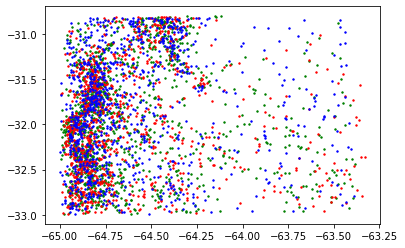

In [22]:
plt.scatter(ds_d3['meanlon'].mean(dim='times'), ds_d3['meanlat'].mean(dim='times'), s=2, c='g')
plt.scatter(ds_d4['meanlon'].mean(dim='times'), ds_d4['meanlat'].mean(dim='times'), s=2, c='r')
plt.scatter(ds_d2['meanlon'].mean(dim='times'), ds_d2['meanlat'].mean(dim='times'), s=2, c='b')

In [23]:
minlon_d4 = ds_d4['meanlon'].min().values
maxlon_d4 = ds_d4['meanlon'].max().values
minlat_d4 = ds_d4['meanlat'].min().values
maxlat_d4 = ds_d4['meanlat'].max().values
print(minlon_d4, maxlon_d4, minlat_d4, maxlat_d4)
print(lon_range, lat_range)

-64.99929 -63.31169 -32.998272 -30.800056
[-65.0, -63.3] [-33.0, -30.8]


In [24]:
# pts = [0.5, 0.75, 0.9, 0.95, 0.99]
# nCoreUp_pts_d2 = ds_d2.nCore_up.chunk(dict(tracks=-1)).quantile(pts, dim=('tracks','times'), skipna=True, keep_attrs=True)
# nCoreUp_pts_d2.plot.line(y='z')

In [25]:
# nCoreUp_pts_d3 = ds_d3.nCore_up.chunk(dict(tracks=-1)).quantile(pts, dim=('tracks','times'), skipna=True, keep_attrs=True)
# nCoreUp_pts_d3.plot.line(y='z')

In [26]:
# nCoreUp_pts_d4 = ds_d4.nCore_up.chunk(dict(tracks=-1)).quantile(pts, dim=('tracks','times'), skipna=True, keep_attrs=True)
# nCoreUp_pts_d4.plot.line(y='z')

In [27]:
# CoreArea_pts_d2 = ds_d2.CoreArea_up.chunk(dict(tracks=-1)).quantile(pts, dim=('tracks','times','core'), skipna=True, keep_attrs=True)
# # Convert area to equivalent radius
# CoreRadius_pts_d2 = np.sqrt(CoreArea_pts_d2 / np.pi)
# CoreRadius_pts_d2.plot.line(y='z')

In [28]:
# CoreArea_pts_d3 = ds_d3.CoreArea_up.chunk(dict(tracks=-1)).quantile(pts, dim=('tracks','times','core'), skipna=True, keep_attrs=True)
# # Convert area to equivalent radius
# CoreRadius_pts_d3 = np.sqrt(CoreArea_pts_d3 / np.pi)
# CoreRadius_pts_d3.plot.line(y='z')

In [29]:
# CoreArea_pts_d4 = ds_d4.CoreArea_up.chunk(dict(tracks=-1)).quantile(pts, dim=('tracks','times','core'), skipna=True, keep_attrs=True)
# # Convert area to equivalent radius
# CoreRadius_pts_d4 = np.sqrt(CoreArea_pts_d4 / np.pi)
# CoreRadius_pts_d4.plot.line(y='z')

## Find merge/split track indices

In [30]:
# def find_merge_split_tracks(ds):
#     """
#     Find merge/split track indices.
#     """
#     # non-split tracks
#     idx_nsplit = np.isnan(ds.start_split_cloudnumber.load())
#     # non-merge tracks
#     idx_nmerge = np.isnan(ds.end_merge_cloudnumber.load())
#     # non-merge and non-split tracks
#     idx_nms = np.isnan(ds.start_split_cloudnumber.load()) & np.isnan(ds.end_merge_cloudnumber.load())
#     # merge or split tracks
#     idx_ms = ~np.isnan(ds.start_split_cloudnumber.load()) | ~np.isnan(ds.end_merge_cloudnumber.load())
#     # Group outputs to dictionary
#     out_dict = {
#         'ms': idx_ms,
#         'nms': idx_nms,
#         'nm': idx_nmerge,
#         'ns': idx_nsplit,
#     }
#     return out_dict

In [31]:
def find_merge_split_tracks(ds, time_window, time_res=5.0):
    """
    Find merge/split track indices.

    Args:
        ds: Xarray DataSet
            DataSet for cell tracks.
        time_window: array-like
            Time window to constrain mergers [minutes].
        time_res: float, default=5.0
            Time resolution of the tracking data [minutes].

    Return:
        out_dict: dictionary
            Dictionary containing various sets of track indices.
    """
    # Get track lifetime
    lifetime = ds.track_duration.load() * time_res

    # Non-split tracks
    idx_nsplit = np.isnan(ds.start_split_cloudnumber.load())

    # Non-merge tracks
    idx_nmerge = np.isnan(ds.end_merge_cloudnumber.load())

    # Merge after time window tracks
    idx_merge_after = ~np.isnan(ds.end_merge_cloudnumber.load()) & (lifetime > np.max(time_window))

    # Combine conditions (satisfy both):
    # - Non-merge or merge after time window
    # - Non-split
    idx_nms = np.logical_and(idx_nsplit, (np.logical_or(idx_nmerge, idx_merge_after)))

    # Group outputs to dictionary
    out_dict = {
        'ns': idx_nsplit,
        'nm': idx_nmerge,
        'ms': idx_merge_after,
        'nms': idx_nms,
    }
    return out_dict

## Subset DataSets with non-merge/non-split tracks

In [32]:
time_window = (ds_d2.attrs['time_start'], ds_d2.attrs['time_end'])
time_window

(0, 60)

In [33]:
tid_d2 = find_merge_split_tracks(ds_d2, time_window)
tid_d3 = find_merge_split_tracks(ds_d3, time_window)
tid_d4 = find_merge_split_tracks(ds_d4, time_window)

In [34]:
# ntracks_nms_d2 = np.count_nonzero(tid_d2['nms'] == True)
# ntracks_ns_d2 = np.count_nonzero(tid_d2['ns'] == True)
# print(f'D2 non-merge-split tracks: {ntracks_nms_d2}, non-split tracks: {ntracks_ns_d2}')

In [35]:
# ntracks_nms_d3 = np.count_nonzero(tid_d3['nms'] == True)
# ntracks_ns_d3 = np.count_nonzero(tid_d3['ns'] == True)
# print(f'D3 non-merge-split tracks: {ntracks_nms_d3}, non-split tracks: {ntracks_ns_d3}')

In [36]:
# ntracks_nms_d4 = np.count_nonzero(tid_d4['nms'] == True)
# ntracks_ns_d4 = np.count_nonzero(tid_d4['ns'] == True)
# print(f'D4 non-merge-split tracks: {ntracks_nms_d4}, non-split tracks: {ntracks_ns_d4}')

In [37]:
# lifetime_d2 = ds_d2.track_duration.load() * time_res
# # lifetime_d2.plot.hist()
# # merge within time window
# idx_merge = np.isnan(ds_d2.end_merge_cloudnumber.load()) & (lifetime_d2 < np.max(time_window))

# # Split or merge within time window
# idx_ms = ~np.isnan(ds_d2.start_split_cloudnumber.load()) | (np.isnan(ds_d2.end_merge_cloudnumber.load()) & (lifetime_d2 < np.max(time_window)))

# # lifetime_d2.isel(tracks=idx_merge).plot.hist(bins=np.arange(10,70,5))
# lifetime_d2.isel(tracks=idx_ms).plot.hist(bins=np.arange(10,200,5))

In [38]:
dsnms_d2 = ds_d2.isel(tracks=tid_d2['nms'])
dsnms_d3 = ds_d3.isel(tracks=tid_d3['nms'])
dsnms_d4 = ds_d4.isel(tracks=tid_d4['nms'])

# Get number of tracks
ntracks_nms_d2 = dsnms_d2.sizes['tracks']
ntracks_nms_d3 = dsnms_d3.sizes['tracks']
ntracks_nms_d4 = dsnms_d4.sizes['tracks']
print(f'D2 non-merge-split tracks: {ntracks_nms_d2}')
print(f'D3 non-merge-split tracks: {ntracks_nms_d3}')
print(f'D4 non-merge-split tracks: {ntracks_nms_d4}')

D2 non-merge-split tracks: 543
D3 non-merge-split tracks: 959
D4 non-merge-split tracks: 809


## Check number of merge after time_window tracks

In [39]:
# Tracks where merging occurs after the time_window
lifetime_merge_after_d2 = dsnms_d2.track_duration.where(~np.isnan(dsnms_d2.end_merge_cloudnumber), drop=True) * time_res
minlifetime_merge_after_d2 = lifetime_merge_after_d2.min().values
ntracks_merge_after_d2 = (lifetime_merge_after_d2).sizes['tracks']
print(f'D2 merge after time_window tracks: {ntracks_merge_after_d2}, min lifetime: {minlifetime_merge_after_d2} min')

# Tracks where merging occurs after the time_window
lifetime_merge_after_d3 = dsnms_d3.track_duration.where(~np.isnan(dsnms_d3.end_merge_cloudnumber), drop=True) * time_res
minlifetime_merge_after_d3 = lifetime_merge_after_d3.min().values
ntracks_merge_after_d3 = (lifetime_merge_after_d3).sizes['tracks']
print(f'D3 merge after time_window tracks: {ntracks_merge_after_d3}, min lifetime: {minlifetime_merge_after_d3} min')

# Tracks where merging occurs after the time_window
lifetime_merge_after_d4 = dsnms_d4.track_duration.where(~np.isnan(dsnms_d4.end_merge_cloudnumber), drop=True) * time_res
minlifetime_merge_after_d4 = lifetime_merge_after_d4.min().values
ntracks_merge_after_d4 = (lifetime_merge_after_d4).sizes['tracks']
print(f'D4 merge after time_window tracks: {ntracks_merge_after_d4}, min lifetime: {minlifetime_merge_after_d4} min')

D2 merge after time_window tracks: 79, min lifetime: 65.0 min
D3 merge after time_window tracks: 50, min lifetime: 65.0 min
D4 merge after time_window tracks: 39, min lifetime: 65.0 min


In [40]:
# dsns_d2 = ds_d2.isel(tracks=tid_d2['ns'])
# dsns_d3 = ds_d3.isel(tracks=tid_d3['ns'])
# dsns_d4 = ds_d4.isel(tracks=tid_d4['ns'])

# ntracks_ns_d2 = dsns_d2.sizes['tracks']
# ntracks_ns_d3 = dsns_d3.sizes['tracks']
# ntracks_ns_d4 = dsns_d4.sizes['tracks']
# print(f'D2 non-split tracks: {ntracks_ns_d2}')
# print(f'D3 non-split tracks: {ntracks_ns_d3}')
# print(f'D4 non-split tracks: {ntracks_ns_d4}')

In [41]:
# Get some constents common for all Datasets
ntimes = dsnms_d2.sizes['times']
nz = dsnms_d2.sizes['z']
# ncores = dsnms_d2.sizes['core']
time_coord = dsnms_d2.times
xtime = time_coord * time_res  # [min]

# time_res = 5.0  # [min]
# xtime = dsnms_d2.times * time_res
# height = dsnms_d2.z / 1000.

In [42]:
# Find time coordinate index of the time_window
tidx_start = np.abs(xtime - np.min(time_window)).argmin().item()
tidx_end = np.abs(xtime - np.max(time_window)).argmin().item()
tidx_start, tidx_end
# dsnms_d2['maxETH_10dbz']

(0, 12)

(array([ 0.,  0.,  2., 12., 70., 81., 83., 86., 41., 26., 26., 16., 17.,
        14., 26.,  0., 21.,  0.,  6.,  0.,  2.,  0.,  4.,  0.,  5.,  0.,
         3.,  0.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]),
 array([ 1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,  5.5,  6. ,
         6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5, 11. , 11.5,
        12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. , 16.5, 17. ,
        17.5, 18. , 18.5, 19. , 19.5, 20. ]),
 <BarContainer object of 38 artists>)

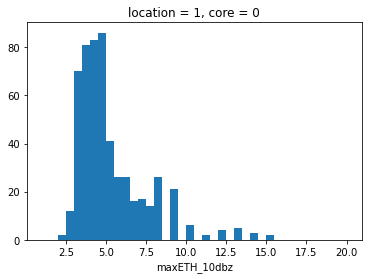

In [43]:
ETH_bins = np.arange(1.0, 20.1, 0.5)
dsnms_d2['maxETH_10dbz'].isel(times=slice(tidx_start, tidx_end)).max(dim='times').plot.hist(bins=ETH_bins)

## Subset cell area/ETH stats to **CI time window** and get their CI-period max values

In [44]:
# Subset DataSet to CI time_window
dsCI_d2 = dsnms_d2.isel(times=slice(tidx_start, tidx_end))
dsCI_d3 = dsnms_d3.isel(times=slice(tidx_start, tidx_end))
dsCI_d4 = dsnms_d4.isel(times=slice(tidx_start, tidx_end))

# Cell max reflectivity
maxdbz_d2 = dsCI_d2['max_dbz'].load()
maxdbz_d3 = dsCI_d3['max_dbz'].load()
maxdbz_d4 = dsCI_d4['max_dbz'].load()
# Cell ETH
maxETH_10dbz_d2 = dsCI_d2['maxETH_10dbz'].load()
maxETH_10dbz_d3 = dsCI_d3['maxETH_10dbz'].load()
maxETH_10dbz_d4 = dsCI_d4['maxETH_10dbz'].load()
# Cell diameter
cellarea_d2 = dsCI_d2['cell_area'].load()
cellarea_d3 = dsCI_d3['cell_area'].load()
cellarea_d4 = dsCI_d4['cell_area'].load()
celldiam_d2 = 2 * np.sqrt(cellarea_d2 / np.pi)
celldiam_d3 = 2 * np.sqrt(cellarea_d3 / np.pi)
celldiam_d4 = 2 * np.sqrt(cellarea_d4 / np.pi)

In [45]:
dsCI_d2.times

<xarray.DataArray 'times' (times: 12)> Size: 96B
array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
Coordinates:
  * times     (times) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
    location  int64 8B 1
    core      int64 8B 0

In [46]:
# # Get cell track lifetime: track_duration x time_resolution [min]
# track_lifetime_d2 = dsnms_d2['track_duration'].load() * time_res
# track_lifetime_d3 = dsnms_d3['track_duration'].load() * time_res
# track_lifetime_d4 = dsnms_d4['track_duration'].load() * time_res

# # Cell max reflectivity
# maxdbz_d2 = dsnms_d2['max_dbz'].load()
# maxdbz_d3 = dsnms_d3['max_dbz'].load()
# maxdbz_d4 = dsnms_d4['max_dbz'].load()
# # Cell ETH
# maxETH_10dbz_d2 = dsnms_d2['maxETH_10dbz'].load()
# maxETH_10dbz_d3 = dsnms_d3['maxETH_10dbz'].load()
# maxETH_10dbz_d4 = dsnms_d4['maxETH_10dbz'].load()
# # Cell diameter
# cellarea_d2 = dsnms_d2['cell_area'].load()
# cellarea_d3 = dsnms_d3['cell_area'].load()
# cellarea_d4 = dsnms_d4['cell_area'].load()
# celldiam_d2 = 2 * np.sqrt(cellarea_d2 / np.pi)
# celldiam_d3 = 2 * np.sqrt(cellarea_d3 / np.pi)
# celldiam_d4 = 2 * np.sqrt(cellarea_d4 / np.pi)

## Functions to compute statistical significance

In [47]:
# def pearsonr_pvalues(df):
#     cols = pd.DataFrame(columns=df.columns)
#     p = cols.transpose().join(cols, how='outer')
#     for r in df.columns:
#         for c in df.columns:
#             tmp = df[df[r].notnull() & df[c].notnull()]
#             p[r][c] = round(pearsonr(tmp[r], tmp[c])[1], 4)
#     return p

In [48]:
# def spearmanr_pvalues(df):
#     cols = pd.DataFrame(columns=df.columns)
#     p = cols.transpose().join(cols, how='outer')
#     for r in df.columns:
#         for c in df.columns:
#             tmp = df[df[r].notnull() & df[c].notnull()]
#             p[r][c] = round(spearmanr(tmp[r], tmp[c])[1], 4)
#     return p

In [49]:
def pearsonr_pvalues(df):
    # Create an empty DataFrame with the same columns and indices as 'df'
    p = pd.DataFrame(index=df.columns, columns=df.columns)
    
    # Iterate over each pair of columns
    for r in df.columns:
        for c in df.columns:
            # Filter rows where both columns have non-null values
            tmp = df[df[r].notnull() & df[c].notnull()]
            # Find non-NaN values for both
            mask = np.logical_and(~np.isnan(tmp[r]), ~np.isnan(tmp[c]))
            if not tmp.empty:
                # Calculate Pearson correlation and p-value, then assign the p-value
                correlation, p_value = pearsonr(tmp[r][mask], tmp[c][mask])
                p.loc[r, c] = round(p_value, 4)
    
    return p

In [50]:
def spearmanr_pvalues(df):
    # Create an empty DataFrame with the same columns and indices as 'df'
    p = pd.DataFrame(index=df.columns, columns=df.columns)
    
    # Iterate over each pair of columns
    for r in df.columns:
        for c in df.columns:
            # Filter rows where both columns have non-null values
            tmp = df[df[r].notnull() & df[c].notnull()]
            if not tmp.empty:
                # Calculate Spearman correlation and p-value, then assign the p-value
                correlation, p_value = spearmanr(tmp[r], tmp[c])
                p.loc[r, c] = round(p_value, 4)
    
    return p

In [51]:
# # Calculate distance between minimum updraft base height and MU LCL height (HAMSL)
# Wbase_LCL_diff_d2sub = np.absolute(Wmask_dict_narrow_deep_d2sub['Wbase'].min(dim='times') - LCL_mu_narrow_deep_d2sub)

# # True/False flag for positive slope
# Wtop_Pslope_narrow_deep_d2sub = Wtop_slope_narrow_deep_d2sub > min_Wtop_slope
# # True/False flag for updraft base height from LCL
# Wbase_LCL_narrow_deep_d2sub = Wbase_LCL_diff_d2sub <= max_Wbase_LCL_dist
# # Both positive slope & updraft base flag
# Wkeep_flag_narrow_deep_d2sub = (Wtop_Pslope_narrow_deep_d2sub & Wbase_LCL_narrow_deep_d2sub).compute()
# # Track indicies to keep
# Wid_keep_narrow_deep_d2sub = np.where(Wkeep_flag_narrow_deep_d2sub)[0]

# ntracksW_narrow_deep_d2 = len(Wid_keep_narrow_deep_d2sub)
# ntracksW_narrow_shallow_d2 = len(Wid_narrow_shallow_d2)
# print(f'D2 number of narrow-deep tracks to keep: {ntracksW_narrow_deep_d2}, fraction to all narrow-deep tracks: {100*(ntracksW_narrow_deep_d2 / ntracks_narrow_deep_d2sub):.1f}%')
# print(f'D2 number of narrow-shallow tracks to keep: {ntracksW_narrow_shallow_d2}')

In [52]:
# # Get preCI environmental variables
# ntimes_preCI = 12
# # Convert MU EL(LNB) height to [km]
# MULNB_d2 = dsnms_d2.EL_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000
# MULNB_d3 = dsnms_d3.EL_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000
# MULNB_d4 = dsnms_d4.EL_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000

# MUCAPE_d2 = dsnms_d2.CAPE_mu.sel(times=slice(-1*ntimes_preCI,0))
# MUCAPE_d3 = dsnms_d3.CAPE_mu.sel(times=slice(-1*ntimes_preCI,0))
# MUCAPE_d4 = dsnms_d4.CAPE_mu.sel(times=slice(-1*ntimes_preCI,0))

In [53]:
# dsnms_d2.Z_surface.isel(tracks=200).plot()

(array([ 67.,  81.,  65.,  79.,  88.,  94.,  96.,  87., 120.,  26.]),
 array([ 184.51987,  420.5099 ,  656.49994,  892.4899 , 1128.48   ,
        1364.47   , 1600.4601 , 1836.4501 , 2072.4402 , 2308.4302 ,
        2544.4202 ], dtype=float32),
 <BarContainer object of 10 artists>)

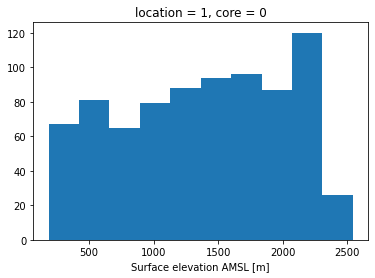

In [54]:
dsnms_d4.Z_surface.plot.hist()

In [55]:
# Get preCI MU LNB
# preCI_time = -3  # preCI time
# Select preCI time, the drop the times coordinate (this avoids conflict with cell lifetime-max variables that has no times coordinate)
# Add surface elevation to convert LNB from HAMSL to HAGL
# MULNB_d2 = ((dsnms_d2.EL_height_mu + dsnms_d2.Z_surface).sel(times=preCI_time)/1000).reset_coords('times', drop=True)
# MULNB_d3 = ((dsnms_d3.EL_height_mu + dsnms_d3.Z_surface).sel(times=preCI_time)/1000).reset_coords('times', drop=True)
# MULNB_d4 = ((dsnms_d4.EL_height_mu + dsnms_d4.Z_surface).sel(times=preCI_time)/1000).reset_coords('times', drop=True)
MULNB_d2 = ((dsnms_d2.EL_height_mu)/1000)
MULNB_d3 = ((dsnms_d3.EL_height_mu)/1000)
MULNB_d4 = ((dsnms_d4.EL_height_mu)/1000)

(array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.00249066, 0.00249066, 0.        , 0.00249066,
        0.00747198, 0.        , 0.00249066, 0.0124533 , 0.11706102,
        0.19676214, 0.18929016, 0.17683686, 0.11706102, 0.05230386,
        0.02739726, 0.05728518, 0.07721046, 0.0996264 , 0.12951432,
        0.1618929 , 0.12204234, 0.14445828, 0.1120797 , 0.0747198 ,
        0.06973848, 0.03985056, 0.00498132, 0.        , 0.        ,
        0.        ]),
 array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
         5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5,
        11. , 11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. ,
        16.5, 17. , 17.5, 18. ]),
 <BarContainer object of 36 artists>)

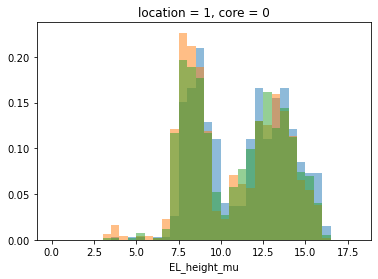

In [56]:
bins = np.arange(0, 18.1, 0.5)
MULNB_d2.plot.hist(bins=bins, alpha=0.5, label='D2', density=True)
MULNB_d3.plot.hist(bins=bins, alpha=0.5, label='D3', density=True)
MULNB_d4.plot.hist(bins=bins, alpha=0.5, label='D4', density=True)

## Get **CI-max** 10dBZ ETH and cell diameter percentile values

In [57]:
ETH_percentiles = [0.33, 0.5, 0.66, 0.75]
trackmaxETH_10dbz_d2 = maxETH_10dbz_d2.max(dim='times')
max10dbz_pts_d2 = trackmaxETH_10dbz_d2.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ percentile values (D2): {max10dbz_pts_d2.values}")

trackmaxCellDiam_d2 = celldiam_d2.max(dim='times')
maxCellDiam_pts_d2 = trackmaxCellDiam_d2.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max CellDiam percentile values (D2): {maxCellDiam_pts_d2.values}")

Max 10dBZ percentile values (D2): [4.   4.5  5.25 6.  ]
Max CellDiam percentile values (D2): [ 9.7720499  10.9254837  11.96826839 13.52879047]


In [58]:
trackmaxETH_10dbz_d3 = maxETH_10dbz_d3.max(dim='times')
max10dbz_pts_d3 = trackmaxETH_10dbz_d3.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ percentile values (D3): {max10dbz_pts_d3.values}")

trackmaxCellDiam_d3 = celldiam_d3.max(dim='times')
maxCellDiam_pts_d3 = trackmaxCellDiam_d3.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max CellDiam percentile values (D3): {maxCellDiam_pts_d3.values}")

Max 10dBZ percentile values (D3): [5.5 6.  7.  8. ]
Max CellDiam percentile values (D3): [5.14001179 5.89031219 7.09175301 8.36826181]


In [59]:
trackmaxETH_10dbz_d4 = maxETH_10dbz_d4.max(dim='times')
max10dbz_pts_d4 = trackmaxETH_10dbz_d4.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ percentile values (D4): {max10dbz_pts_d4.values}")

trackmaxCellDiam_d4 = celldiam_d4.max(dim='times')
maxCellDiam_pts_d4 = trackmaxCellDiam_d4.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max CellDiam percentile values (D4): {maxCellDiam_pts_d4.values}")

Max 10dBZ percentile values (D4): [5.  5.5 6.5 7.5]
Max CellDiam percentile values (D4): [5.1708827  5.78122282 6.89327169 7.9788456 ]


In [60]:
trackmaxCellDiam_d4.shape, dsnms_d4.Warea_median.shape

((809,), (809,))

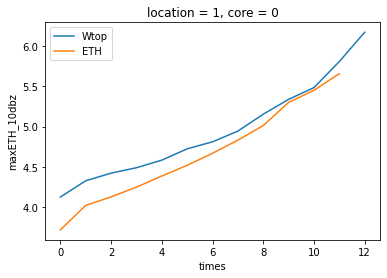

In [61]:
dsnms_d2.Wtop.mean(dim='tracks').plot(label='Wtop')
maxETH_10dbz_d2.mean(dim='tracks').plot(label='ETH')
plt.legend()

In [62]:
# CI-window max updraft top height
trackmaxWtop_d2 = dsnms_d2.Wtop.max(dim='times')
trackmaxWtop_d3 = dsnms_d3.Wtop.max(dim='times')
trackmaxWtop_d4 = dsnms_d4.Wtop.max(dim='times')

In [63]:
# 2*np.sqrt(dsnms_d2.Warea_mean/np.pi)

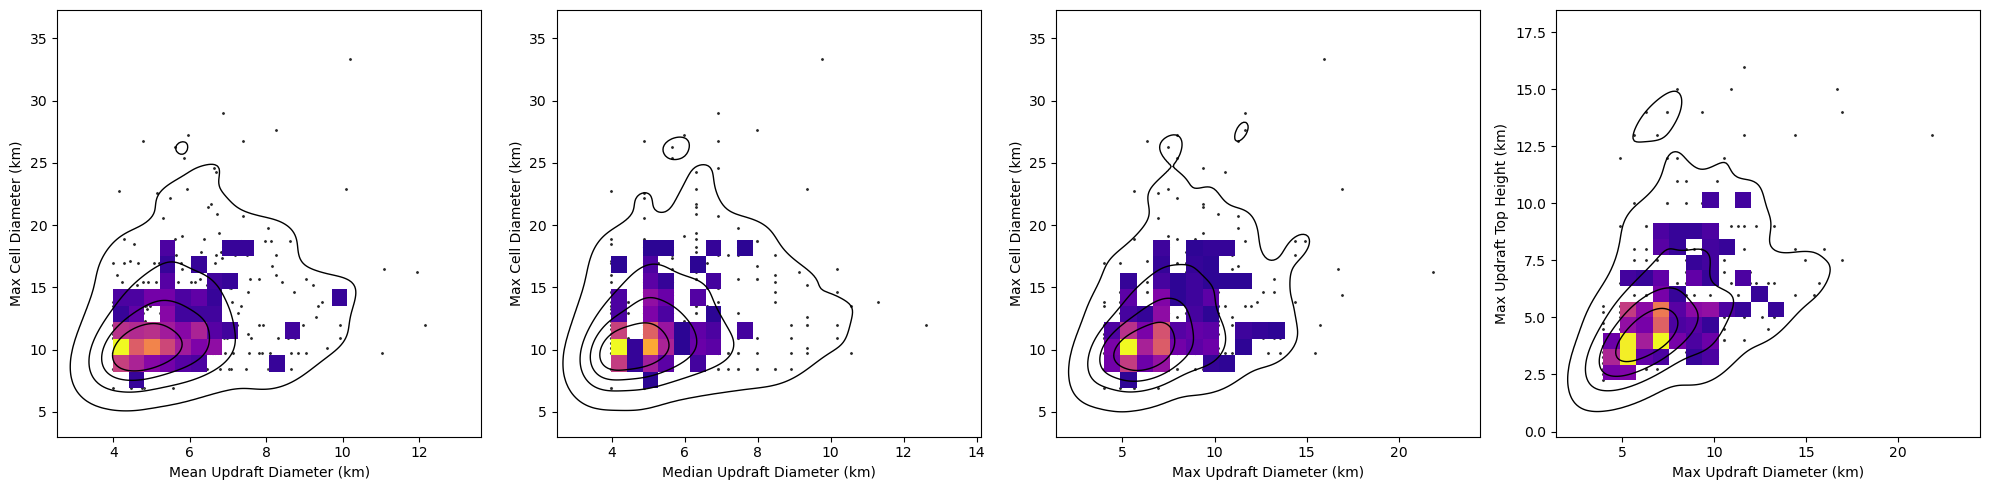

In [64]:
# Draw a combo histogram and scatterplot with density contours
fig, axes = plt.subplots(1, 4, figsize=(20, 5), dpi=100)
ax0 = axes[0]
sns.scatterplot(x=2*np.sqrt(dsnms_d2.Warea_mean/np.pi), y=trackmaxCellDiam_d2, s=5, color=".15", ax=ax0)
sns.histplot(x=2*np.sqrt(dsnms_d2.Warea_mean/np.pi), y=trackmaxCellDiam_d2, bins=20, pthresh=.1, cmap="plasma", ax=ax0)
sns.kdeplot(x=2*np.sqrt(dsnms_d2.Warea_mean/np.pi), y=trackmaxCellDiam_d2, levels=5, color="k", linewidths=1, ax=ax0)
ax0.set_xlabel('Mean Updraft Diameter (km)')
ax0.set_ylabel('Max Cell Diameter (km)')
ax1 = axes[1]
sns.scatterplot(x=2*np.sqrt(dsnms_d2.Warea_median/np.pi), y=trackmaxCellDiam_d2, s=5, color=".15", ax=ax1)
sns.histplot(x=2*np.sqrt(dsnms_d2.Warea_median/np.pi), y=trackmaxCellDiam_d2, bins=20, pthresh=.1, cmap="plasma", ax=ax1)
sns.kdeplot(x=2*np.sqrt(dsnms_d2.Warea_median/np.pi), y=trackmaxCellDiam_d2, levels=5, color="k", linewidths=1, ax=ax1)
ax1.set_xlabel('Median Updraft Diameter (km)')
ax1.set_ylabel('Max Cell Diameter (km)')
ax2 = axes[2]
sns.scatterplot(x=2*np.sqrt(dsnms_d2.Warea_max/np.pi), y=trackmaxCellDiam_d2, s=5, color=".15", ax=ax2)
sns.histplot(x=2*np.sqrt(dsnms_d2.Warea_max/np.pi), y=trackmaxCellDiam_d2, bins=20, pthresh=.1, cmap="plasma", ax=ax2)
sns.kdeplot(x=2*np.sqrt(dsnms_d2.Warea_max/np.pi), y=trackmaxCellDiam_d2, levels=5, color="k", linewidths=1, ax=ax2)
ax2.set_xlabel('Max Updraft Diameter (km)')
ax2.set_ylabel('Max Cell Diameter (km)')
ax3 = axes[3]
sns.scatterplot(x=2*np.sqrt(dsnms_d2.Warea_max/np.pi), y=trackmaxWtop_d2, s=5, color=".15", ax=ax3)
sns.histplot(x=2*np.sqrt(dsnms_d2.Warea_max/np.pi), y=trackmaxWtop_d2, bins=20, pthresh=.1, cmap="plasma", ax=ax3)
sns.kdeplot(x=2*np.sqrt(dsnms_d2.Warea_max/np.pi), y=trackmaxWtop_d2, levels=5, color="k", linewidths=1, ax=ax3)
ax3.set_xlabel('Max Updraft Diameter (km)')
ax3.set_ylabel('Max Updraft Top Height (km)')
fig.tight_layout()

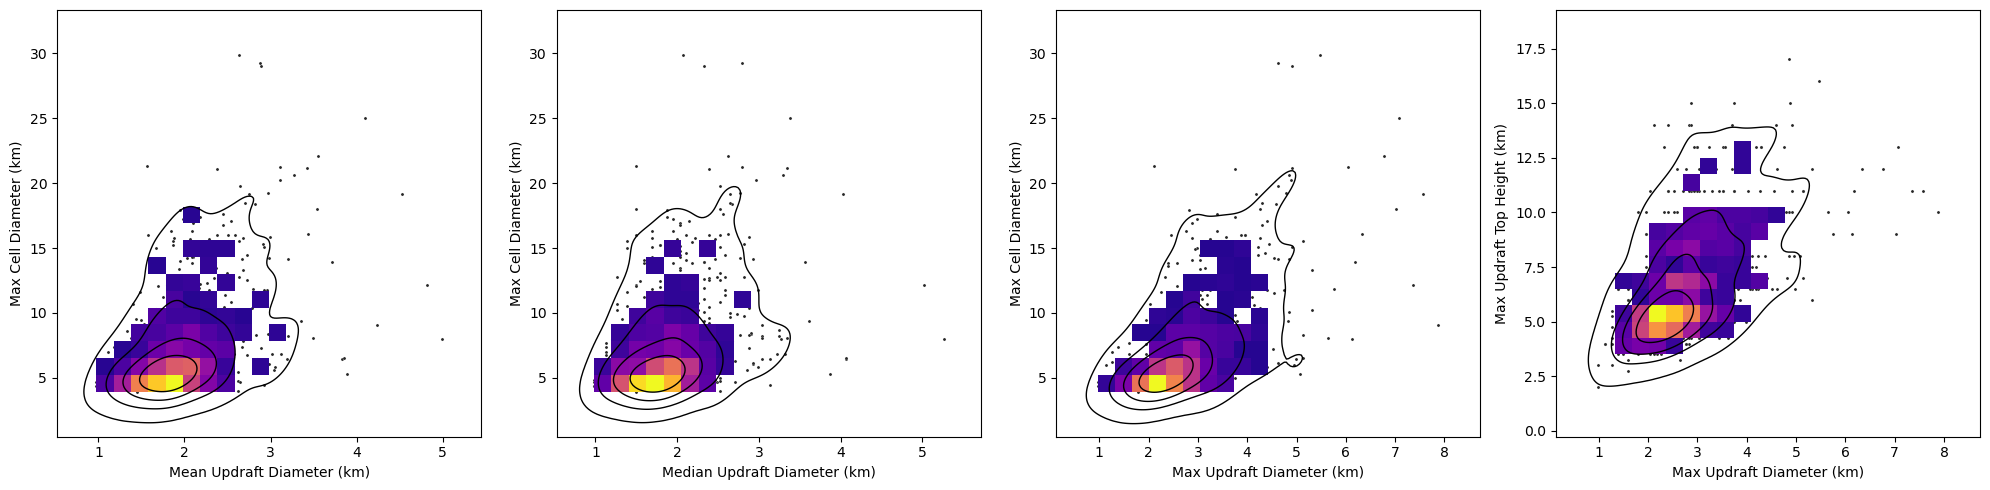

In [65]:
# Draw a combo histogram and scatterplot with density contours
fig, axes = plt.subplots(1, 4, figsize=(20, 5), dpi=100)
ax0 = axes[0]
sns.scatterplot(x=2*np.sqrt(dsnms_d3.Warea_mean/np.pi), y=trackmaxCellDiam_d3, s=5, color=".15", ax=ax0)
sns.histplot(x=2*np.sqrt(dsnms_d3.Warea_mean/np.pi), y=trackmaxCellDiam_d3, bins=20, pthresh=.1, cmap="plasma", ax=ax0)
sns.kdeplot(x=2*np.sqrt(dsnms_d3.Warea_mean/np.pi), y=trackmaxCellDiam_d3, levels=5, color="k", linewidths=1, ax=ax0)
ax0.set_xlabel('Mean Updraft Diameter (km)')
ax0.set_ylabel('Max Cell Diameter (km)')
ax1 = axes[1]
sns.scatterplot(x=2*np.sqrt(dsnms_d3.Warea_median/np.pi), y=trackmaxCellDiam_d3, s=5, color=".15", ax=ax1)
sns.histplot(x=2*np.sqrt(dsnms_d3.Warea_median/np.pi), y=trackmaxCellDiam_d3, bins=20, pthresh=.1, cmap="plasma", ax=ax1)
sns.kdeplot(x=2*np.sqrt(dsnms_d3.Warea_median/np.pi), y=trackmaxCellDiam_d3, levels=5, color="k", linewidths=1, ax=ax1)
ax1.set_xlabel('Median Updraft Diameter (km)')
ax1.set_ylabel('Max Cell Diameter (km)')
ax2 = axes[2]
sns.scatterplot(x=2*np.sqrt(dsnms_d3.Warea_max/np.pi), y=trackmaxCellDiam_d3, s=5, color=".15", ax=ax2)
sns.histplot(x=2*np.sqrt(dsnms_d3.Warea_max/np.pi), y=trackmaxCellDiam_d3, bins=20, pthresh=.1, cmap="plasma", ax=ax2)
sns.kdeplot(x=2*np.sqrt(dsnms_d3.Warea_max/np.pi), y=trackmaxCellDiam_d3, levels=5, color="k", linewidths=1, ax=ax2)
ax2.set_xlabel('Max Updraft Diameter (km)')
ax2.set_ylabel('Max Cell Diameter (km)')
ax3 = axes[3]
sns.scatterplot(x=2*np.sqrt(dsnms_d3.Warea_max/np.pi), y=trackmaxWtop_d3, s=5, color=".15", ax=ax3)
sns.histplot(x=2*np.sqrt(dsnms_d3.Warea_max/np.pi), y=trackmaxWtop_d3, bins=20, pthresh=.1, cmap="plasma", ax=ax3)
sns.kdeplot(x=2*np.sqrt(dsnms_d3.Warea_max/np.pi), y=trackmaxWtop_d3, levels=5, color="k", linewidths=1, ax=ax3)
ax3.set_xlabel('Max Updraft Diameter (km)')
ax3.set_ylabel('Max Updraft Top Height (km)')
fig.tight_layout()

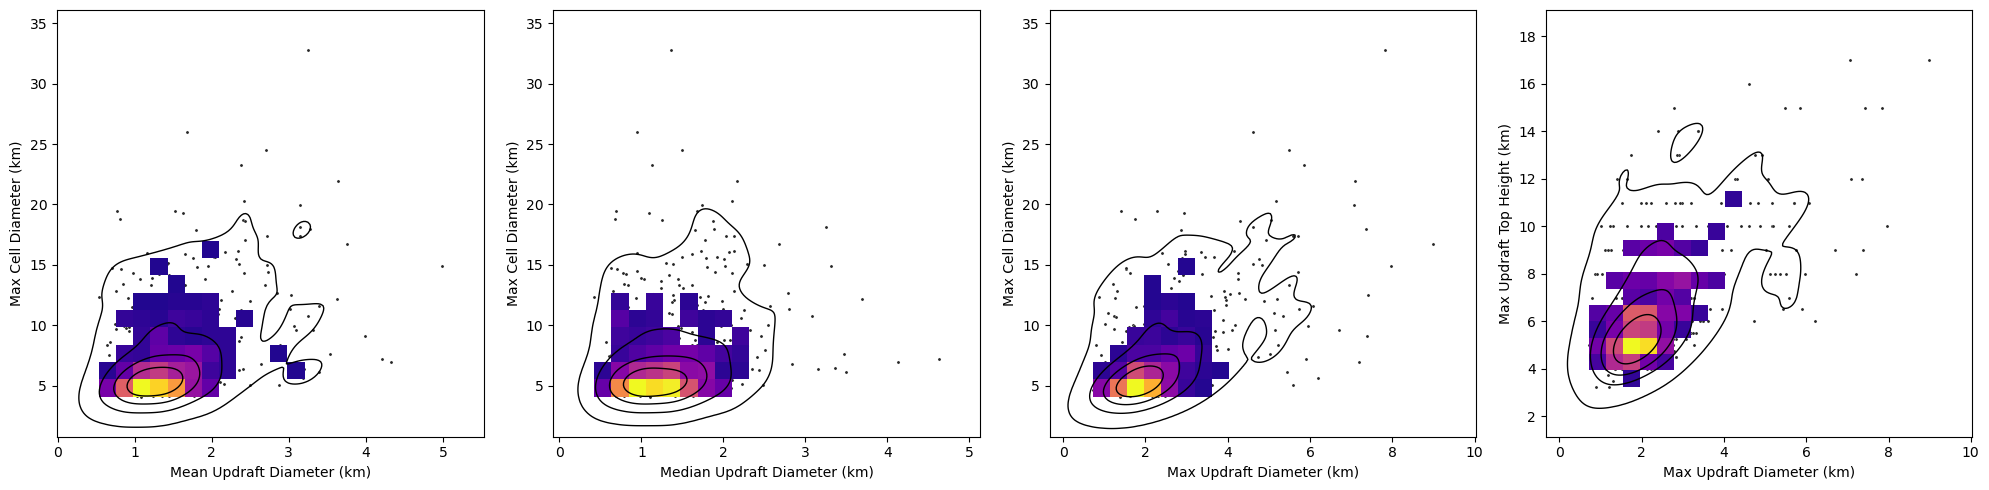

In [66]:
# Draw a combo histogram and scatterplot with density contours
fig, axes = plt.subplots(1, 4, figsize=(20, 5), dpi=100)
ax0 = axes[0]
sns.scatterplot(x=2*np.sqrt(dsnms_d4.Warea_mean/np.pi), y=trackmaxCellDiam_d4, s=5, color=".15", ax=ax0)
sns.histplot(x=2*np.sqrt(dsnms_d4.Warea_mean/np.pi), y=trackmaxCellDiam_d4, bins=20, pthresh=.1, cmap="plasma", ax=ax0)
sns.kdeplot(x=2*np.sqrt(dsnms_d4.Warea_mean/np.pi), y=trackmaxCellDiam_d4, levels=5, color="k", linewidths=1, ax=ax0)
ax0.set_xlabel('Mean Updraft Diameter (km)')
ax0.set_ylabel('Max Cell Diameter (km)')
ax1 = axes[1]
sns.scatterplot(x=2*np.sqrt(dsnms_d4.Warea_median/np.pi), y=trackmaxCellDiam_d4, s=5, color=".15", ax=ax1)
sns.histplot(x=2*np.sqrt(dsnms_d4.Warea_median/np.pi), y=trackmaxCellDiam_d4, bins=20, pthresh=.1, cmap="plasma", ax=ax1)
sns.kdeplot(x=2*np.sqrt(dsnms_d4.Warea_median/np.pi), y=trackmaxCellDiam_d4, levels=5, color="k", linewidths=1, ax=ax1)
ax1.set_xlabel('Median Updraft Diameter (km)')
ax1.set_ylabel('Max Cell Diameter (km)')
ax2 = axes[2]
sns.scatterplot(x=2*np.sqrt(dsnms_d4.Warea_max/np.pi), y=trackmaxCellDiam_d4, s=5, color=".15", ax=ax2)
sns.histplot(x=2*np.sqrt(dsnms_d4.Warea_max/np.pi), y=trackmaxCellDiam_d4, bins=20, pthresh=.1, cmap="plasma", ax=ax2)
sns.kdeplot(x=2*np.sqrt(dsnms_d4.Warea_max/np.pi), y=trackmaxCellDiam_d4, levels=5, color="k", linewidths=1, ax=ax2)
ax2.set_xlabel('Max Updraft Diameter (km)')
ax2.set_ylabel('Max Cell Diameter (km)')
ax3 = axes[3]
sns.scatterplot(x=2*np.sqrt(dsnms_d4.Warea_max/np.pi), y=trackmaxWtop_d4, s=5, color=".15", ax=ax3)
sns.histplot(x=2*np.sqrt(dsnms_d4.Warea_max/np.pi), y=trackmaxWtop_d4, bins=20, pthresh=.1, cmap="plasma", ax=ax3)
sns.kdeplot(x=2*np.sqrt(dsnms_d4.Warea_max/np.pi), y=trackmaxWtop_d4, levels=5, color="k", linewidths=1, ax=ax3)
ax3.set_xlabel('Max Updraft Diameter (km)')
ax3.set_ylabel('Max Updraft Top Height (km)')
fig.tight_layout()

In [67]:
# # Draw a combo histogram and scatterplot with density contours
# fig, axes = plt.subplots(1, 4, figsize=(20, 5), dpi=100)
# ax0 = axes[0]
# sns.scatterplot(x=dsnms_d3.Warea_mean, y=trackmaxCellDiam_d3, s=5, color=".15", ax=ax0)
# sns.histplot(x=dsnms_d3.Warea_mean, y=trackmaxCellDiam_d3, bins=40, pthresh=.1, cmap="plasma", ax=ax0)
# sns.kdeplot(x=dsnms_d3.Warea_mean, y=trackmaxCellDiam_d3, levels=5, color="k", linewidths=1, ax=ax0)
# ax0.set_xlabel('Mean Updraft Diameter (km)')
# ax0.set_ylabel('Max Cell Diameter (km)')
# ax1 = axes[1]
# sns.scatterplot(x=dsnms_d3.Warea_median, y=trackmaxCellDiam_d3, s=5, color=".15", ax=ax1)
# sns.histplot(x=dsnms_d3.Warea_median, y=trackmaxCellDiam_d3, bins=40, pthresh=.1, cmap="plasma", ax=ax1)
# sns.kdeplot(x=dsnms_d3.Warea_median, y=trackmaxCellDiam_d3, levels=5, color="k", linewidths=1, ax=ax1)
# ax1.set_xlabel('Median Updraft Diameter (km)')
# ax1.set_ylabel('Max Cell Diameter (km)')
# ax2 = axes[2]
# sns.scatterplot(x=dsnms_d3.Warea_max, y=trackmaxCellDiam_d3, s=5, color=".15", ax=ax2)
# sns.histplot(x=dsnms_d3.Warea_max, y=trackmaxCellDiam_d3, bins=40, pthresh=.1, cmap="plasma", ax=ax2)
# sns.kdeplot(x=dsnms_d3.Warea_max, y=trackmaxCellDiam_d3, levels=5, color="k", linewidths=1, ax=ax2)
# ax2.set_xlabel('Max Updraft Diameter (km)')
# ax2.set_ylabel('Max Cell Diameter (km)')
# ax3 = axes[3]
# sns.scatterplot(x=dsnms_d3.Warea_max, y=trackmaxWtop_d3, s=5, color=".15", ax=ax3)
# sns.histplot(x=dsnms_d3.Warea_max, y=trackmaxWtop_d3, bins=30, pthresh=.1, cmap="plasma", ax=ax3)
# sns.kdeplot(x=dsnms_d3.Warea_max, y=trackmaxWtop_d3, levels=5, color="k", linewidths=1, ax=ax3)
# ax3.set_xlabel('Max Updraft Diameter (km)')
# ax3.set_ylabel('Max Updraft Top Height (km)')
# fig.tight_layout()

In [68]:
# # Draw a combo histogram and scatterplot with density contours
# fig, axes = plt.subplots(1, 4, figsize=(20,5), dpi=100)
# ax0 = axes[0]
# sns.scatterplot(x=dsnms_d4.Warea_mean, y=trackmaxCellDiam_d4, s=5, color=".15", ax=ax0)
# sns.histplot(x=dsnms_d4.Warea_mean, y=trackmaxCellDiam_d4, bins=40, pthresh=.1, cmap="plasma", ax=ax0)
# sns.kdeplot(x=dsnms_d4.Warea_mean, y=trackmaxCellDiam_d4, levels=5, color="k", linewidths=1, ax=ax0)
# ax0.set_xlabel('Mean Updraft Diameter (km)')
# ax0.set_ylabel('Max Cell Diameter (km)')
# ax1 = axes[1]
# sns.scatterplot(x=dsnms_d4.Warea_median, y=trackmaxCellDiam_d4, s=5, color=".15", ax=ax1)
# sns.histplot(x=dsnms_d4.Warea_median, y=trackmaxCellDiam_d4, bins=40, pthresh=.1, cmap="plasma", ax=ax1)
# sns.kdeplot(x=dsnms_d4.Warea_median, y=trackmaxCellDiam_d4, levels=5, color="k", linewidths=1, ax=ax1)
# ax1.set_xlabel('Median Updraft Diameter (km)')
# ax1.set_ylabel('Max Cell Diameter (km)')
# ax2 = axes[2]
# sns.scatterplot(x=dsnms_d4.Warea_max, y=trackmaxCellDiam_d4, s=5, color=".15", ax=ax2)
# sns.histplot(x=dsnms_d4.Warea_max, y=trackmaxCellDiam_d4, bins=40, pthresh=.1, cmap="plasma", ax=ax2)
# sns.kdeplot(x=dsnms_d4.Warea_max, y=trackmaxCellDiam_d4, levels=5, color="k", linewidths=1, ax=ax2)
# ax2.set_xlabel('Max Updraft Diameter (km)')
# ax2.set_ylabel('Max Cell Diameter (km)')
# ax3 = axes[3]
# sns.scatterplot(x=dsnms_d4.Warea_max, y=trackmaxWtop_d4, s=5, color=".15", ax=ax3)
# sns.histplot(x=dsnms_d4.Warea_max, y=trackmaxWtop_d4, bins=25, pthresh=.1, cmap="plasma", ax=ax3)
# sns.kdeplot(x=dsnms_d4.Warea_max, y=trackmaxWtop_d4, levels=5, color="k", linewidths=1, ax=ax3)
# ax3.set_xlabel('Max Updraft Diameter (km)')
# ax3.set_ylabel('Max Updraft Top Height (km)')
# fig.tight_layout()

In [69]:
# # np.count_nonzero(np.isnan(df_d4['Max Updraft Diameter'].values))
# names = ['Max Updraft Diameter', 'Max Updraft Top Height']
# df_d4 = pd.DataFrame(columns = names)
# df_d4['Max Updraft Diameter'] = dsnms_d4.Wbase_max.values
# df_d4['Max Updraft Top Height'] = trackmaxWtop_d4.values

# mask = ~np.isnan(df_d4['Max Updraft Diameter']) & ~np.isnan(df_d4['Max Updraft Top Height'])
# linfit = linregress(x=df_d4['Max Updraft Diameter'][mask], y=df_d4['Max Updraft Top Height'][mask])
# print(linfit)
# yfit = linfit[0] * x_bins + linfit[1]
# print(yfit)

# #compute correlations between all pandas data frame variables
# corr_df_pearson_d4 = df_d4.corr(method='pearson')
# corr_df_pearson_d4['Max Updraft Diameter']['Max Updraft Top Height']
# print(corr_df_pearson_d4)                             
# # Compute significance of correlations
# p_df_pearson_d4 = pearsonr_pvalues(df_d4)
# p_df_pearson_d4
# # print(p_df_pearson_d4['Max Updraft Diameter']['Max Updraft Top Height'])

In [70]:
# fig, ax = plt.subplots(figsize=(8.5,8), dpi=100)
# x_bins = np.linspace(0,31,32)
# scatter_kws = {'s':16, 'color':'k'}
# line_kws = {'color':'r', 'linewidth':4}
# ax.set_xlim(-1,30)
# ax.set_ylim(2,18)
# ax.grid(ls='--')
# # sns.regplot(x=dsnms_d4.Wbase_max, y=trackmaxWtop_d4, y_jitter=0.4, scatter_kws=scatter_kws)
# sns.histplot(x='Max Updraft Diameter', y='Max Updraft Top Height', data=df_d4, bins=25, binrange=((0,30),(2,16)), pthresh=.1, cmap="plasma", ax=ax, 
#              cbar=True, cbar_kws={'label':'Sample Size (#)'})
# sns.kdeplot(x='Max Updraft Diameter', y='Max Updraft Top Height', data=df_d4, levels=6, color="slategrey", linewidths=1, ax=ax)
# sns.regplot(x='Max Updraft Diameter', y='Max Updraft Top Height', data=df_d4, 
#             # y_jitter=0.4,
#             x_estimator=np.nanmean, x_bins=x_bins, truncate=True,
#             ci=95, x_ci='ci',
#             scatter_kws=scatter_kws, line_kws=line_kws,  ax=ax)
# ax.plot(x_bins, yfit, color='magenta')
# ax.set_xlabel('Cloud-base Max Updraft Diameter (km)')
# ax.set_ylabel('Max Updraft Top HAMSL (km)')
# ax.set_title('Updraft Diameter vs. Top (D4)', loc='left')

## Function to plot MxN panel linear regression 

In [71]:
def mxn_regplot(nrow, ncol, dfs, x_name, y_name, bins_hist=None, bin_range=None, cmaps=None, cbar_labels=None, kde_levels=None, kde_colors=None, 
                wspace=None, hspace=None, reg_xbins=None,
                xlims=None, ylims=None, xlabels=None, ylabels=None, titles=None, fontsize=None, figsize=None, figname=None, dpi=None):
    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    
    scatter_kws = {'s':16, 'color':'k'}
    line_kws = {'color':'r', 'linewidth':4}
    
    fig = plt.figure(figsize=figsize, dpi=dpi)
    # Set up panels (nrow x ncol)
    h_ratios = list(np.repeat(1,nrow))
    w_ratios = list(np.repeat(1,ncol))
    wspace = wspace
    hspace = hspace
    gs = gridspec.GridSpec(nrow, ncol, figure=fig, height_ratios=h_ratios, width_ratios=w_ratios, wspace=wspace, hspace=hspace)
    
    # Loop over rows and columns
    for row in range(nrow):
        for col in range(ncol):
            # Check if variable is None
            df = dfs[row][col]
            if (df is not None):
                # Setup two columns (left: plot, right: colorbar)
                gss = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[row,col], height_ratios=[1], width_ratios=[1,0.02], wspace=0.02, hspace=0.)
                ax = plt.subplot(gss[0])
                # Colorbar
                cax = plt.subplot(gss[1])
                # Heatmap
                sns.histplot(x=x_name, y=y_name, data=df, bins=bins_hist[row][col],
                             binrange=bin_range[row][col], pthresh=.1, cmap=cmaps[row][col], 
                             cbar=True, cbar_kws={'label':cbar_labels[row][col]}, cbar_ax=cax, ax=ax, )
                # KDE
                sns.kdeplot(x=x_name, y=y_name, data=df, levels=kde_levels[row][col], color=kde_colors[row][col], linewidths=1, ax=ax)
                # Linear regression
                mask = ~np.isnan(df[x_name]) & ~np.isnan(df[y_name])
                linfit = linregress(x=df[x_name][mask], y=df[y_name][mask])
                # yfit line values (bin_range is a pair of tuples for x & y axis, take [0] for x-axis)
                xfit = np.linspace(min(bin_range[row][col][0]), max(bin_range[row][col][0]), 100)
                yfit = linfit[0] * xfit + linfit[1]
                # yfit_label = f"Corr: {linfit[2]:.02f}, p: {linfit[3]:.02f}"
                yfit_label = f"Corr: {linfit[2]:.02f}"
                ax.plot(xfit, yfit, color=line_kws['color'], lw=line_kws['linewidth'], label=yfit_label, zorder=10)
                # Regression plot
                sns.regplot(x=x_name, y=y_name, data=df,
                            # y_jitter=0.4,
                            x_estimator=np.nanmean, x_bins=reg_xbins[row][col], truncate=True,
                            ci=95, x_ci='ci',
                            scatter_kws=scatter_kws, line_kws=line_kws, fit_reg=True, ax=ax)
                ax.legend()
                # Axes, labels
                if xlims is not None: ax.set_xlim(min(xlims[row][col]),max(xlims[row][col]))
                if ylims is not None: ax.set_ylim(min(ylims[row][col]),max(ylims[row][col]))
                ax.grid(ls='--')
                ax.set_title(titles[row][col], loc='left')
                ax.set_xlabel(xlabels[row][col])
                ax.set_ylabel(ylabels[row][col])
                
    fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='w')
    return fig

In [72]:
names = ['Max Updraft Diameter', 'Max Updraft Top Height', 'Max 10dBZ ETH', 'Max Cell Diameter']
df_d2 = pd.DataFrame(columns = names)
df_d2['Max Updraft Diameter'] = 2*np.sqrt(dsnms_d2.Warea_max.values/np.pi)
df_d2['Max Updraft Top Height'] = trackmaxWtop_d2.values
df_d2['Max 10dBZ ETH'] = trackmaxETH_10dbz_d2.values
df_d2['Max Cell Diameter'] = trackmaxCellDiam_d2.values

df_d3 = pd.DataFrame(columns = names)
df_d3['Max Updraft Diameter'] = 2*np.sqrt(dsnms_d3.Warea_max.values/np.pi)
df_d3['Max Updraft Top Height'] = trackmaxWtop_d3.values
df_d3['Max 10dBZ ETH'] = trackmaxETH_10dbz_d3.values
df_d3['Max Cell Diameter'] = trackmaxCellDiam_d3.values

df_d4 = pd.DataFrame(columns = names)
df_d4['Max Updraft Diameter'] = 2*np.sqrt(dsnms_d4.Warea_max.values/np.pi)
df_d4['Max Updraft Top Height'] = trackmaxWtop_d4.values
df_d4['Max 10dBZ ETH'] = trackmaxETH_10dbz_d4.values
df_d4['Max Cell Diameter'] = trackmaxCellDiam_d4.values

In [73]:
pearsonr_pvalues(df_d2)

,Max Updraft Diameter,Max Updraft Top Height,Max 10dBZ ETH,Max Cell Diameter
Max Updraft Diameter,0.0,0.0,0.0,0.0
Max Updraft Top Height,0.0,0.0,0.0,0.0
Max 10dBZ ETH,0.0,0.0,0.0,0.0
Max Cell Diameter,0.0,0.0,0.0,0.0


<AxesSubplot:ylabel='Frequency'>

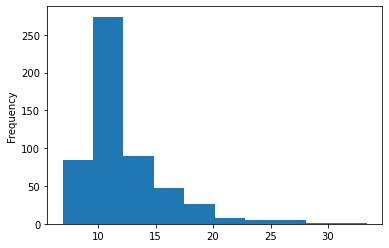

In [74]:
df_d2['Max Cell Diameter'].plot.hist()

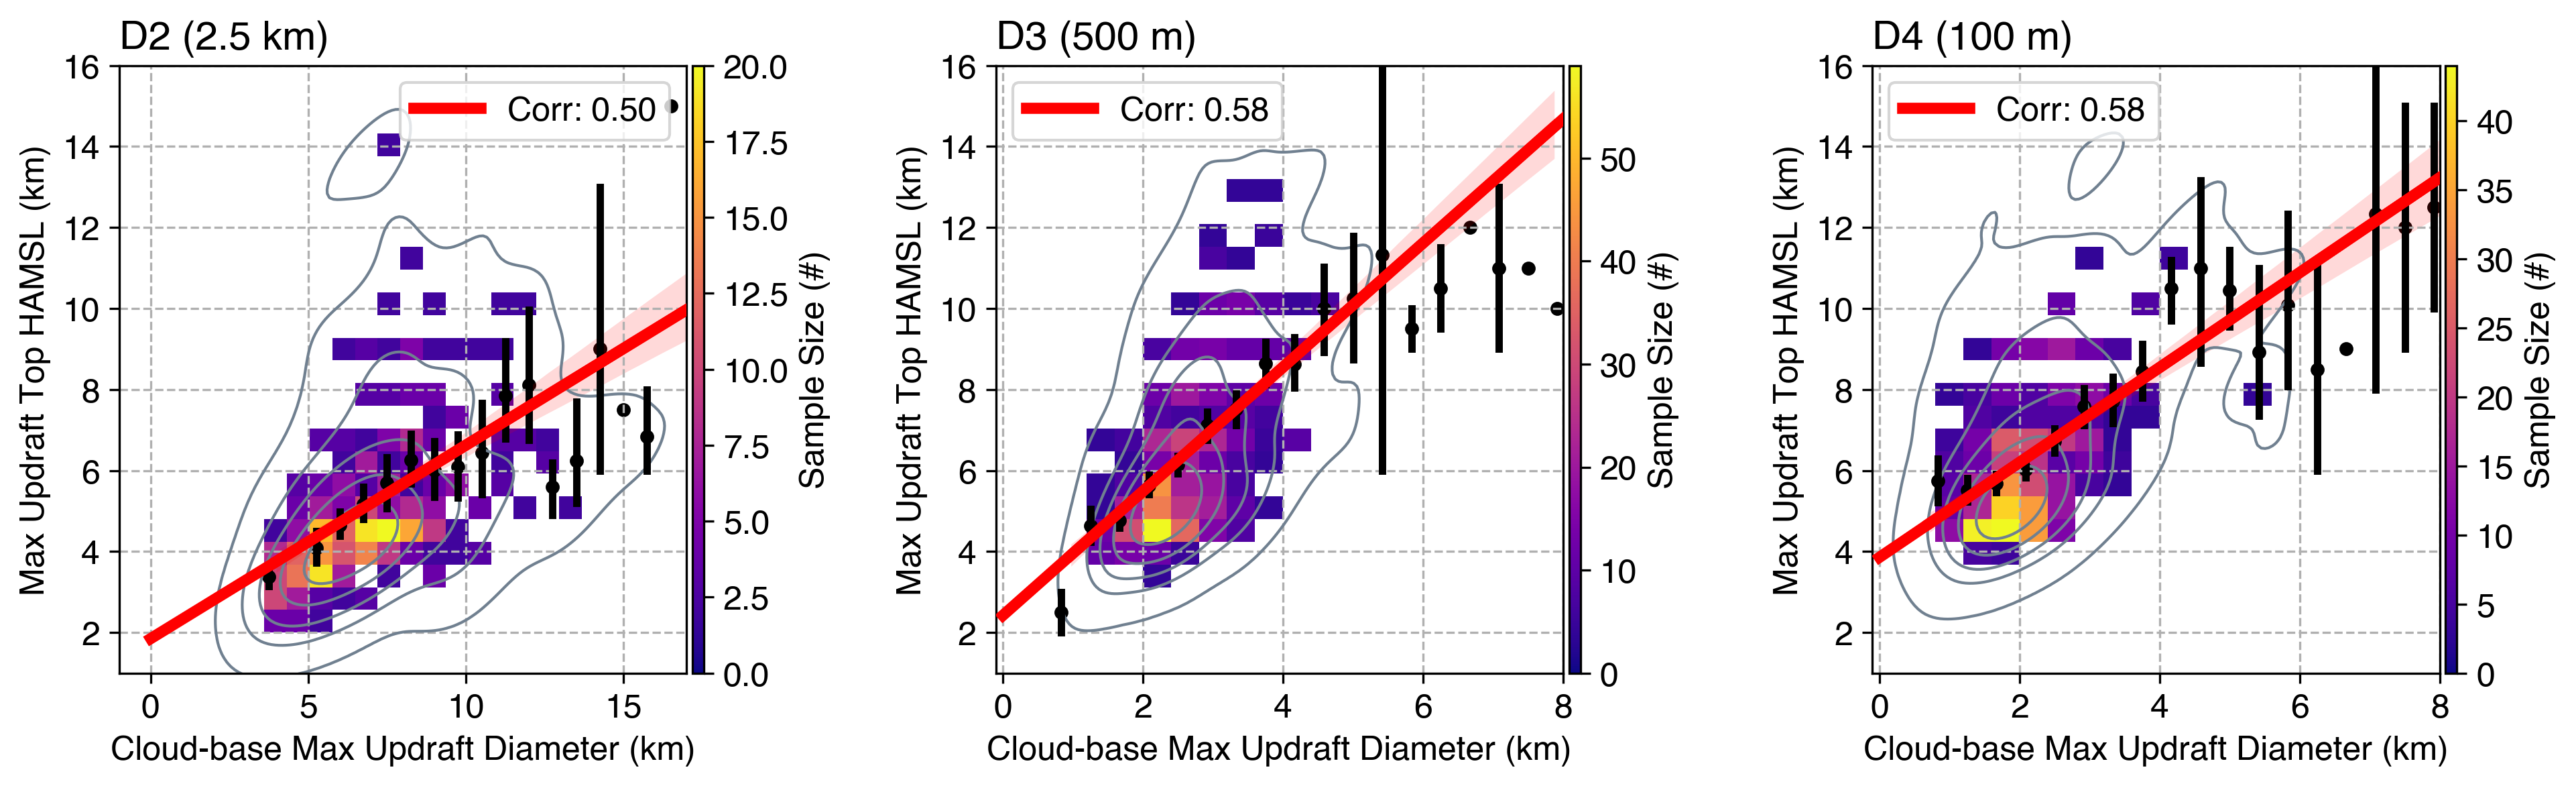

In [75]:
dfs = [[df_d2, df_d3, df_d4]]
nrow = len(dfs)
ncol = len(dfs[0])
x_name = 'Max Updraft Diameter'
y_name = 'Max Updraft Top Height'

# Histogram
x_bins1 = 25
x_bins2 = 25
x_bins3 = 25
bins_hist = [[x_bins1, x_bins2, x_bins3]]
# bin_range1 = ((0,150),(2,16))
# bin_range2 = ((0,20),(2,16))
# bin_range3 = ((0,20),(2,16))
bin_range1 = ((0,18),(2,16))
bin_range2 = ((0,10),(2,16))
bin_range3 = ((0,10),(2,16))
bin_range = [[bin_range1, bin_range2, bin_range3]]
cmaps = [['plasma']*ncol]
cbar_labels = [['Sample Size (#)']*ncol]
# KDE
kde_levels = [[6]*ncol]
kde_colors = [["slategrey"]*ncol]
# Regression plot
reg_xbins1 = np.linspace(min(bin_range1[0]), max(bin_range1[0]), x_bins1)
reg_xbins2 = np.linspace(min(bin_range2[0]), max(bin_range2[0]), x_bins2)
reg_xbins3 = np.linspace(min(bin_range3[0]), max(bin_range3[0]), x_bins3)
reg_xbins = [[reg_xbins1, reg_xbins2, reg_xbins3]]
# Axes, labels
# xlims = [[(-5,150),(-1,20),(-1,20)]]
xlims = [[(-1,17),(-0.1,8),(-0.1,8)]]
ylims = [[(1,16)]*ncol]
xlabels = [['Cloud-base Max Updraft Diameter (km)']*ncol]
ylabels = [['Max Updraft Top HAMSL (km)']*ncol]
titles = [['D2 (2.5 km)', 'D3 (500 m)', 'D4 (100 m)']]
# Figure
fontsize = 12
figsize = (15,4)
figname = f'{figdir}regplot_MaxWDiam_MaxWTop_d2_d3_d4.png'
wspace = 0.5
hspace = None
dpi = 300

fig = mxn_regplot(nrow, ncol, dfs, x_name, y_name, bins_hist=bins_hist, bin_range=bin_range, cmaps=cmaps, cbar_labels=cbar_labels, kde_levels=kde_levels, kde_colors=kde_colors, 
                  wspace=wspace, hspace=hspace, reg_xbins=reg_xbins,
                  xlims=xlims, ylims=ylims, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)

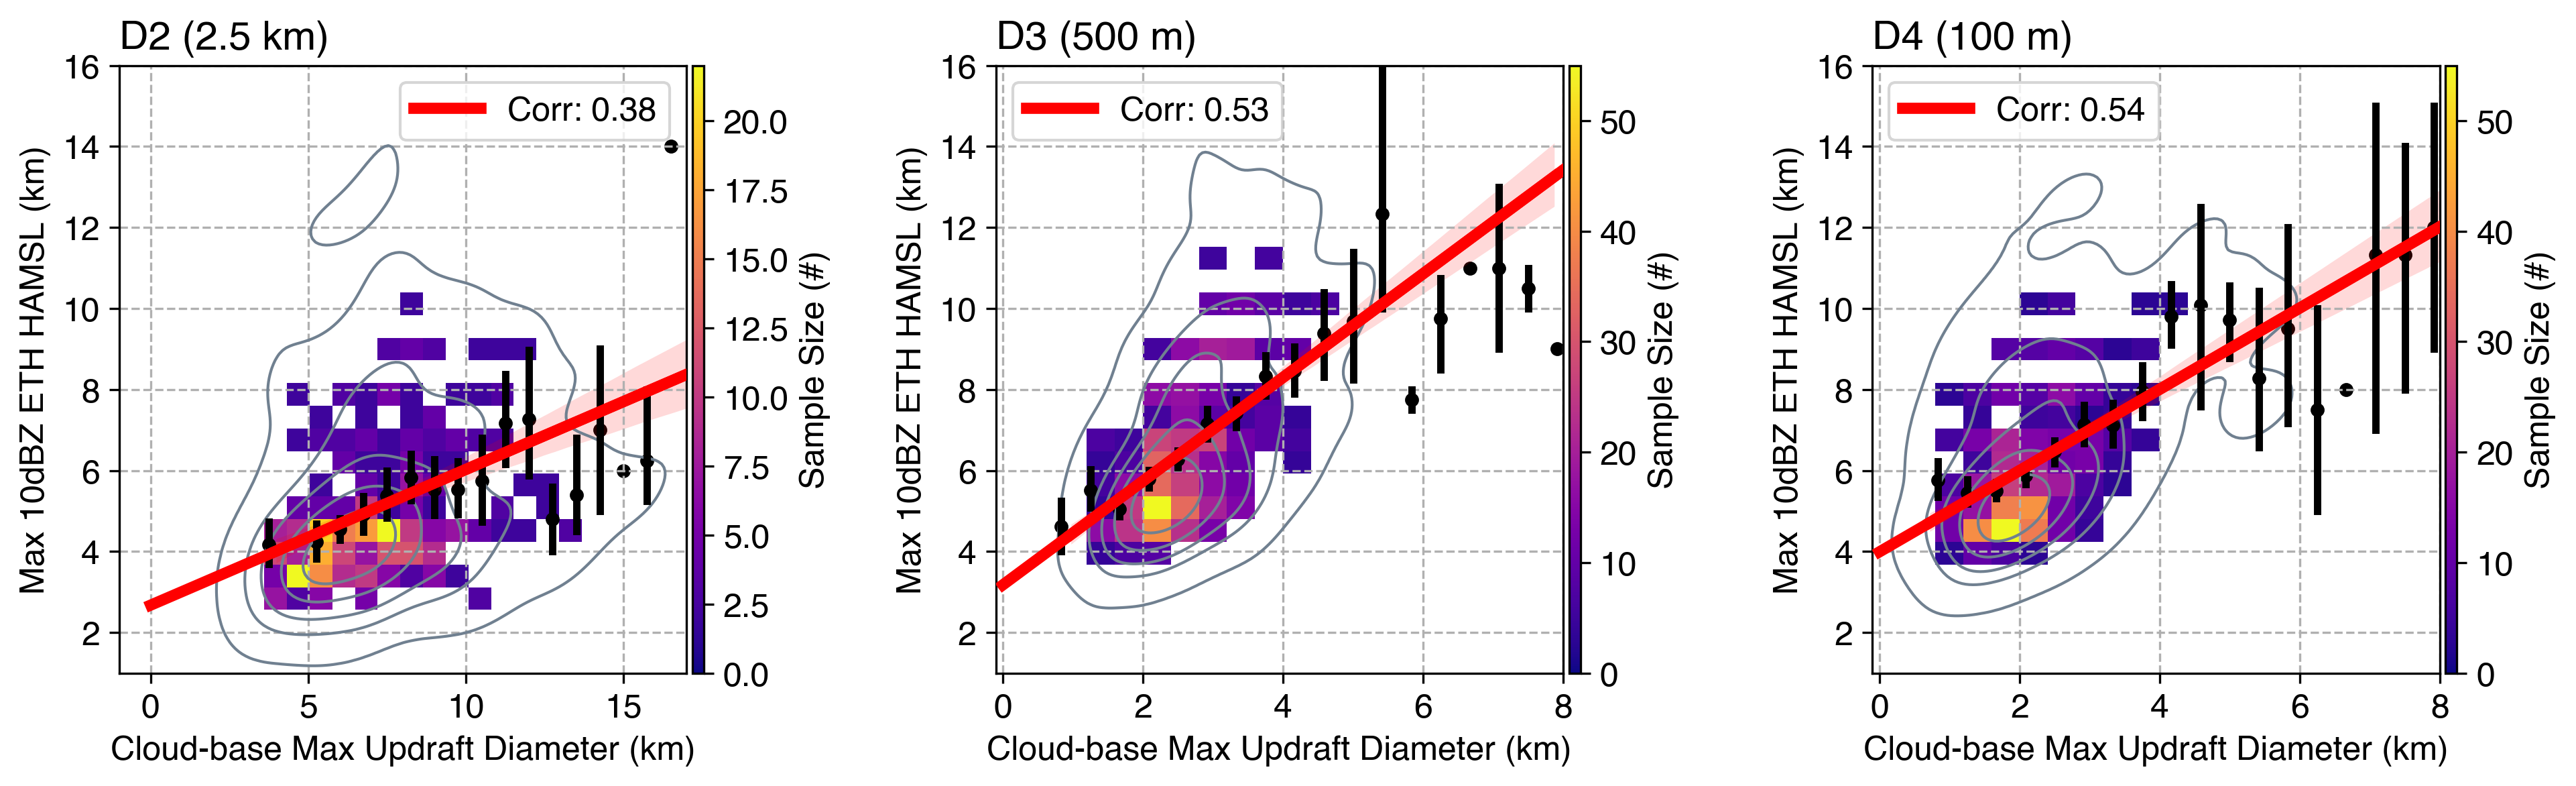

In [76]:
dfs = [[df_d2, df_d3, df_d4]]
nrow = len(dfs)
ncol = len(dfs[0])
x_name = 'Max Updraft Diameter'
y_name = 'Max 10dBZ ETH'

# Histogram
x_bins1 = 25
x_bins2 = 25
x_bins3 = 25
bins_hist = [[x_bins1, x_bins2, x_bins3]]
bin_range1 = ((0,18),(2,16))
bin_range2 = ((0,10),(2,16))
bin_range3 = ((0,10),(2,16))
bin_range = [[bin_range1, bin_range2, bin_range3]]
cmaps = [['plasma']*ncol]
cbar_labels = [['Sample Size (#)']*ncol]
# KDE
kde_levels = [[6]*ncol]
kde_colors = [["slategrey"]*ncol]
# Regression plot
reg_xbins1 = np.linspace(min(bin_range1[0]), max(bin_range1[0]), x_bins1)
reg_xbins2 = np.linspace(min(bin_range2[0]), max(bin_range2[0]), x_bins2)
reg_xbins3 = np.linspace(min(bin_range3[0]), max(bin_range3[0]), x_bins3)
reg_xbins = [[reg_xbins1, reg_xbins2, reg_xbins3]]
# Axes, labels
xlims = [[(-1,17),(-0.1,8),(-0.1,8)]]
ylims = [[(1,16)]*ncol]
xlabels = [['Cloud-base Max Updraft Diameter (km)']*ncol]
ylabels = [['Max 10dBZ ETH HAMSL (km)']*ncol]
titles = [['D2 (2.5 km)', 'D3 (500 m)', 'D4 (100 m)']]
# Figure
fontsize = 12
figsize = (15,4)
figname = f'{figdir}regplot_MaxWDiam_MaxETH10dBZ_d2_d3_d4.png'
wspace = 0.5
hspace = None
dpi = 300

fig = mxn_regplot(nrow, ncol, dfs, x_name, y_name, bins_hist=bins_hist, bin_range=bin_range, cmaps=cmaps, cbar_labels=cbar_labels, kde_levels=kde_levels, kde_colors=kde_colors, 
                  wspace=wspace, hspace=hspace, reg_xbins=reg_xbins,
                  xlims=xlims, ylims=ylims, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+1h/regplot_MaxWDiam_MaxCellDiam_d2_d3_d4.png


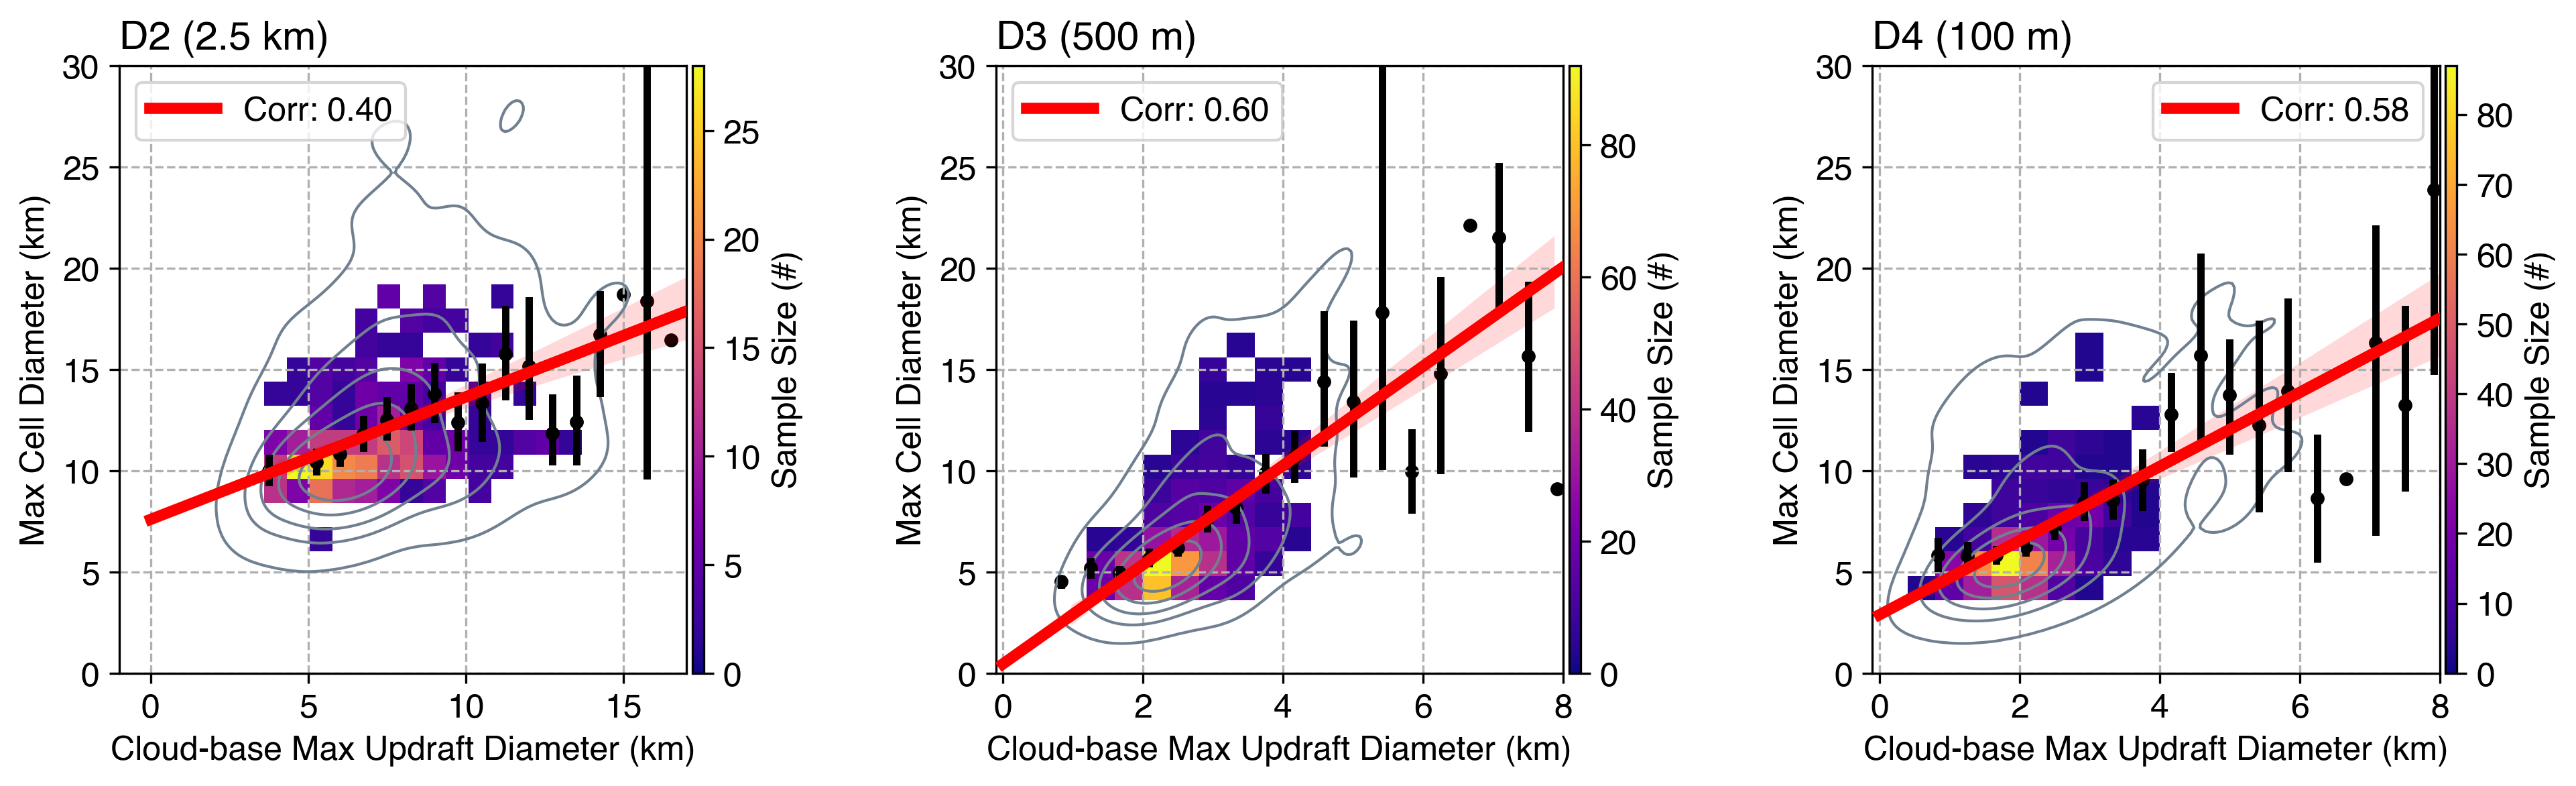

In [77]:
dfs = [[df_d2, df_d3, df_d4]]
nrow = len(dfs)
ncol = len(dfs[0])
x_name = 'Max Updraft Diameter'
y_name = 'Max Cell Diameter'

# Histogram
x_bins1 = 25
x_bins2 = 25
x_bins3 = 25
bins_hist = [[x_bins1, x_bins2, x_bins3]]
# bin_range1 = ((0,150),(0,30))
# bin_range2 = ((0,20),(0,30))
# bin_range3 = ((0,20),(0,30))
bin_range1 = ((0,18),(0,30))
bin_range2 = ((0,10),(0,30))
bin_range3 = ((0,10),(0,30))
bin_range = [[bin_range1, bin_range2, bin_range3]]
cmaps = [['plasma']*ncol]
cbar_labels = [['Sample Size (#)']*ncol]
# KDE
kde_levels = [[6]*ncol]
kde_colors = [["slategrey"]*ncol]
# Regression plot
reg_xbins1 = np.linspace(min(bin_range1[0]), max(bin_range1[0]), x_bins1)
reg_xbins2 = np.linspace(min(bin_range2[0]), max(bin_range2[0]), x_bins2)
reg_xbins3 = np.linspace(min(bin_range3[0]), max(bin_range3[0]), x_bins3)
reg_xbins = [[reg_xbins1, reg_xbins2, reg_xbins3]]
# Axes, labels
xlims = [[(-1,17),(-0.1,8),(-0.1,8)]]
ylims = [[(0,30),(0,30),(0,30)]]
xlabels = [['Cloud-base Max Updraft Diameter (km)']*ncol]
ylabels = [['Max Cell Diameter (km)']*ncol]
titles = [['D2 (2.5 km)', 'D3 (500 m)', 'D4 (100 m)']]
# Figure
fontsize = 12
figsize = (15,4)
figname = f'{figdir}regplot_MaxWDiam_MaxCellDiam_d2_d3_d4.png'
wspace = 0.5
hspace = None
dpi = 300
print(figname)
fig = mxn_regplot(nrow, ncol, dfs, x_name, y_name, bins_hist=bins_hist, bin_range=bin_range, cmaps=cmaps, cbar_labels=cbar_labels, kde_levels=kde_levels, kde_colors=kde_colors, 
                  wspace=wspace, hspace=hspace, reg_xbins=reg_xbins,
                  xlims=xlims, ylims=ylims, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)

## Plot cell diameter & ETH PDF with narrow & wide cell cutoffs

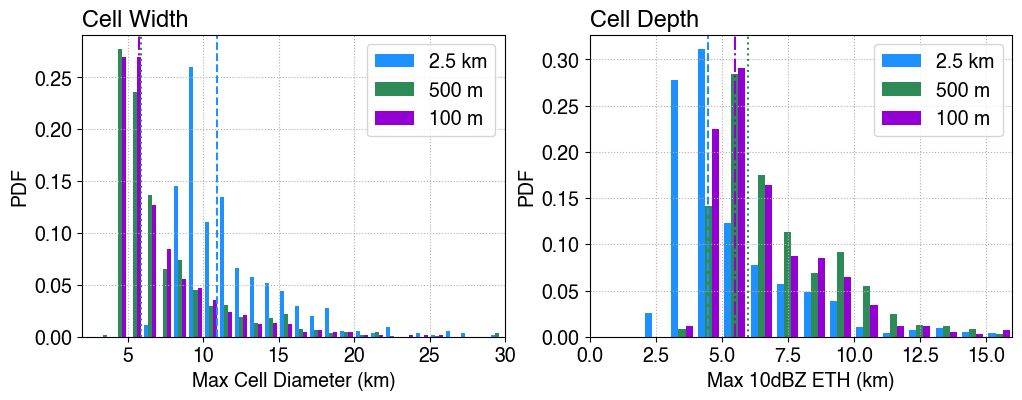

In [78]:
mpl.rcParams['font.size'] = 14
mpl.rcParams['font.family'] = 'Helvetica'

fig, axes = plt.subplots(1, 2, figsize=(12,4), dpi=100)
lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}

ax = axes[0]
bins = np.arange(2, 31, 1)
bar_data = [trackmaxCellDiam_d2, trackmaxCellDiam_d3, trackmaxCellDiam_d4]
bar_labels = list(name_map.values())
bar_colors = list(lcolors.values())
ax.hist(bar_data, bins=bins, alpha=1, label=bar_labels, histtype='bar', color=bar_colors, density=True)
ax.legend()
# Percentile lines
ax.axvline(maxCellDiam_pts_d2.sel(quantile=0.5), ls='--', color=lcolors['d2'],)
ax.axvline(maxCellDiam_pts_d3.sel(quantile=0.5), ls=':', color=lcolors['d3'],)
ax.axvline(maxCellDiam_pts_d4.sel(quantile=0.5), ls='dashdot', color=lcolors['d4'],)
# ax.axvline(maxCellDiam_pts_d2.sel(quantile=0.33), ls='--', color=lcolors['d2'],)
# ax.axvline(maxCellDiam_pts_d2.sel(quantile=0.66), ls='--', color=lcolors['d2'],)
# ax.axvline(maxCellDiam_pts_d3.sel(quantile=0.33), ls=':', color=lcolors['d3'],)
# ax.axvline(maxCellDiam_pts_d3.sel(quantile=0.66), ls=':', color=lcolors['d3'],)
# ax.axvline(maxCellDiam_pts_d4.sel(quantile=0.33), ls='dashdot', color=lcolors['d4'],)
# ax.axvline(maxCellDiam_pts_d4.sel(quantile=0.66), ls='dashdot', color=lcolors['d4'],)
ax.set_xlim((2,30))
ax.set_xlabel('Max Cell Diameter (km)')
ax.set_ylabel('PDF')
ax.set_title('Cell Width', loc='left')
ax.grid(ls=':')

ax = axes[1]
bins = np.arange(0, 17, 1)
bar_data = [trackmaxETH_10dbz_d2, trackmaxETH_10dbz_d3, trackmaxETH_10dbz_d4]
ax.hist(bar_data, bins=bins, alpha=1, label=bar_labels, histtype='bar', color=bar_colors, density=True)

# Percentile lines
ax.axvline(max10dbz_pts_d2.sel(quantile=0.5), ls='--', color=lcolors['d2'],)
ax.axvline(max10dbz_pts_d3.sel(quantile=0.5), ls=':', color=lcolors['d3'],)
ax.axvline(max10dbz_pts_d4.sel(quantile=0.5), ls='dashdot', color=lcolors['d4'],)
# ax.axvline(max10dbz_pts_d2.sel(quantile=0.33), ls='--', color=lcolors['d2'],)
# ax.axvline(max10dbz_pts_d2.sel(quantile=0.66), ls='--', color=lcolors['d2'],)
# ax.axvline(max10dbz_pts_d3.sel(quantile=0.33), ls=':', color=lcolors['d3'],)
# ax.axvline(max10dbz_pts_d3.sel(quantile=0.66), ls=':', color=lcolors['d3'],)
# ax.axvline(max10dbz_pts_d4.sel(quantile=0.33), ls='dashdot', color=lcolors['d4'],)
# ax.axvline(max10dbz_pts_d4.sel(quantile=0.66), ls='dashdot', color=lcolors['d4'],)
ax.legend()
ax.set_xlim((0,16))
ax.set_xlabel('Max 10dBZ ETH (km)')
ax.set_ylabel('PDF')
ax.set_title('Cell Depth', loc='left')
ax.grid(ls=':')

# figname = f'{figdir}PDF_maxCellDiam_maxETH10dBZ_d2_d3_d4.png'
# fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

## Separate narrow vs. wide cell DataSets

In [79]:
MULNB_d2.shape, trackmaxCellDiam_d2.shape

((543,), (543,))

In [80]:
# MU LNB threshold, cells must have LNB > this to be retained in the subsequent analysis
MULNB_thresh = 6.0  # [km]

# Quantiles for narrow & wide
# narrow_qt = 0.33
# wide_qt = 0.66
narrow_qt = 0.5
# wide_qt = 0.66
wide_qt = 0.75

# Threshold for max distance between updraft base and LCL height [km]
max_Wbase_LCL_dist = 2.0
# Threshold for updraft top fit line slope
min_Wtop_slope = 0

In [81]:
# # True/False flag for positive slope
# Wtop_Pslope_d2 = dsnms_d2.Wtop_slope > min_Wtop_slope
# # True/False flag for updraft base height from LCL
# Wbase_LCL_diff_d2 = dsnms_d2.Wbase_LCL_diff <= max_Wbase_LCL_dist
# # Both positive slope & updraft base flag
# Wkeep_flag_d2 = (Wtop_Pslope_d2 & Wbase_LCL_diff_d2).compute()
# # # Wkeep_flag_d2
# # # Track indicies to keep
# # Wid_keep_d2 = np.where(Wkeep_flag_d2)[0]
# # ntracksW_d2 = len(Wid_keep_d2)

In [82]:
trackmaxCellDiam_d2.shape, dsnms_d2.Wtop_slope.shape, dsnms_d2.Wbase_LCL_diff.shape

((543,), (543,), (543,))

In [83]:
# Define narrow vs. wide thresholds
narrow_diam_d2 = maxCellDiam_pts_d2.sel(quantile=narrow_qt).item()
wide_diam_d2 = maxCellDiam_pts_d2.sel(quantile=wide_qt).item()
print(f'Narrow diameter threshold (D2): {narrow_diam_d2:.02f} km')
print(f'Wide diameter threshold (D2): {wide_diam_d2:.02f} km')

# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
narrow_tracks_d2 = ((trackmaxCellDiam_d2 < narrow_diam_d2) & (MULNB_d2 > MULNB_thresh) \
                    & (dsnms_d2.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# wide_tracks_d2 = ((trackmaxCellDiam_d2 >= wide_diam_d2) & (MULNB_d2 > MULNB_thresh)).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d2 = ((trackmaxCellDiam_d2 >= wide_diam_d2) & (MULNB_d2 > MULNB_thresh) \
                  & (dsnms_d2.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d2.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                 ).compute()
# Subset DataSets
ds_narrow_d2 = dsnms_d2.where(narrow_tracks_d2, drop=True)
ds_wide_d2 = dsnms_d2.where(wide_tracks_d2, drop=True)
ntracks_narrow_d2 = ds_narrow_d2.sizes['tracks']
ntracks_wide_d2 = ds_wide_d2.sizes['tracks']
print(f'Number of narrow cells (D2): {ntracks_narrow_d2}')
print(f'Number of wide cells (D2): {ntracks_wide_d2}')

# # Get cell track lifetime: track_duration x time_resolution [min]
# narrow_track_lifetime_d2 = ds_narrow_d2.track_duration * time_res
# wide_track_lifetime_d2 = ds_wide_d2.track_duration * time_res
# # Lifetime-max reflectivity
# narrow_maxdbz_d2 = ds_narrow_d2.max_dbz.max(dim='times')
# wide_maxdbz_d2 = ds_wide_d2.max_dbz.max(dim='times')
# # Lifetime-max 10dBZ ETH
# narrow_maxETH10dbz_d2 = ds_narrow_d2.maxETH_10dbz.max(dim='times')
# wide_maxETH10dbz_d2 = ds_wide_d2.maxETH_10dbz.max(dim='times')
# # Lifetime-max diameter
# narrow_maxdiam_d2 = 2 * np.sqrt(ds_narrow_d2.cell_area.max(dim='times') / np.pi)
# wide_maxdiam_d2 = 2 * np.sqrt(ds_wide_d2.cell_area.max(dim='times') / np.pi)

# CI-window lifetime (count number of time a cell exists in the CI window)
narrow_track_lifetime_d2 = (ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
wide_track_lifetime_d2 = (ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# CI-max reflectivity
narrow_maxdbz_d2 = ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).max_dbz.max(dim='times')
wide_maxdbz_d2 = ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).max_dbz.max(dim='times')
# CI-max 10dBZ ETH
narrow_maxETH10dbz_d2 = ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times')
wide_maxETH10dbz_d2 = ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times')
# CI-max diameter
narrow_maxdiam_d2 = 2 * np.sqrt(ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).cell_area.max(dim='times') / np.pi)
wide_maxdiam_d2 = 2 * np.sqrt(ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).cell_area.max(dim='times') / np.pi)
# CI-window cloud-base updraft diameter
narrow_medWdiam_d2 = 2 * np.sqrt(ds_narrow_d2.Warea_median / np.pi)
wide_medWdiam_d2 = 2 * np.sqrt(ds_wide_d2.Warea_median / np.pi)
narrow_maxWdiam_d2 = 2 * np.sqrt(ds_narrow_d2.Warea_max / np.pi)
wide_maxWdiam_d2 = 2 * np.sqrt(ds_wide_d2.Warea_max / np.pi)
# CI-window cloud-base updraft speed
narrow_maxWspeed_d2 = ds_narrow_d2.Wspeed_max
wide_maxWspeed_d2 = ds_wide_d2.Wspeed_max

Narrow diameter threshold (D2): 10.93 km
Wide diameter threshold (D2): 13.53 km
Number of narrow cells (D2): 228
Number of wide cells (D2): 137


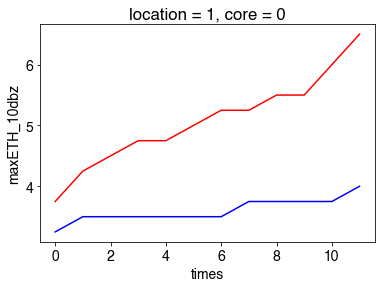

In [84]:
ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.median(dim='tracks').plot(color='b')
ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.median(dim='tracks').plot(color='r')

(array([ 0.,  0.,  0.,  1.,  3.,  4., 18., 18., 16., 17., 18.,  7.,  6.,
         7.,  1.,  6.,  5.,  2.,  4.,  2.,  0.,  1.,  1.]),
 array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
         5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5,
        11. , 11.5]),
 <BarContainer object of 23 artists>)

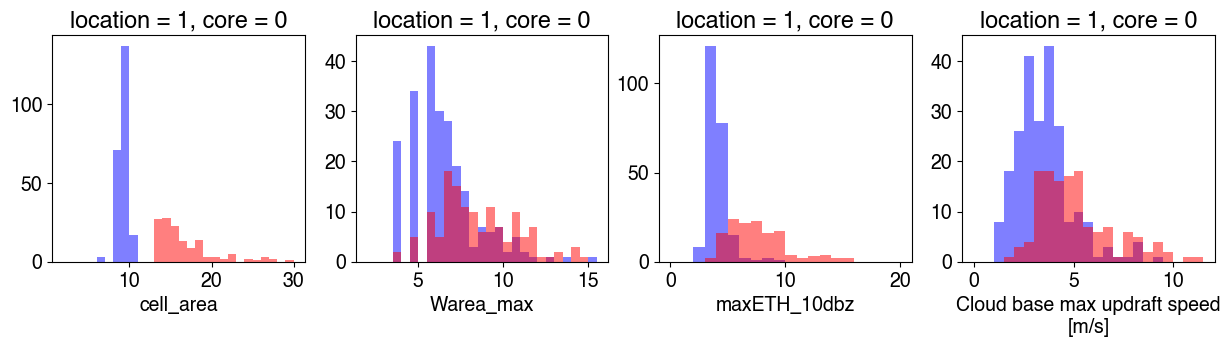

In [85]:
fig, axes = plt.subplots(1, 4, figsize=(15,3), dpi=100)
ax0 = axes[0]
bins = np.arange(2, 31, 1)
narrow_maxdiam_d2.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax0)
wide_maxdiam_d2.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax0)
ax1 = axes[1]
bins = np.arange(2, 16, 0.5)
narrow_maxWdiam_d2.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax1)
wide_maxWdiam_d2.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax1)
ax2 = axes[2]
bins = np.arange(0, 21, 1)
narrow_maxETH10dbz_d2.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax2)
wide_maxETH10dbz_d2.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax2)
ax3 = axes[3]
bins = np.arange(0, 12, 0.5)
narrow_maxWspeed_d2.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax3)
wide_maxWspeed_d2.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax3)

In [86]:
# Define narrow vs. wide thresholds
narrow_diam_d3 = maxCellDiam_pts_d3.sel(quantile=narrow_qt).item()
wide_diam_d3 = maxCellDiam_pts_d3.sel(quantile=wide_qt).item()
print(f'Narrow diameter threshold (D3): {narrow_diam_d3:.02f} km')
print(f'Wide diameter threshold (D3): {wide_diam_d3:.02f} km')

# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
narrow_tracks_d3 = ((trackmaxCellDiam_d3 < narrow_diam_d3) & (MULNB_d3 > MULNB_thresh) \
                    & (dsnms_d3.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# wide_tracks_d3 = ((trackmaxCellDiam_d3 >= wide_diam_d3) & (MULNB_d3 > MULNB_thresh)).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d3 = ((trackmaxCellDiam_d3 >= wide_diam_d3) & (MULNB_d3 > MULNB_thresh) \
                  & (dsnms_d3.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d3.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                 ).compute()
# Subset DataSets
ds_narrow_d3 = dsnms_d3.where(narrow_tracks_d3, drop=True)
ds_wide_d3 = dsnms_d3.where(wide_tracks_d3, drop=True)
ntracks_narrow_d3 = ds_narrow_d3.sizes['tracks']
ntracks_wide_d3 = ds_wide_d3.sizes['tracks']
print(f'Number of narrow cells (D3): {ntracks_narrow_d3}')
print(f'Number of wide cells (D3): {ntracks_wide_d3}')

# # Get cell track lifetime: track_duration x time_resolution [min]
# narrow_track_lifetime_d3 = ds_narrow_d3.track_duration * time_res
# wide_track_lifetime_d3 = ds_wide_d3.track_duration * time_res
# # Lifetime-max reflectivity
# narrow_maxdbz_d3 = ds_narrow_d3.max_dbz.max(dim='times')
# wide_maxdbz_d3 = ds_wide_d3.max_dbz.max(dim='times')
# # Lifetime-max 10dBZ ETH
# narrow_maxETH10dbz_d3 = ds_narrow_d3.maxETH_10dbz.max(dim='times')
# wide_maxETH10dbz_d3 = ds_wide_d3.maxETH_10dbz.max(dim='times')
# # Lifetime-max diameter
# narrow_maxdiam_d3 = 2 * np.sqrt(ds_narrow_d3.cell_area.max(dim='times') / np.pi)
# wide_maxdiam_d3 = 2 * np.sqrt(ds_wide_d3.cell_area.max(dim='times') / np.pi)

# CI-window lifetime (count number of time a cell exists in the CI window)
narrow_track_lifetime_d3 = (ds_narrow_d3.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
wide_track_lifetime_d3 = (ds_wide_d3.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# CI-max reflectivity
narrow_maxdbz_d3 = ds_narrow_d3.isel(times=slice(tidx_start, tidx_end)).max_dbz.max(dim='times')
wide_maxdbz_d3 = ds_wide_d3.isel(times=slice(tidx_start, tidx_end)).max_dbz.max(dim='times')
# CI-max 10dBZ ETH
narrow_maxETH10dbz_d3 = ds_narrow_d3.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times')
wide_maxETH10dbz_d3 = ds_wide_d3.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times')
# CI-max diameter
narrow_maxdiam_d3 = 2 * np.sqrt(ds_narrow_d3.isel(times=slice(tidx_start, tidx_end)).cell_area.max(dim='times') / np.pi)
wide_maxdiam_d3 = 2 * np.sqrt(ds_wide_d3.isel(times=slice(tidx_start, tidx_end)).cell_area.max(dim='times') / np.pi)
# CI-window cloud-base updraft diameter
narrow_medWdiam_d3 = 2 * np.sqrt(ds_narrow_d3.Warea_median / np.pi)
wide_medWdiam_d3 = 2 * np.sqrt(ds_wide_d3.Warea_median / np.pi)
narrow_maxWdiam_d3 = 2 * np.sqrt(ds_narrow_d3.Warea_max / np.pi)
wide_maxWdiam_d3 = 2 * np.sqrt(ds_wide_d3.Warea_max / np.pi)
# CI-window cloud-base updraft speed
narrow_maxWspeed_d3 = ds_narrow_d3.Wspeed_max
wide_maxWspeed_d3 = ds_wide_d3.Wspeed_max

Narrow diameter threshold (D3): 5.89 km
Wide diameter threshold (D3): 8.37 km
Number of narrow cells (D3): 449
Number of wide cells (D3): 226


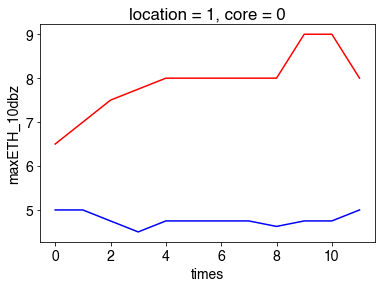

In [87]:
ds_narrow_d3.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.median(dim='tracks').plot(color='b')
ds_wide_d3.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.median(dim='tracks').plot(color='r')

(array([ 0.,  0.,  0.,  0.,  0.,  2., 10., 26., 26., 37., 29., 33., 20.,
        12., 19.,  3.,  4.,  2.,  1.,  2.,  0.,  0.,  0.]),
 array([ 2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,  5.5,  6. ,  6.5,  7. ,
         7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5, 11. , 11.5, 12. , 12.5,
        13. , 13.5]),
 <BarContainer object of 23 artists>)

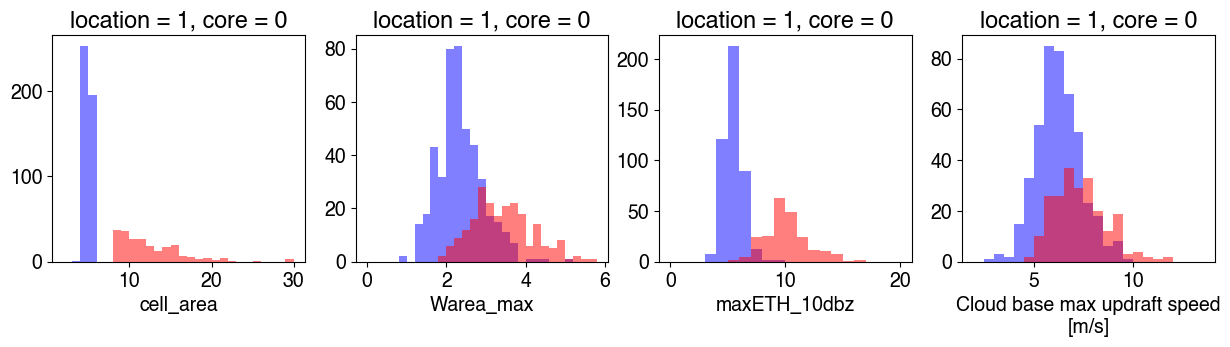

In [88]:
fig, axes = plt.subplots(1, 4, figsize=(15,3), dpi=100)
ax0 = axes[0]
bins = np.arange(2, 31, 1)
narrow_maxdiam_d3.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax0)
wide_maxdiam_d3.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax0)
ax1 = axes[1]
bins = np.arange(0, 6, 0.2)
narrow_maxWdiam_d3.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax1)
wide_maxWdiam_d3.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax1)
ax2 = axes[2]
bins = np.arange(0, 21, 1)
narrow_maxETH10dbz_d3.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax2)
wide_maxETH10dbz_d3.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax2)
ax3 = axes[3]
bins = np.arange(2, 14, 0.5)
narrow_maxWspeed_d3.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax3)
wide_maxWspeed_d3.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax3)

In [89]:
# Define narrow vs. wide thresholds
narrow_diam_d4 = maxCellDiam_pts_d4.sel(quantile=narrow_qt).item()
wide_diam_d4 = maxCellDiam_pts_d4.sel(quantile=wide_qt).item()
print(f'Narrow diameter threshold (D4): {narrow_diam_d4:.02f} km')
print(f'Wide diameter threshold (D4): {wide_diam_d4:.02f} km')

# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
narrow_tracks_d4 = ((trackmaxCellDiam_d4 < narrow_diam_d4) & (MULNB_d4 > MULNB_thresh) \
                   & (dsnms_d4.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# wide_tracks_d4 = ((trackmaxCellDiam_d4 >= wide_diam_d4) & (MULNB_d4 > MULNB_thresh)).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d4 = ((trackmaxCellDiam_d4 >= wide_diam_d4) & (MULNB_d4 > MULNB_thresh) \
                  & (dsnms_d4.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d4.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                 ).compute()
# Subset DataSets
ds_narrow_d4 = dsnms_d4.where(narrow_tracks_d4, drop=True)
ds_wide_d4 = dsnms_d4.where(wide_tracks_d4, drop=True)
ntracks_narrow_d4 = ds_narrow_d4.sizes['tracks']
ntracks_wide_d4 = ds_wide_d4.sizes['tracks']
print(f'Number of narrow cells (D4): {ntracks_narrow_d4}')
print(f'Number of wide cells (D4): {ntracks_wide_d4}')

# # Get cell track lifetime: track_duration x time_resolution [min]
# narrow_track_lifetime_d4 = ds_narrow_d4.track_duration * time_res
# wide_track_lifetime_d4 = ds_wide_d4.track_duration * time_res
# # Lifetime-max reflectivity
# narrow_maxdbz_d4 = ds_narrow_d4.max_dbz.max(dim='times')
# wide_maxdbz_d4 = ds_wide_d4.max_dbz.max(dim='times')
# # Lifetime-max 10dBZ ETH
# narrow_maxETH10dbz_d4 = ds_narrow_d4.maxETH_10dbz.max(dim='times')
# wide_maxETH10dbz_d4 = ds_wide_d4.maxETH_10dbz.max(dim='times')
# # Lifetime-max diameter
# narrow_maxdiam_d4 = 2 * np.sqrt(ds_narrow_d4.cell_area.max(dim='times') / np.pi)
# wide_maxdiam_d4 = 2 * np.sqrt(ds_wide_d4.cell_area.max(dim='times') / np.pi)
# CI-window lifetime (count number of time a cell exists in the CI window)
narrow_track_lifetime_d4 = (ds_narrow_d4.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
wide_track_lifetime_d4 = (ds_wide_d4.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# CI-max reflectivity
narrow_maxdbz_d4 = ds_narrow_d4.isel(times=slice(tidx_start, tidx_end)).max_dbz.max(dim='times')
wide_maxdbz_d4 = ds_wide_d4.isel(times=slice(tidx_start, tidx_end)).max_dbz.max(dim='times')
# CI-max 10dBZ ETH
narrow_maxETH10dbz_d4 = ds_narrow_d4.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times')
wide_maxETH10dbz_d4 = ds_wide_d4.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times')
# CI-max diameter
narrow_maxdiam_d4 = 2 * np.sqrt(ds_narrow_d4.isel(times=slice(tidx_start, tidx_end)).cell_area.max(dim='times') / np.pi)
wide_maxdiam_d4 = 2 * np.sqrt(ds_wide_d4.isel(times=slice(tidx_start, tidx_end)).cell_area.max(dim='times') / np.pi)
# CI-window cloud-base updraft diameter
narrow_medWdiam_d4 = 2 * np.sqrt(ds_narrow_d4.Warea_median / np.pi)
wide_medWdiam_d4 = 2 * np.sqrt(ds_wide_d4.Warea_median / np.pi)
narrow_maxWdiam_d4 = 2 * np.sqrt(ds_narrow_d4.Warea_max / np.pi)
wide_maxWdiam_d4 = 2 * np.sqrt(ds_wide_d4.Warea_max / np.pi)
# CI-window cloud-base updraft speed
narrow_maxWspeed_d4 = ds_narrow_d4.Wspeed_max
wide_maxWspeed_d4 = ds_wide_d4.Wspeed_max

Narrow diameter threshold (D4): 5.78 km
Wide diameter threshold (D4): 7.98 km
Number of narrow cells (D4): 392
Number of wide cells (D4): 183


(array([ 0.,  0.,  0.,  0.,  2.,  1.,  2.,  7., 20., 21., 28., 23., 30.,
        13., 12.,  6.,  4.,  4.,  3.,  1.,  2.,  0.,  1.]),
 array([ 2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,  5.5,  6. ,  6.5,  7. ,
         7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5, 11. , 11.5, 12. , 12.5,
        13. , 13.5]),
 <BarContainer object of 23 artists>)

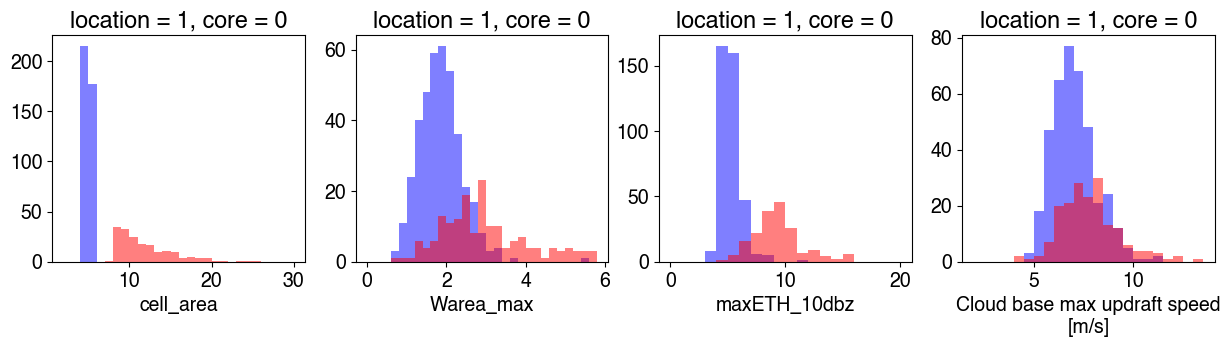

In [90]:
fig, axes = plt.subplots(1, 4, figsize=(15,3), dpi=100)
ax0 = axes[0]
bins = np.arange(2, 31, 1)
narrow_maxdiam_d4.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax0)
wide_maxdiam_d4.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax0)
ax1 = axes[1]
bins = np.arange(0, 6, 0.2)
narrow_maxWdiam_d4.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax1)
wide_maxWdiam_d4.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax1)
ax2 = axes[2]
bins = np.arange(0, 21, 1)
narrow_maxETH10dbz_d4.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax2)
wide_maxETH10dbz_d4.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax2)
ax3 = axes[3]
bins = np.arange(2, 14, 0.5)
narrow_maxWspeed_d4.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax3)
wide_maxWspeed_d4.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax3)

## Function to plot nrow x ncol of violin plot

In [91]:
def plot_mxn_violin(nrow, ncol, da, qnt1=None, qnt2=None, qnt_values=None, qnt_labels=None, samplesize=None, ypos_sample=None, wspace=None, hspace=None,
                    ylabels=None, ylims=None, titles=None, fontsize=None, figsize=None, figname=None):

    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    
    # fig, axes = plt.subplots(nrow, ncol, figsize=figsize, dpi=100)
    fig = plt.figure(figsize=figsize, dpi=dpi)
    # Set up panels (nrow x ncol)
    h_ratios = list(np.repeat(1,nrow))
    w_ratios = list(np.repeat(1,ncol))
    wspace = wspace
    hspace = hspace
    gs = gridspec.GridSpec(nrow, ncol, figure=fig, height_ratios=h_ratios, width_ratios=w_ratios, wspace=wspace, hspace=hspace)

    lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
    name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}
    qnt_colors = {'d2':'deepskyblue', 'd3':'springgreen', 'd4':'violet'}
    lw_qnt = 2
    palette = list(lcolors.values())    
    lw_kde = 2
    size_avg = 60
    color_avg = 'red'
    color_med = 'white'
    xlabels = list(name_map.values())
    leg_fontsize = fontsize
       
    for row in range(nrow):
        for col in range(ncol):
            # ax = axes[row][col]
            gss = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=gs[row,col])
            ax = plt.subplot(gss[0])
            violin_data = da[row][col]
            qnt1_data = qnt1[row][col]
            qnt2_data = qnt2[row][col]
            qnt1_2 = qnt1_data[0]
            qnt1_3 = qnt1_data[1]
            qnt1_4 = qnt1_data[2]
            qnt2_2 = qnt2_data[0]
            qnt2_3 = qnt2_data[1]
            qnt2_4 = qnt2_data[2]

            # Calculate means and medians
            avg2 = np.nanmean(violin_data[0])
            avg3 = np.nanmean(violin_data[1])
            avg4 = np.nanmean(violin_data[2])
            med2 = np.nanmedian(violin_data[0])
            med3 = np.nanmedian(violin_data[1])
            med4 = np.nanmedian(violin_data[2])
            # Violin plot
            vp = sns.violinplot(data=violin_data, ax=ax, palette=palette, linewidth=lw_kde)
            # Plot median value as line
            ax.hlines(med2, -0.1, 0.1, lw=2, color=color_med, zorder=4)
            ax.hlines(med3, 0.9, 1.1, lw=2, color=color_med, zorder=4)
            ax.hlines(med4, 1.9, 2.1, lw=2, color=color_med, zorder=4)
            # Plot mean value as circle
            ax.scatter(0, avg2, color=color_avg, s=size_avg, zorder=3)
            ax.scatter(1, avg3, color=color_avg, s=size_avg, zorder=3)
            ax.scatter(2, avg4, color=color_avg, s=size_avg, zorder=3)
            # Plot quantile lines
            if col == 0:
                ax.hlines(qnt1_2, -0.4, 0.4, lw=lw_qnt, color=qnt_colors['d2'], zorder=5)
                ax.hlines(qnt1_3, 0.6, 1.4, lw=lw_qnt, color=qnt_colors['d3'], zorder=5)
                ax.hlines(qnt1_4, 1.6, 2.4, lw=lw_qnt, color=qnt_colors['d4'], zorder=5)
            
                ax.hlines(qnt2_2, -0.4, 0.4, lw=lw_qnt, color=qnt_colors['d2'], ls='--', zorder=5)
                ax.hlines(qnt2_3, 0.6, 1.4, lw=lw_qnt, color=qnt_colors['d3'], ls='--', zorder=5)
                ax.hlines(qnt2_4, 1.6, 2.4, lw=lw_qnt, color=qnt_colors['d4'], ls='--', zorder=5)
            # Set plots
            ax.set_xticklabels(xlabels)
            ax.set_ylabel(ylabels[row][col])
            ax.set_title(titles[row][col], loc='left')
            ax.grid(ls=':', axis='y')
            if ylims is not None: ax.set_ylim(ylims[row][col][0], ylims[row][col][1])
            if samplesize is not None:
                if (col == 0):
                    ax.text(0.05, ypos_sample[row], samplesize['d2'], color=lcolors['d2'], va='top', fontsize=leg_fontsize*0.7)
                    ax.text(1.05, ypos_sample[row], samplesize['d3'], color=lcolors['d3'], va='top', fontsize=leg_fontsize*0.7)
                    ax.text(2.05, ypos_sample[row], samplesize['d4'], color=lcolors['d4'], va='top', fontsize=leg_fontsize*0.7)
            # Legend
            if (col == 0):
                qnt_lab = qnt_labels[row][col]
                legend_handles = [mpl.lines.Line2D([0], [0], color='k', ls='-', lw=lw_qnt, label=f'{qnt_lab[0]} ({qnt_values[0]:.2f})'),
                                  mpl.lines.Line2D([0], [0], color='k', ls='--',  lw=lw_qnt, label=f'{qnt_lab[1]} ({qnt_values[1]:.2f})'),]
                legend = ax.legend(handles=legend_handles, handlelength=None, handletextpad=None, loc='best', fontsize=leg_fontsize, labelcolor='linecolor', ncol=3)
                ax.add_artist(legend)
            
    # fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+1h/Violin_NarrowWide_maxDiameter_maxETH10dBZ_d2_d3_d4.png


/tmp/ipykernel_2639464/3413894579.py:70: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)
/tmp/ipykernel_2639464/3413894579.py:70: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)


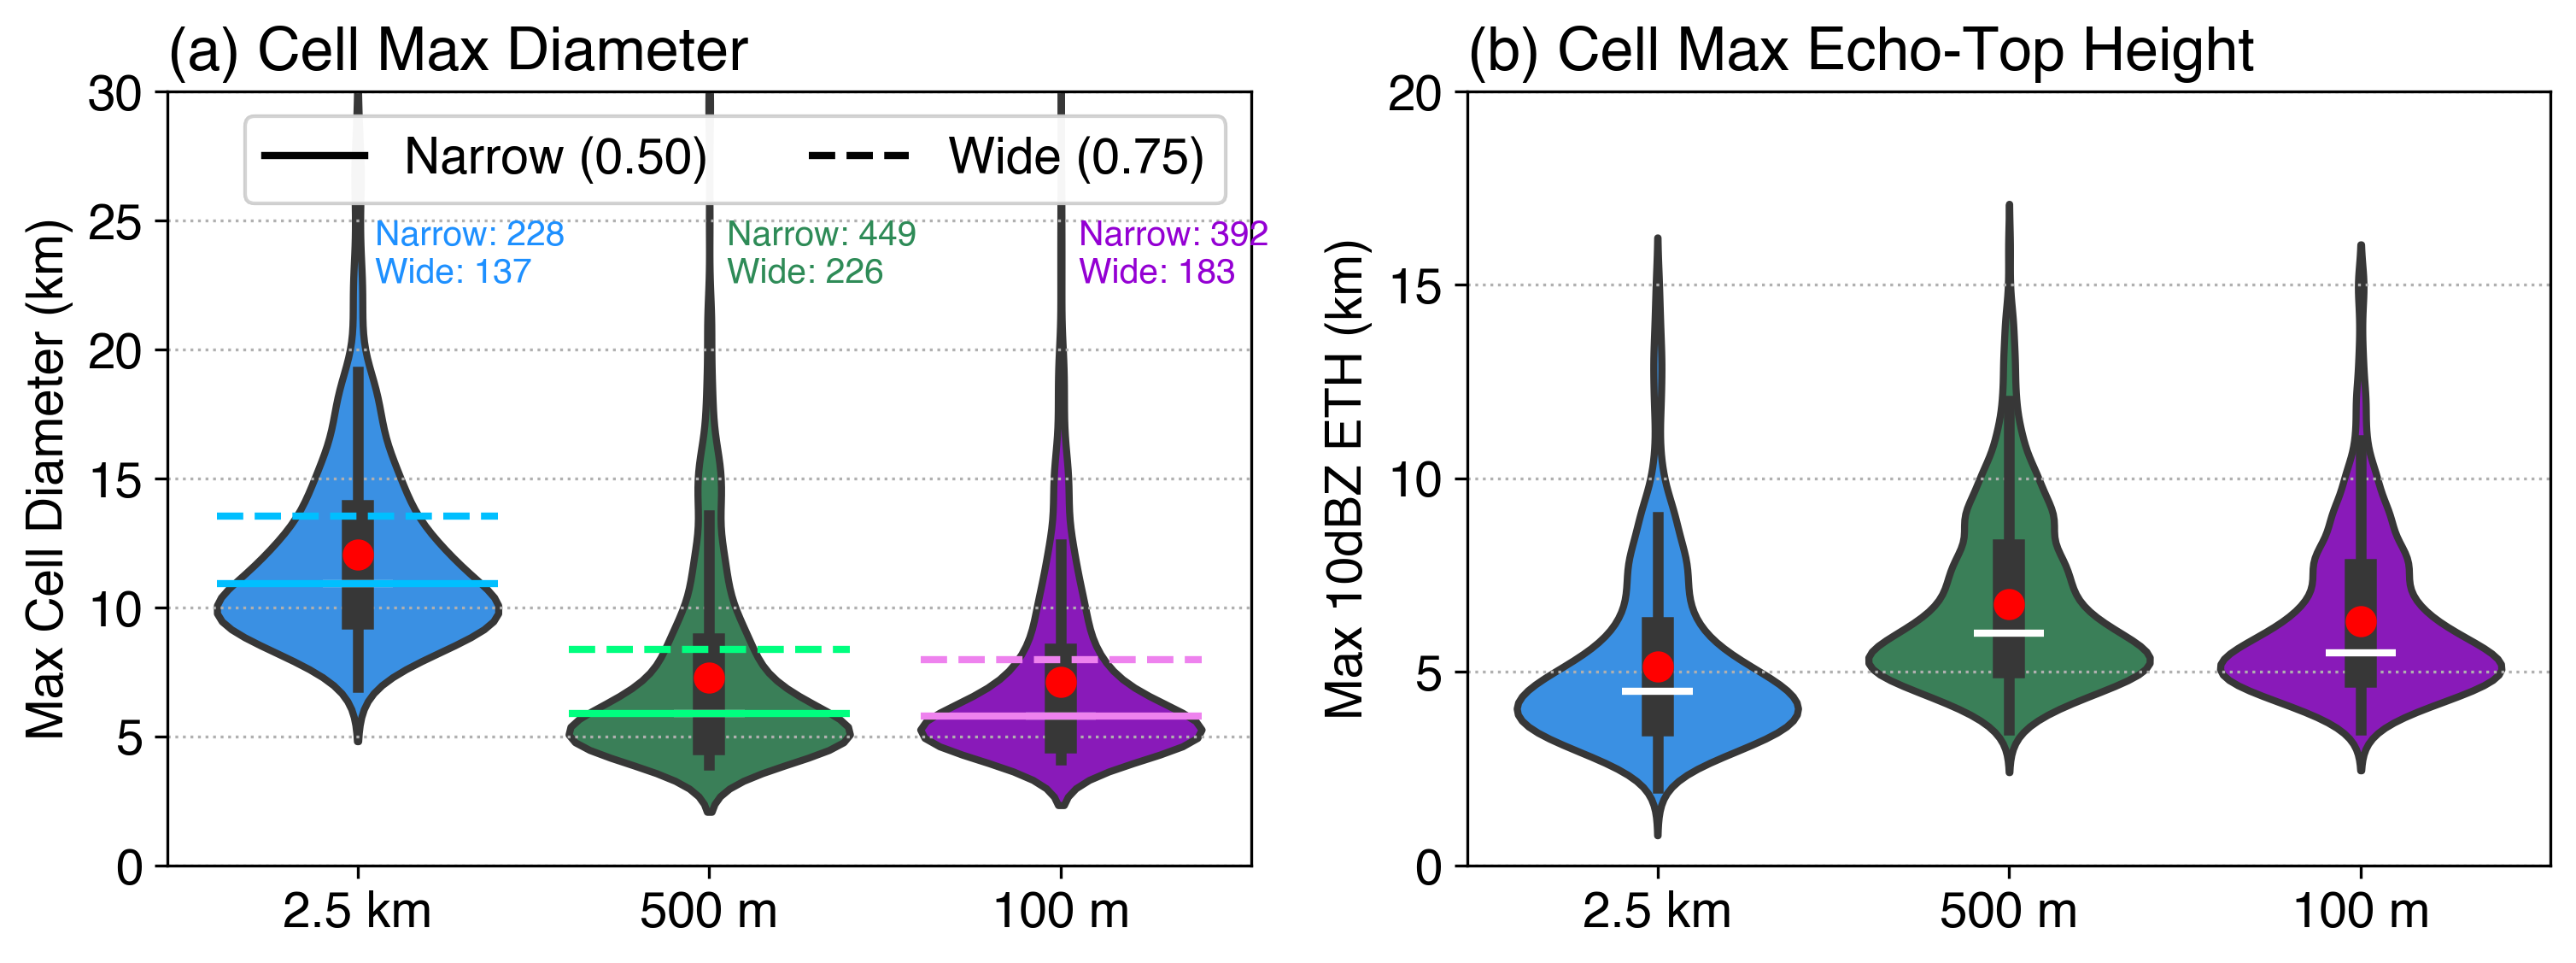

In [92]:
data_arr = [
    [[trackmaxCellDiam_d2.data, trackmaxCellDiam_d3.data, trackmaxCellDiam_d4.data],[trackmaxETH_10dbz_d2.data, trackmaxETH_10dbz_d3.data, trackmaxETH_10dbz_d4.data]]
]
qnt_narrow = [
    [[maxCellDiam_pts_d2.sel(quantile=narrow_qt).item(), maxCellDiam_pts_d3.sel(quantile=narrow_qt).item(), maxCellDiam_pts_d4.sel(quantile=narrow_qt).item()],
     [max10dbz_pts_d2.sel(quantile=narrow_qt).item(), max10dbz_pts_d3.sel(quantile=narrow_qt).item(), max10dbz_pts_d4.sel(quantile=narrow_qt).item()]]
]
qnt_wide = [
    [[maxCellDiam_pts_d2.sel(quantile=wide_qt).item(), maxCellDiam_pts_d3.sel(quantile=wide_qt).item(), maxCellDiam_pts_d4.sel(quantile=wide_qt).item()],
     [max10dbz_pts_d2.sel(quantile=wide_qt).item(), max10dbz_pts_d3.sel(quantile=wide_qt).item(), max10dbz_pts_d4.sel(quantile=wide_qt).item()]]
]
qnt_values = [narrow_qt, wide_qt]
qnt_labels = [[['Narrow','Wide'],['Shallow','Deep']]]
samplesize = {
    'd2': f"Narrow: {ntracks_narrow_d2}\nWide: {ntracks_wide_d2}",
    'd3': f"Narrow: {ntracks_narrow_d3}\nWide: {ntracks_wide_d3}",
    'd4': f"Narrow: {ntracks_narrow_d4}\nWide: {ntracks_wide_d4}",
}
ypos_sample = [25]
titles = [['(a) Cell Max Diameter','(b) Cell Max Echo-Top Height']]
ylabels = [['Max Cell Diameter (km)', 'Max 10dBZ ETH (km)']]
ylims = [[(0,30), (0,20)]]
xlabels = None
nrow = len(data_arr)
ncol = len(data_arr[0]) if data_arr else 0
fontsize = 14
figsize = (12, 4)
figname = f'{figdir}Violin_NarrowWide_maxDiameter_maxETH10dBZ_d2_d3_d4.png'
print(figname)
fig = plot_mxn_violin(nrow, ncol, data_arr, qnt1=qnt_narrow, qnt2=qnt_wide, qnt_values=qnt_values, qnt_labels=qnt_labels, 
                      samplesize=samplesize, ypos_sample=ypos_sample,
                      ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

In [93]:
# data_arr = [
#     [[trackmaxCellDiam_d2.data, trackmaxCellDiam_d3.data, trackmaxCellDiam_d4.data],[trackmaxETH_10dbz_d2.data, trackmaxETH_10dbz_d3.data, trackmaxETH_10dbz_d4.data]]
# ]
# qnt_narrow = [
#     [[maxCellDiam_pts_d2.sel(quantile=narrow_qt).item(), maxCellDiam_pts_d3.sel(quantile=narrow_qt).item(), maxCellDiam_pts_d4.sel(quantile=narrow_qt).item()],
#      [max10dbz_pts_d2.sel(quantile=narrow_qt).item(), max10dbz_pts_d3.sel(quantile=narrow_qt).item(), max10dbz_pts_d4.sel(quantile=narrow_qt).item()]]
# ]
# qnt_wide = [
#     [[maxCellDiam_pts_d2.sel(quantile=wide_qt).item(), maxCellDiam_pts_d3.sel(quantile=wide_qt).item(), maxCellDiam_pts_d4.sel(quantile=wide_qt).item()],
#      [max10dbz_pts_d2.sel(quantile=wide_qt).item(), max10dbz_pts_d3.sel(quantile=wide_qt).item(), max10dbz_pts_d4.sel(quantile=wide_qt).item()]]
# ]
# qnt_values = [narrow_qt, wide_qt]
# qnt_labels = [[['Narrow','Wide'],['Shallow','Deep']]]
# titles = [['Cell Width','Cell Depth']]
# ylabels = [['Max Cell Diameter (km)', 'Max 10dBZ ETH (km)']]
# ylims = [[(0,30), (0,20)]]
# xlabels = None
# nrow = len(data_arr)
# ncol = len(data_arr[0]) if data_arr else 0
# fontsize = 14
# figsize = (12, 4)
# figname = f'{figdir}Violin_NarrowWide_maxDiameter_maxETH10dBZ_d2_d3_d4.png'
# print(figname)
# fig = plot_mxn_violin(nrow, ncol, data_arr, qnt1=qnt_narrow, qnt2=qnt_wide, qnt_values=qnt_values, qnt_labels=qnt_labels, ylabels=ylabels, ylims=ylims, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname)

## Get environmental parameters for narrow vs. wide cells

In [94]:
# Narrow cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
narrow_pELmu_d2 = ds_narrow_d2.pEL_height_mu.load()/1000
narrow_pCAPEmu_d2 = ds_narrow_d2.pCAPE_mu.load()
narrow_pCAPEacbl_d2 = ds_narrow_d2.pCAPEacbl_ml.load()
narrow_pCINmu_d2 = ds_narrow_d2.pCIN_mu.load()
narrow_LCLz_d2 = ds_narrow_d2.LCL_height_mu.load()/1000
narrow_LCLt_d2 = ds_narrow_d2.LCL_temp_mu.load()
narrow_pLFCz_d2 = ds_narrow_d2.pLFC_height_mu.load()/1000
# Moisture
narrow_RHacbl_d2 = ds_narrow_d2.RH_mean_ACBL.load()
narrow_RH600mb_d2 = ds_narrow_d2.rh_600mb.load()
narrow_RH500mb_d2 = ds_narrow_d2.rh_500mb.load()
narrow_RH5km_d2 = ds_narrow_d2.rh_5000masl.load()
narrow_RHlfc1500_d2 = ds_narrow_d2.rh_at_pmuLFCplus1500m.load()
narrow_PW_d2 = ds_narrow_d2.PW.load()
narrow_Q850mb_d2 = ds_narrow_d2.rvap_850mb.load()
narrow_Q3km_d2 = ds_narrow_d2.rvap_3000masl.load()
# Wind shear
narrow_BWSacbl_d2 = ds_narrow_d2.shear_mag_bulk_ACBL_mu.load()
narrow_BWS03km_d2 = ds_narrow_d2.shear_mag_bulk_0to3km.load()
narrow_BWS06km_d2 = ds_narrow_d2.shear_mag_bulk_0to6km.load()

# Wide cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
wide_pELmu_d2 = ds_wide_d2.pEL_height_mu.load()/1000
wide_pCAPEmu_d2 = ds_wide_d2.pCAPE_mu.load()
wide_pCAPEacbl_d2 = ds_wide_d2.pCAPEacbl_ml.load()
wide_pCINmu_d2 = ds_wide_d2.pCIN_mu.load()
wide_LCLz_d2 = ds_wide_d2.LCL_height_mu.load()/1000
wide_LCLt_d2 = ds_wide_d2.LCL_temp_mu.load()
wide_pLFCz_d2 = ds_wide_d2.pLFC_height_mu.load()/1000
# Moisture
wide_RHacbl_d2 = ds_wide_d2.RH_mean_ACBL.load()
wide_RH600mb_d2 = ds_wide_d2.rh_600mb.load()
wide_RH500mb_d2 = ds_wide_d2.rh_500mb.load()
wide_RH5km_d2 = ds_wide_d2.rh_5000masl.load()
wide_RHlfc1500_d2 = ds_wide_d2.rh_at_pmuLFCplus1500m.load()
wide_PW_d2 = ds_wide_d2.PW.load()
wide_Q850mb_d2 = ds_wide_d2.rvap_850mb.load()
wide_Q3km_d2 = ds_wide_d2.rvap_3000masl.load()
# Wind shear
wide_BWSacbl_d2 = ds_wide_d2.shear_mag_bulk_ACBL_mu.load()
wide_BWS03km_d2 = ds_wide_d2.shear_mag_bulk_0to3km.load()
wide_BWS06km_d2 = ds_wide_d2.shear_mag_bulk_0to6km.load()

In [95]:
# Narrow cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
narrow_pELmu_d3 = ds_narrow_d3.pEL_height_mu.load()/1000
narrow_pCAPEmu_d3 = ds_narrow_d3.pCAPE_mu.load()
narrow_pCAPEacbl_d3 = ds_narrow_d3.pCAPEacbl_ml.load()
narrow_pCINmu_d3 = ds_narrow_d3.pCIN_mu.load()
narrow_LCLz_d3 = ds_narrow_d3.LCL_height_mu.load()/1000
narrow_LCLt_d3 = ds_narrow_d3.LCL_temp_mu.load()
narrow_pLFCz_d3 = ds_narrow_d3.pLFC_height_mu.load()/1000
# Moisture
narrow_RHacbl_d3 = ds_narrow_d3.RH_mean_ACBL.load()
narrow_RH600mb_d3 = ds_narrow_d3.rh_600mb.load()
narrow_RH500mb_d3 = ds_narrow_d3.rh_500mb.load()
narrow_RH5km_d3 = ds_narrow_d3.rh_5000masl.load()
narrow_RHlfc1500_d3 = ds_narrow_d3.rh_at_pmuLFCplus1500m.load()
narrow_PW_d3 = ds_narrow_d3.PW.load()
narrow_Q850mb_d3 = ds_narrow_d3.rvap_850mb.load()
narrow_Q3km_d3 = ds_narrow_d3.rvap_3000masl.load()
# Wind shear
narrow_BWSacbl_d3 = ds_narrow_d3.shear_mag_bulk_ACBL_mu.load()
narrow_BWS03km_d3 = ds_narrow_d3.shear_mag_bulk_0to3km.load()
narrow_BWS06km_d3 = ds_narrow_d3.shear_mag_bulk_0to6km.load()

# Wide cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
wide_pELmu_d3 = ds_wide_d3.pEL_height_mu.load()/1000
wide_pCAPEmu_d3 = ds_wide_d3.pCAPE_mu.load()
wide_pCAPEacbl_d3 = ds_wide_d3.pCAPEacbl_ml.load()
wide_pCINmu_d3 = ds_wide_d3.pCIN_mu.load()
wide_LCLz_d3 = ds_wide_d3.LCL_height_mu.load()/1000
wide_LCLt_d3 = ds_wide_d3.LCL_temp_mu.load()
wide_pLFCz_d3 = ds_wide_d3.pLFC_height_mu.load()/1000
# Moisture
wide_RHacbl_d3 = ds_wide_d3.RH_mean_ACBL.load()
wide_RH600mb_d3 = ds_wide_d3.rh_600mb.load()
wide_RH500mb_d3 = ds_wide_d3.rh_500mb.load()
wide_RH5km_d3 = ds_wide_d3.rh_5000masl.load()
wide_RHlfc1500_d3 = ds_wide_d3.rh_at_pmuLFCplus1500m.load()
wide_PW_d3 = ds_wide_d3.PW.load()
wide_Q850mb_d3 = ds_wide_d3.rvap_850mb.load()
wide_Q3km_d3 = ds_wide_d3.rvap_3000masl.load()
# Wind shear
wide_BWSacbl_d3 = ds_wide_d3.shear_mag_bulk_ACBL_mu.load()
wide_BWS03km_d3 = ds_wide_d3.shear_mag_bulk_0to3km.load()
wide_BWS06km_d3 = ds_wide_d3.shear_mag_bulk_0to6km.load()

In [96]:
# Narrow cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
narrow_pELmu_d4 = ds_narrow_d4.pEL_height_mu.load()/1000
narrow_pCAPEmu_d4 = ds_narrow_d4.pCAPE_mu.load()
narrow_pCAPEacbl_d4 = ds_narrow_d4.pCAPEacbl_ml.load()
narrow_pCINmu_d4 = ds_narrow_d4.pCIN_mu.load()
narrow_LCLz_d4 = ds_narrow_d4.LCL_height_mu.load()/1000
narrow_LCLt_d4 = ds_narrow_d4.LCL_temp_mu.load()
narrow_pLFCz_d4 = ds_narrow_d4.pLFC_height_mu.load()/1000
# Moisture
narrow_RHacbl_d4 = ds_narrow_d4.RH_mean_ACBL.load()
narrow_RH600mb_d4 = ds_narrow_d4.rh_600mb.load()
narrow_RH500mb_d4 = ds_narrow_d4.rh_500mb.load()
narrow_RH5km_d4 = ds_narrow_d4.rh_5000masl.load()
narrow_RHlfc1500_d4 = ds_narrow_d4.rh_at_pmuLFCplus1500m.load()
narrow_PW_d4 = ds_narrow_d4.PW.load()
narrow_Q850mb_d4 = ds_narrow_d4.rvap_850mb.load()
narrow_Q3km_d4 = ds_narrow_d4.rvap_3000masl.load()
# Wind shear
narrow_BWSacbl_d4 = ds_narrow_d4.shear_mag_bulk_ACBL_mu.load()
narrow_BWS03km_d4 = ds_narrow_d4.shear_mag_bulk_0to3km.load()
narrow_BWS06km_d4 = ds_narrow_d4.shear_mag_bulk_0to6km.load()

# Wide cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
wide_pELmu_d4 = ds_wide_d4.pEL_height_mu.load()/1000
wide_pCAPEmu_d4 = ds_wide_d4.pCAPE_mu.load()
wide_pCAPEacbl_d4 = ds_wide_d4.pCAPEacbl_ml.load()
wide_pCINmu_d4 = ds_wide_d4.pCIN_mu.load()
wide_LCLz_d4 = ds_wide_d4.LCL_height_mu.load()/1000
wide_LCLt_d4 = ds_wide_d4.LCL_temp_mu.load()
wide_pLFCz_d4 = ds_wide_d4.pLFC_height_mu.load()/1000
# Moisture
wide_RHacbl_d4 = ds_wide_d4.RH_mean_ACBL.load()
wide_RH600mb_d4 = ds_wide_d4.rh_600mb.load()
wide_RH500mb_d4 = ds_wide_d4.rh_500mb.load()
wide_RH5km_d4 = ds_wide_d4.rh_5000masl.load()
wide_RHlfc1500_d4 = ds_wide_d4.rh_at_pmuLFCplus1500m.load()
wide_PW_d4 = ds_wide_d4.PW.load()
wide_Q850mb_d4 = ds_wide_d4.rvap_850mb.load()
wide_Q3km_d4 = ds_wide_d4.rvap_3000masl.load()
# Wind shear
wide_BWSacbl_d4 = ds_wide_d4.shear_mag_bulk_ACBL_mu.load()
wide_BWS03km_d4 = ds_wide_d4.shear_mag_bulk_0to3km.load()
wide_BWS06km_d4 = ds_wide_d4.shear_mag_bulk_0to6km.load()

(array([ 9., 32., 28., 32., 28., 11., 13., 14.,  5., 11.]),
 array([  9.27198 ,  18.345089,  27.4182  ,  36.49131 ,  45.56442 ,
         54.637527,  63.710636,  72.783745,  81.85686 ,  90.92996 ,
        100.003075], dtype=float32),
 <BarContainer object of 10 artists>)

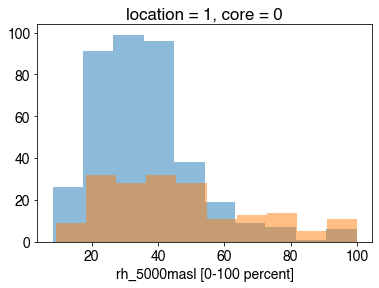

In [97]:
# narrow_RHlfc1500_d4.plot.hist(alpha=0.5)
# wide_RHlfc1500_d4.plot.hist(alpha=0.5)
narrow_RH5km_d4.plot.hist(alpha=0.5)
wide_RH5km_d4.plot.hist(alpha=0.5)

## Make Pandas Data Frame for Correlograms

In [98]:
# Variable names to include in the Pandas Data Frame
names = ['Max 10dBZ ETH', 'Max dBZ', 'Lifetime', 'Max Diameter', 'Max W Diameter', 'Max W Speed',
         'MU LNB', '$\sqrt{2*MUCAPE}$', '$\sqrt{2*(ACBL\ CAPE)}$', '$\sqrt{2*MUCIN}$', 'MU LCL Height', 'MU LFC Height', 
         # 'TCWV', '500 hPa RH', 'ACBL RH', 'ACBL+1.5km RH', 'MU LCL Temp', 
         '850 hPa Qv', '3 km Qv',
         'TCWV', '5km RH', '600 hPa RH', 'ACBL RH', 'ACBL+1.5km RH',
         'ACBL BWD', '0-3 km BWD', '0-6 km BWD']

### Narrow cells

In [99]:
# Create Pandas Data Frames with variables for narrow cells
df_narrow_d2 = pd.DataFrame(columns = names)

df_narrow_d2['Max 10dBZ ETH'] = narrow_maxETH10dbz_d2.data
df_narrow_d2['Max dBZ'] = narrow_maxdbz_d2.data
df_narrow_d2['Lifetime'] = narrow_track_lifetime_d2.data
df_narrow_d2['Max Diameter'] = narrow_maxdiam_d2.data
df_narrow_d2['Max W Diameter'] = narrow_maxWdiam_d2.data
df_narrow_d2['Max W Speed'] = narrow_maxWspeed_d2.data
df_narrow_d2['MU LNB'] = narrow_pELmu_d2.data
df_narrow_d2['$\sqrt{2*MUCAPE}$'] = np.sqrt(2*narrow_pCAPEmu_d2.data)
df_narrow_d2['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*narrow_pCAPEacbl_d2.data)
df_narrow_d2['$\sqrt{2*MUCIN}$'] = np.sqrt(2*narrow_pCINmu_d2.data)
df_narrow_d2['MU LCL Height'] = narrow_LCLz_d2.data
df_narrow_d2['MU LFC Height'] = narrow_pLFCz_d2.data
# df_narrow_d2['MU LCL Temp'] = narrow_LCLt_d2.data
df_narrow_d2['TCWV'] = narrow_PW_d2.data
df_narrow_d2['850 hPa Qv'] = narrow_Q850mb_d2.data
df_narrow_d2['3 km Qv'] = narrow_Q3km_d2.data
df_narrow_d2['5km RH'] = narrow_RH5km_d2.data
# df_narrow_d2['500 hPa RH'] = narrow_RH500mb_d2.data
df_narrow_d2['600 hPa RH'] = narrow_RH600mb_d2.data
df_narrow_d2['ACBL RH'] = narrow_RHacbl_d2.data
df_narrow_d2['ACBL+1.5km RH'] = narrow_RHlfc1500_d2.data
df_narrow_d2['ACBL BWD'] = narrow_BWSacbl_d2.data
df_narrow_d2['0-3 km BWD'] = narrow_BWS03km_d2.data
df_narrow_d2['0-6 km BWD'] = narrow_BWS06km_d2.data

/tmp/ipykernel_2639464/4070271076.py:12: RuntimeWarning: invalid value encountered in sqrt
  df_narrow_d2['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*narrow_pCAPEacbl_d2.data)
/tmp/ipykernel_2639464/4070271076.py:13: RuntimeWarning: invalid value encountered in sqrt
  df_narrow_d2['$\sqrt{2*MUCIN}$'] = np.sqrt(2*narrow_pCINmu_d2.data)


In [100]:
# Create Pandas Data Frames with variables for narrow cells
df_narrow_d3 = pd.DataFrame(columns = names)

df_narrow_d3['Max 10dBZ ETH'] = narrow_maxETH10dbz_d3.data
df_narrow_d3['Max dBZ'] = narrow_maxdbz_d3.data
df_narrow_d3['Lifetime'] = narrow_track_lifetime_d3.data
df_narrow_d3['Max Diameter'] = narrow_maxdiam_d3.data
df_narrow_d3['Max W Diameter'] = narrow_maxWdiam_d3.data
df_narrow_d3['Max W Speed'] = narrow_maxWspeed_d3.data
df_narrow_d3['MU LNB'] = narrow_pELmu_d3.data
df_narrow_d3['$\sqrt{2*MUCAPE}$'] = np.sqrt(2*narrow_pCAPEmu_d3.data)
df_narrow_d3['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*narrow_pCAPEacbl_d3.data)
df_narrow_d3['$\sqrt{2*MUCIN}$'] = np.sqrt(2*narrow_pCINmu_d3.data)
df_narrow_d3['MU LCL Height'] = narrow_LCLz_d3.data
df_narrow_d3['MU LFC Height'] = narrow_pLFCz_d3.data
# df_narrow_d3['MU LCL Temp'] = narrow_LCLt_d3.data
df_narrow_d3['TCWV'] = narrow_PW_d3.data
df_narrow_d3['850 hPa Qv'] = narrow_Q850mb_d3.data
df_narrow_d3['3 km Qv'] = narrow_Q3km_d3.data
df_narrow_d3['5km RH'] = narrow_RH5km_d3.data
# df_narrow_d3['500 hPa RH'] = narrow_RH500mb_d3.data
df_narrow_d3['600 hPa RH'] = narrow_RH600mb_d3.data
df_narrow_d3['ACBL RH'] = narrow_RHacbl_d3.data
df_narrow_d3['ACBL+1.5km RH'] = narrow_RHlfc1500_d3.data
df_narrow_d3['ACBL BWD'] = narrow_BWSacbl_d3.data
df_narrow_d3['0-3 km BWD'] = narrow_BWS03km_d3.data
df_narrow_d3['0-6 km BWD'] = narrow_BWS06km_d3.data

/tmp/ipykernel_2639464/2045352278.py:12: RuntimeWarning: invalid value encountered in sqrt
  df_narrow_d3['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*narrow_pCAPEacbl_d3.data)
/tmp/ipykernel_2639464/2045352278.py:13: RuntimeWarning: invalid value encountered in sqrt
  df_narrow_d3['$\sqrt{2*MUCIN}$'] = np.sqrt(2*narrow_pCINmu_d3.data)


In [101]:
# Create Pandas Data Frames with variables for narrow cells
df_narrow_d4 = pd.DataFrame(columns = names)

df_narrow_d4['Max 10dBZ ETH'] = narrow_maxETH10dbz_d4.data
df_narrow_d4['Max dBZ'] = narrow_maxdbz_d4.data
df_narrow_d4['Lifetime'] = narrow_track_lifetime_d4.data
df_narrow_d4['Max Diameter'] = narrow_maxdiam_d4.data
df_narrow_d4['Max W Diameter'] = narrow_maxWdiam_d4.data
df_narrow_d4['Max W Speed'] = narrow_maxWspeed_d4.data
df_narrow_d4['MU LNB'] = narrow_pELmu_d4.data
df_narrow_d4['$\sqrt{2*MUCAPE}$'] = np.sqrt(2*narrow_pCAPEmu_d4.data)
df_narrow_d4['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*narrow_pCAPEacbl_d4.data)
df_narrow_d4['$\sqrt{2*MUCIN}$'] = np.sqrt(2*narrow_pCINmu_d4.data)
df_narrow_d4['MU LCL Height'] = narrow_LCLz_d4.data
df_narrow_d4['MU LFC Height'] = narrow_pLFCz_d4.data
# df_narrow_d4['MU LCL Temp'] = narrow_LCLt_d4.data
df_narrow_d4['TCWV'] = narrow_PW_d4.data
df_narrow_d4['5km RH'] = narrow_RH5km_d4.data
df_narrow_d4['850 hPa Qv'] = narrow_Q850mb_d4.data
df_narrow_d4['3 km Qv'] = narrow_Q3km_d4.data
# df_narrow_d4['500 hPa RH'] = narrow_RH500mb_d4.data
df_narrow_d4['600 hPa RH'] = narrow_RH600mb_d4.data
df_narrow_d4['ACBL RH'] = narrow_RHacbl_d4.data
df_narrow_d4['ACBL+1.5km RH'] = narrow_RHlfc1500_d4.data
df_narrow_d4['ACBL BWD'] = narrow_BWSacbl_d4.data
df_narrow_d4['0-3 km BWD'] = narrow_BWS03km_d4.data
df_narrow_d4['0-6 km BWD'] = narrow_BWS06km_d4.data

/tmp/ipykernel_2639464/3534946954.py:12: RuntimeWarning: invalid value encountered in sqrt
  df_narrow_d4['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*narrow_pCAPEacbl_d4.data)
/tmp/ipykernel_2639464/3534946954.py:13: RuntimeWarning: invalid value encountered in sqrt
  df_narrow_d4['$\sqrt{2*MUCIN}$'] = np.sqrt(2*narrow_pCINmu_d4.data)


### Wide cells

In [102]:
# Create Pandas Data Frames with variables for wide cells
df_wide_d2 = pd.DataFrame(columns = names)

df_wide_d2['Max 10dBZ ETH'] = wide_maxETH10dbz_d2.data
df_wide_d2['Max dBZ'] = wide_maxdbz_d2.data
df_wide_d2['Lifetime'] = wide_track_lifetime_d2.data
df_wide_d2['Max Diameter'] = wide_maxdiam_d2.data
df_wide_d2['Max W Diameter'] = wide_maxWdiam_d2.data
df_wide_d2['Max W Speed'] = wide_maxWspeed_d2.data
df_wide_d2['MU LNB'] = wide_pELmu_d2.data
df_wide_d2['$\sqrt{2*MUCAPE}$'] = np.sqrt(2*wide_pCAPEmu_d2.data)
df_wide_d2['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*wide_pCAPEacbl_d2.data)
df_wide_d2['$\sqrt{2*MUCIN}$'] = np.sqrt(2*wide_pCINmu_d2.data)
df_wide_d2['MU LCL Height'] = wide_LCLz_d2.data
df_wide_d2['MU LFC Height'] = wide_pLFCz_d2.data
# df_wide_d2['MU LCL Temp'] = wide_LCLt_d2.data
df_wide_d2['TCWV'] = wide_PW_d2.data
df_wide_d2['850 hPa Qv'] = wide_Q850mb_d2.data
df_wide_d2['3 km Qv'] = wide_Q3km_d2.data
df_wide_d2['5km RH'] = wide_RH5km_d2.data
# df_wide_d2['500 hPa RH'] = wide_RH500mb_d2.data
df_wide_d2['600 hPa RH'] = wide_RH600mb_d2.data
df_wide_d2['ACBL RH'] = wide_RHacbl_d2.data
df_wide_d2['ACBL+1.5km RH'] = wide_RHlfc1500_d2.data
df_wide_d2['ACBL BWD'] = wide_BWSacbl_d2.data
df_wide_d2['0-3 km BWD'] = wide_BWS03km_d2.data
df_wide_d2['0-6 km BWD'] = wide_BWS06km_d2.data

/tmp/ipykernel_2639464/2357798079.py:13: RuntimeWarning: invalid value encountered in sqrt
  df_wide_d2['$\sqrt{2*MUCIN}$'] = np.sqrt(2*wide_pCINmu_d2.data)


In [103]:
# Create Pandas Data Frames with variables for wide cells
df_wide_d3 = pd.DataFrame(columns = names)

df_wide_d3['Max 10dBZ ETH'] = wide_maxETH10dbz_d3.data
df_wide_d3['Max dBZ'] = wide_maxdbz_d3.data
df_wide_d3['Lifetime'] = wide_track_lifetime_d3.data
df_wide_d3['Max Diameter'] = wide_maxdiam_d3.data
df_wide_d3['Max W Diameter'] = wide_maxWdiam_d3.data
df_wide_d3['Max W Speed'] = wide_maxWspeed_d3.data
df_wide_d3['MU LNB'] = wide_pELmu_d3.data
df_wide_d3['$\sqrt{2*MUCAPE}$'] = np.sqrt(2*wide_pCAPEmu_d3.data)
df_wide_d3['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*wide_pCAPEacbl_d3.data)
df_wide_d3['$\sqrt{2*MUCIN}$'] = np.sqrt(2*wide_pCINmu_d3.data)
df_wide_d3['MU LCL Height'] = wide_LCLz_d3.data
df_wide_d3['MU LFC Height'] = wide_pLFCz_d3.data
# df_wide_d3['MU LCL Temp'] = wide_LCLt_d3.data
df_wide_d3['TCWV'] = wide_PW_d3.data
df_wide_d3['850 hPa Qv'] = wide_Q850mb_d3.data
df_wide_d3['3 km Qv'] = wide_Q3km_d3.data
df_wide_d3['5km RH'] = wide_RH5km_d3.data
# df_wide_d3['500 hPa RH'] = wide_RH500mb_d3.data
df_wide_d3['600 hPa RH'] = wide_RH600mb_d3.data
df_wide_d3['ACBL RH'] = wide_RHacbl_d3.data
df_wide_d3['ACBL+1.5km RH'] = wide_RHlfc1500_d3.data
df_wide_d3['ACBL BWD'] = wide_BWSacbl_d3.data
df_wide_d3['0-3 km BWD'] = wide_BWS03km_d3.data
df_wide_d3['0-6 km BWD'] = wide_BWS06km_d3.data

/tmp/ipykernel_2639464/663646158.py:12: RuntimeWarning: invalid value encountered in sqrt
  df_wide_d3['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*wide_pCAPEacbl_d3.data)
/tmp/ipykernel_2639464/663646158.py:13: RuntimeWarning: invalid value encountered in sqrt
  df_wide_d3['$\sqrt{2*MUCIN}$'] = np.sqrt(2*wide_pCINmu_d3.data)


In [104]:
# Create Pandas Data Frames with variables for wide cells
df_wide_d4 = pd.DataFrame(columns = names)

df_wide_d4['Max 10dBZ ETH'] = wide_maxETH10dbz_d4.data
df_wide_d4['Max dBZ'] = wide_maxdbz_d4.data
df_wide_d4['Lifetime'] = wide_track_lifetime_d4.data
df_wide_d4['Max Diameter'] = wide_maxdiam_d4.data
df_wide_d4['Max W Diameter'] = wide_maxWdiam_d4.data
df_wide_d4['Max W Speed'] = wide_maxWspeed_d4.data
df_wide_d4['MU LNB'] = wide_pELmu_d4.data
df_wide_d4['$\sqrt{2*MUCAPE}$'] = np.sqrt(2*wide_pCAPEmu_d4.data)
df_wide_d4['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*wide_pCAPEacbl_d4.data)
df_wide_d4['$\sqrt{2*MUCIN}$'] = np.sqrt(2*wide_pCINmu_d4.data)
df_wide_d4['MU LCL Height'] = wide_LCLz_d4.data
df_wide_d4['MU LFC Height'] = wide_pLFCz_d4.data
# df_wide_d4['MU LCL Temp'] = wide_LCLt_d4.data
df_wide_d4['TCWV'] = wide_PW_d4.data
df_wide_d4['850 hPa Qv'] = wide_Q850mb_d4.data
df_wide_d4['3 km Qv'] = wide_Q3km_d4.data
df_wide_d4['5km RH'] = wide_RH5km_d4.data
# df_wide_d4['500 hPa RH'] = wide_RH500mb_d4.data
df_wide_d4['600 hPa RH'] = wide_RH600mb_d4.data
df_wide_d4['ACBL RH'] = wide_RHacbl_d4.data
df_wide_d4['ACBL+1.5km RH'] = wide_RHlfc1500_d4.data
df_wide_d4['ACBL BWD'] = wide_BWSacbl_d4.data
df_wide_d4['0-3 km BWD'] = wide_BWS03km_d4.data
df_wide_d4['0-6 km BWD'] = wide_BWS06km_d4.data

/tmp/ipykernel_2639464/3197491730.py:13: RuntimeWarning: invalid value encountered in sqrt
  df_wide_d4['$\sqrt{2*MUCIN}$'] = np.sqrt(2*wide_pCINmu_d4.data)


In [105]:
# narrow_maxETH10dbz_d2.shape, narrow_maxdbz_d2.shape, narrow_track_lifetime_d2.shape, narrow_maxdiam_d2.shape

In [106]:
# narrow_pELmu_d2.shape, narrow_pCAPEmu_d2.shape, narrow_pCAPEacbl_d2.shape, narrow_pCINmu_d2.shape, narrow_LCLz_d2.shape, narrow_pLFCz_d2.shape, narrow_LCLt_d2.shape

In [107]:
# compute correlations between all pandas data frame variables
corr_df_narrow_pearson_d2 = df_narrow_d2.corr(method='pearson')
corr_df_narrow_spearman_d2 = df_narrow_d2.corr(method='spearman')

corr_df_wide_pearson_d2 = df_wide_d2.corr(method='pearson')
corr_df_wide_spearman_d2 = df_wide_d2.corr(method='spearman')

# Compute significance of correlations
p_df_narrow_spearman_d2 = spearmanr_pvalues(df_narrow_d2)
p_df_narrow_pearson_d2 = pearsonr_pvalues(df_narrow_d2)

p_df_wide_spearman_d2 = spearmanr_pvalues(df_wide_d2)
p_df_wide_pearson_d2 = pearsonr_pvalues(df_wide_d2)

/tmp/ipykernel_2639464/3484320114.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = spearmanr(tmp[r], tmp[c])
/tmp/ipykernel_2639464/1482580035.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = pearsonr(tmp[r][mask], tmp[c][mask])
/tmp/ipykernel_2639464/3484320114.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = spearmanr(tmp[r], tmp[c])
/tmp/ipykernel_2639464/1482580035.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = pearsonr(tmp[r][mask], tmp[c][mask])


In [108]:
#compute correlations between all pandas data frame variables
corr_df_narrow_pearson_d3 = df_narrow_d3.corr(method='pearson')
corr_df_narrow_spearman_d3 = df_narrow_d3.corr(method='spearman')

corr_df_wide_pearson_d3 = df_wide_d3.corr(method='pearson')
corr_df_wide_spearman_d3 = df_wide_d3.corr(method='spearman')

# Compute significance of correlations
p_df_narrow_spearman_d3 = spearmanr_pvalues(df_narrow_d3)
p_df_narrow_pearson_d3 = pearsonr_pvalues(df_narrow_d3)

p_df_wide_spearman_d3 = spearmanr_pvalues(df_wide_d3)
p_df_wide_pearson_d3 = pearsonr_pvalues(df_wide_d3)

/tmp/ipykernel_2639464/3484320114.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = spearmanr(tmp[r], tmp[c])
/tmp/ipykernel_2639464/1482580035.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = pearsonr(tmp[r][mask], tmp[c][mask])
/tmp/ipykernel_2639464/3484320114.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = spearmanr(tmp[r], tmp[c])
/tmp/ipykernel_2639464/1482580035.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = pearsonr(tmp[r][mask], tmp[c][mask])


In [109]:
#compute correlations between all pandas data frame variables
corr_df_narrow_pearson_d4 = df_narrow_d4.corr(method='pearson')
corr_df_narrow_spearman_d4 = df_narrow_d4.corr(method='spearman')

corr_df_wide_pearson_d4 = df_wide_d4.corr(method='pearson')
corr_df_wide_spearman_d4 = df_wide_d4.corr(method='spearman')

# Compute significance of correlations
p_df_narrow_spearman_d4 = spearmanr_pvalues(df_narrow_d4)
p_df_narrow_pearson_d4 = pearsonr_pvalues(df_narrow_d4)

p_df_wide_spearman_d4 = spearmanr_pvalues(df_wide_d4)
p_df_wide_pearson_d4 = pearsonr_pvalues(df_wide_d4)

/tmp/ipykernel_2639464/3484320114.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = spearmanr(tmp[r], tmp[c])
/tmp/ipykernel_2639464/1482580035.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = pearsonr(tmp[r][mask], tmp[c][mask])
/tmp/ipykernel_2639464/3484320114.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = spearmanr(tmp[r], tmp[c])
/tmp/ipykernel_2639464/1482580035.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = pearsonr(tmp[r][mask], tmp[c][mask])


In [110]:
#plot settings
# my_cmap = plt.cm.plasma
# my_cmap.set_under('w',1)
# %matplotlib inline

plt.rcParams.update({'font.size': 14})

import warnings
warnings.filterwarnings('ignore')

## D2 correlogram

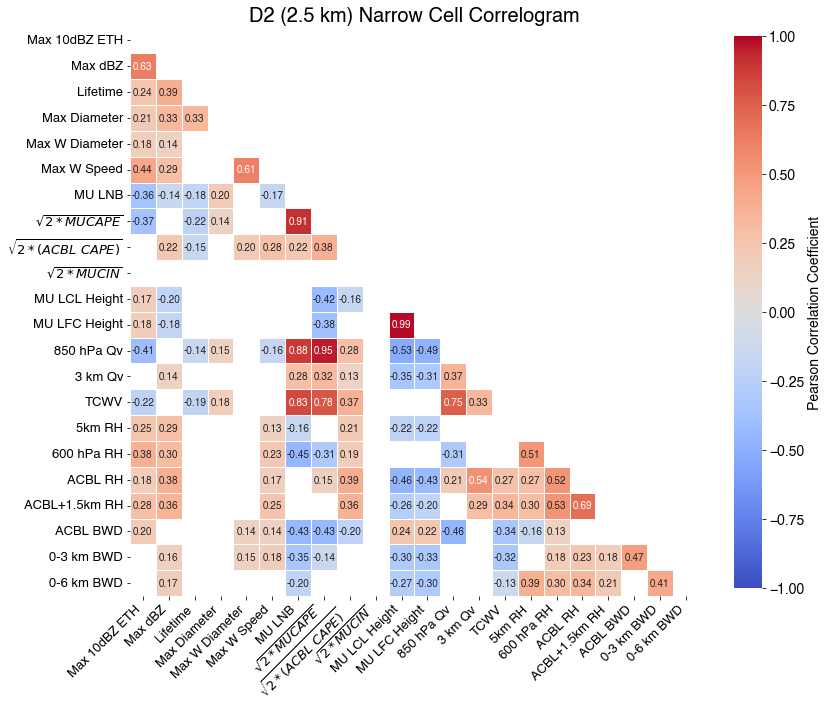

In [111]:
# narrow cell correlogram using reversible ascent parameters/filters
fig, ax = plt.subplots(1,1, figsize=(12,12))
cmap = sns.color_palette("coolwarm", as_cmap=True)
pmask = np.triu(np.ones_like(corr_df_narrow_spearman_d2, dtype=bool), k=0)
# nonsigx, nonsigy = np.where(p_df_narrow_pearson_d2 > 0.05)
# pmask[nonsigx, nonsigy] = True
pmask[p_df_narrow_pearson_d2 > 0.05] = True
sns.heatmap(corr_df_narrow_pearson_d2, 
            mask=pmask, 
            cmap=cmap, 
            vmax=1, 
            vmin=-1,
            center=0,
            square=True, 
            linewidths=.5,
            annot = True,
            fmt='.2f', 
            annot_kws={'size': 10},
            cbar_kws={"shrink": 0.7, "label": 'Pearson Correlation Coefficient'})
plt.xticks(rotation = 45, horizontalalignment = 'right')
ax.tick_params(axis = 'x', labelsize = 13)
ax.tick_params(axis = 'y', labelsize = 13)
ax.set_title('D2 (2.5 km) Narrow Cell Correlogram', fontsize=20)

fig.tight_layout()
figname = f'{figdir}correlogram_narrowcells_pearson_sig_d2.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

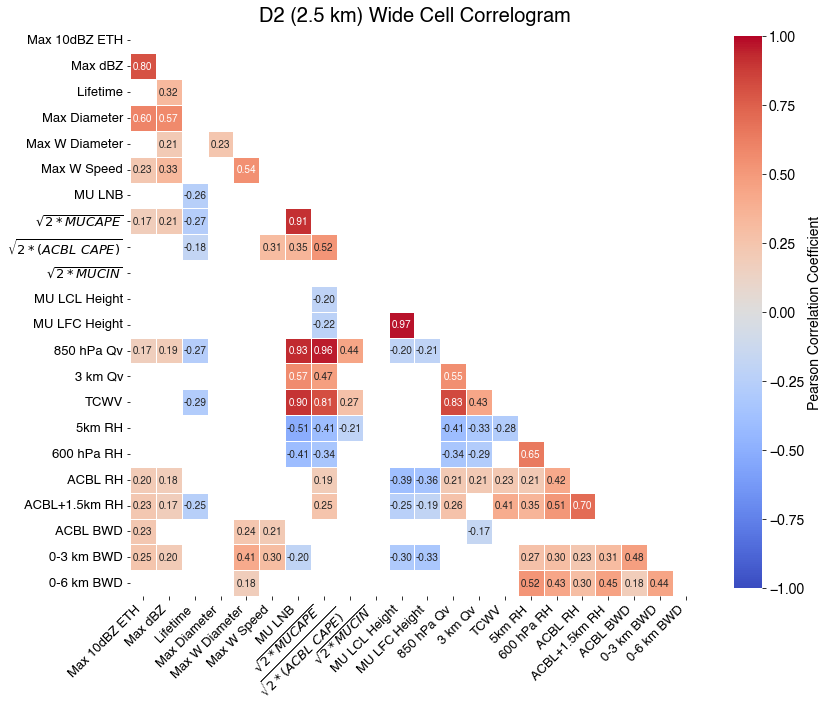

In [112]:
# wide cell correlogram using reversible ascent parameters/filters
fig, ax = plt.subplots(1,1, figsize=(12,12))
cmap = sns.color_palette("coolwarm", as_cmap=True)
pmask = np.triu(np.ones_like(corr_df_wide_spearman_d2, dtype=bool), k=0)
pmask[p_df_wide_pearson_d2 > 0.05] = True
sns.heatmap(corr_df_wide_pearson_d2, 
            mask=pmask, 
            cmap=cmap, 
            vmax=1, 
            vmin=-1,
            center=0,
            square=True, 
            linewidths=.5,
            annot = True,
            fmt='.2f', 
            annot_kws={'size': 10},
            cbar_kws={"shrink": 0.7, "label": 'Pearson Correlation Coefficient'})
plt.xticks(rotation = 45, horizontalalignment = 'right')
ax.tick_params(axis = 'x', labelsize = 13)
ax.tick_params(axis = 'y', labelsize = 13)
ax.set_title('D2 (2.5 km) Wide Cell Correlogram', fontsize=20)

fig.tight_layout()
figname = f'{figdir}correlogram_widecells_pearson_sig_d2.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

## D3 correlogram

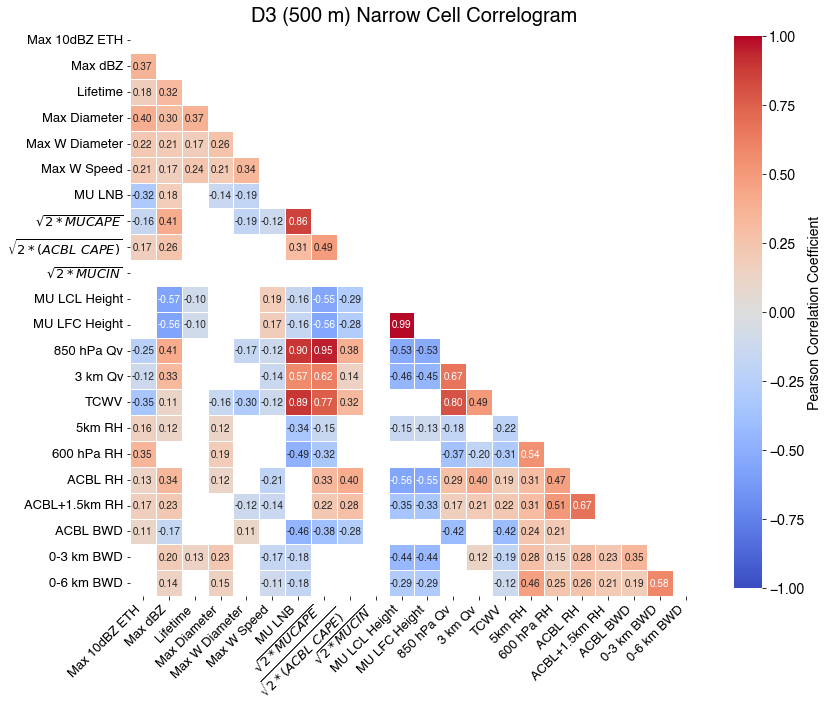

In [113]:
# narrow cell correlogram using reversible ascent parameters/filters
fig, ax = plt.subplots(1,1, figsize=(12,12))
cmap = sns.color_palette("coolwarm", as_cmap=True)
pmask = np.triu(np.ones_like(corr_df_narrow_spearman_d3, dtype=bool), k=0)
# nonsigx, nonsigy = np.where(p_df_narrow_pearson_d3 > 0.05)
# pmask[nonsigx, nonsigy] = True
pmask[p_df_narrow_pearson_d3 > 0.05] = True
sns.heatmap(corr_df_narrow_pearson_d3, 
            mask=pmask, 
            cmap=cmap, 
            vmax=1, 
            vmin=-1,
            center=0,
            square=True, 
            linewidths=.5,
            annot = True,
            fmt='.2f', 
            annot_kws={'size': 10},
            cbar_kws={"shrink": 0.7, "label": 'Pearson Correlation Coefficient'})
plt.xticks(rotation = 45, horizontalalignment = 'right')
ax.tick_params(axis = 'x', labelsize = 13)
ax.tick_params(axis = 'y', labelsize = 13)
ax.set_title('D3 (500 m) Narrow Cell Correlogram', fontsize=20)

fig.tight_layout()
figname = f'{figdir}correlogram_narrowcells_pearson_sig_d3.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

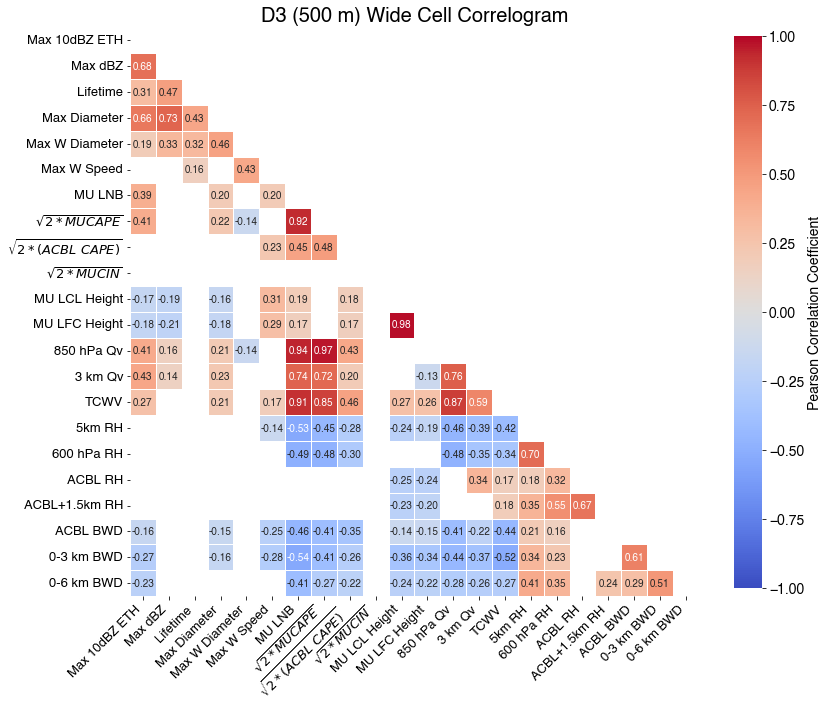

In [114]:
# wide cell correlogram using reversible ascent parameters/filters
fig, ax = plt.subplots(1,1, figsize=(12,12))
cmap = sns.color_palette("coolwarm", as_cmap=True)
pmask = np.triu(np.ones_like(corr_df_wide_spearman_d3, dtype=bool), k=0)
pmask[p_df_wide_pearson_d3 > 0.05] = True
sns.heatmap(corr_df_wide_pearson_d3, 
            mask=pmask, 
            cmap=cmap, 
            vmax=1, 
            vmin=-1,
            center=0,
            square=True, 
            linewidths=.5,
            annot = True,
            fmt='.2f', 
            annot_kws={'size': 10},
            cbar_kws={"shrink": 0.7, "label": 'Pearson Correlation Coefficient'})
plt.xticks(rotation = 45, horizontalalignment = 'right')
ax.tick_params(axis = 'x', labelsize = 13)
ax.tick_params(axis = 'y', labelsize = 13)
ax.set_title('D3 (500 m) Wide Cell Correlogram', fontsize=20)

fig.tight_layout()
figname = f'{figdir}correlogram_widecells_pearson_sig_d3.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

## D4 correlogram

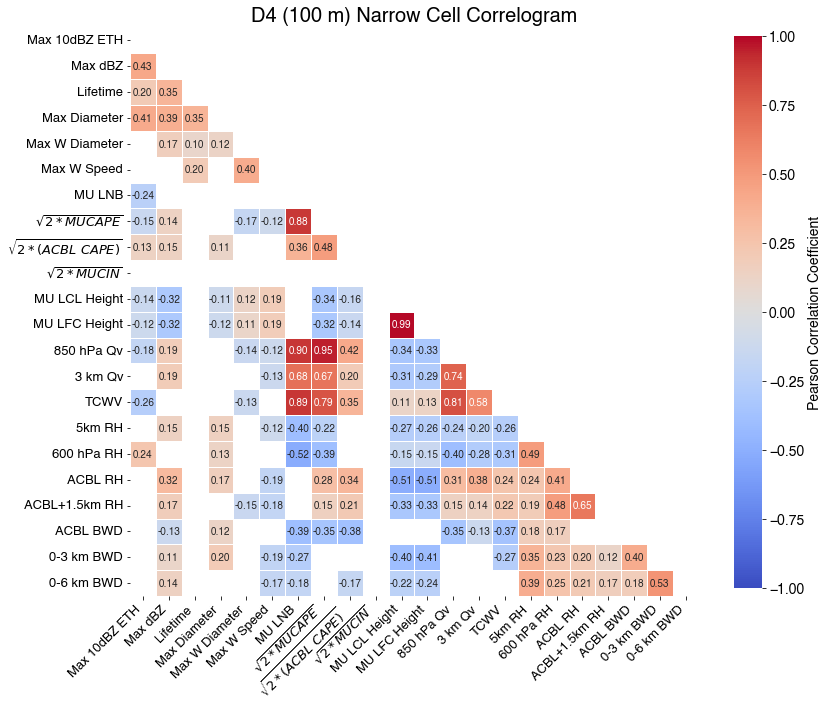

In [115]:
# narrow cell correlogram using reversible ascent parameters/filters
fig, ax = plt.subplots(1,1, figsize=(12,12))
cmap = sns.color_palette("coolwarm", as_cmap=True)
pmask = np.triu(np.ones_like(corr_df_narrow_spearman_d4, dtype=bool), k=0)
pmask[p_df_narrow_pearson_d4 > 0.05] = True
sns.heatmap(corr_df_narrow_pearson_d4, 
            mask=pmask, 
            cmap=cmap, 
            vmax=1, 
            vmin=-1,
            center=0,
            square=True, 
            linewidths=.5,
            annot = True,
            fmt='.2f', 
            annot_kws={'size': 10},
            cbar_kws={"shrink": 0.7, "label": 'Pearson Correlation Coefficient'})
plt.xticks(rotation = 45, horizontalalignment = 'right')
ax.tick_params(axis = 'x', labelsize = 13)
ax.tick_params(axis = 'y', labelsize = 13)
ax.set_title('D4 (100 m) Narrow Cell Correlogram', fontsize=20)

fig.tight_layout()
figname = f'{figdir}correlogram_narrowcells_pearson_sig_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+1h/correlogram_widecells_pearson_sig_d4.png


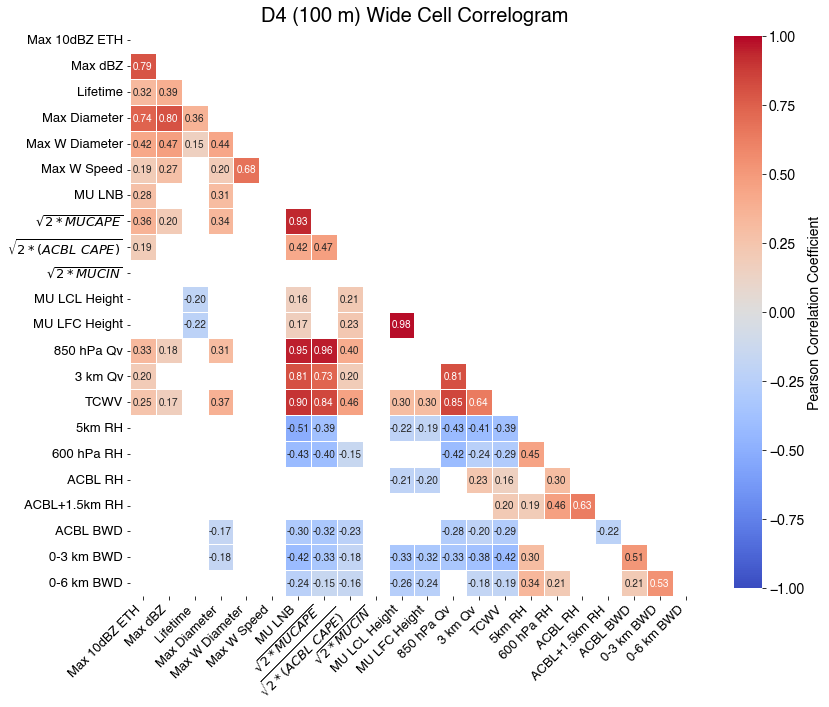

In [116]:
# wide cell correlogram using reversible ascent parameters/filters
fig, ax = plt.subplots(1,1, figsize=(12,12))
cmap = sns.color_palette("coolwarm", as_cmap=True)
pmask = np.triu(np.ones_like(corr_df_wide_spearman_d4, dtype=bool), k=0)
# nonsigx, nonsigy = np.where(p_df_wide_pearson_d4 > 0.05)
pmask[p_df_wide_pearson_d4 > 0.05] = True
sns.heatmap(corr_df_wide_pearson_d4, 
            mask=pmask, 
            cmap=cmap, 
            vmax=1, 
            vmin=-1,
            center=0,
            square=True, 
            linewidths=.5,
            annot = True,
            fmt='.2f', 
            annot_kws={'size': 10},
            cbar_kws={"shrink": 0.7, "label": 'Pearson Correlation Coefficient'})
plt.xticks(rotation = 45, horizontalalignment = 'right')
ax.tick_params(axis = 'x', labelsize = 13)
ax.tick_params(axis = 'y', labelsize = 13)
ax.set_title('D4 (100 m) Wide Cell Correlogram', fontsize=20)

fig.tight_layout()
figname = f'{figdir}correlogram_widecells_pearson_sig_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
print(figname)

## Make Pandas Data Frame for Multi-Linear Regression (MLR)

### Narrow cells

In [117]:
# define new pandas data frames with standardized variables (variables values on a scale of # of standard deviations)
df_narrow_std_d2 = pd.DataFrame(columns = names)
df_narrow_std_d2['Max W Diameter'] = ((narrow_maxWdiam_d2 - np.nanmean(narrow_maxWdiam_d2)) / np.nanstd(narrow_maxWdiam_d2)).data
# df_narrow_std_d2['Max Diameter'] = ((narrow_maxdiam_d2 - np.nanmean(narrow_maxdiam_d2)) / np.nanstd(narrow_maxdiam_d2)).data
df_narrow_std_d2['Max 10dBZ ETH'] = ((narrow_maxETH10dbz_d2 - np.nanmean(narrow_maxETH10dbz_d2)) / np.nanstd(narrow_maxETH10dbz_d2)).data
df_narrow_std_d2['MU LNB'] = ((narrow_pELmu_d2 - np.nanmean(narrow_pELmu_d2)) / np.nanstd(narrow_pELmu_d2)).data
df_narrow_std_d2['$\sqrt{2*MUCAPE}$'] = ((np.sqrt(2*narrow_pCAPEmu_d2) - np.nanmean(np.sqrt(2*narrow_pCAPEmu_d2))) / np.nanstd(np.sqrt(2*narrow_pCAPEmu_d2))).data
df_narrow_std_d2['$\sqrt{2*(ACBL\ CAPE)}$'] = ((np.sqrt(2*narrow_pCAPEacbl_d2) - np.nanmean(np.sqrt(2*narrow_pCAPEacbl_d2))) / np.nanstd(np.sqrt(2*narrow_pCAPEacbl_d2))).data
# df_narrow_std_d2['$\sqrt{2*MUCIN}$'] = ((np.sqrt(2*narrow_pCINmu_d2) - np.nanmean(np.sqrt(2*narrow_pCINmu_d2))) / np.nanstd(np.sqrt(2*narrow_pCINmu_d2))).data
df_narrow_std_d2['MU LCL Height'] = ((narrow_LCLz_d2 - np.nanmean(narrow_LCLz_d2)) / np.nanstd(narrow_LCLz_d2)).data
df_narrow_std_d2['MU LFC Height'] = ((narrow_pLFCz_d2 - np.nanmean(narrow_pLFCz_d2)) / np.nanstd(narrow_pLFCz_d2)).data
df_narrow_std_d2['MU LCL Temp'] = ((narrow_LCLt_d2 - np.nanmean(narrow_LCLt_d2)) / np.nanstd(narrow_LCLt_d2)).data
df_narrow_std_d2['TCWV'] = ((narrow_PW_d2 - np.nanmean(narrow_PW_d2)) / np.nanstd(narrow_PW_d2)).data
df_narrow_std_d2['850 hPa Qv'] = ((narrow_Q850mb_d2 - np.nanmean(narrow_Q850mb_d2)) / np.nanstd(narrow_Q850mb_d2)).data
df_narrow_std_d2['3km Qv'] = ((narrow_Q3km_d2 - np.nanmean(narrow_Q3km_d2)) / np.nanstd(narrow_Q3km_d2)).data
df_narrow_std_d2['5km RH'] = ((narrow_RH5km_d2 - np.nanmean(narrow_RH5km_d2)) / np.nanstd(narrow_RH5km_d2)).data
df_narrow_std_d2['600 hPa RH'] = ((narrow_RH600mb_d2 - np.nanmean(narrow_RH600mb_d2)) / np.nanstd(narrow_RH600mb_d2)).data
# df_narrow_std_d2['500 hPa RH'] = ((narrow_RH500mb_d2 - np.nanmean(narrow_RH500mb_d2)) / np.nanstd(narrow_RH500mb_d2)).data
# df_narrow_std_d2['ACBL RH'] = ((narrow_RHacbl_d2 - np.nanmean(narrow_RHacbl_d2)) / np.nanstd(narrow_RHacbl_d2)).data
df_narrow_std_d2['ACBL+1.5km RH'] = ((narrow_RHlfc1500_d2 - np.nanmean(narrow_RHlfc1500_d2)) / np.nanstd(narrow_RHlfc1500_d2)).data
df_narrow_std_d2['ACBL BWD'] = ((narrow_BWSacbl_d2 - np.nanmean(narrow_BWSacbl_d2)) / np.nanstd(narrow_BWSacbl_d2)).data
df_narrow_std_d2['0-3 km BWD'] = ((narrow_BWS03km_d2 - np.nanmean(narrow_BWS03km_d2)) / np.nanstd(narrow_BWS03km_d2)).data
df_narrow_std_d2['0-6 km BWD'] = ((narrow_BWS06km_d2 - np.nanmean(narrow_BWS06km_d2)) / np.nanstd(narrow_BWS06km_d2)).data

In [118]:
# define new pandas data frames with standardized variables (variables values on a scale of # of standard deviations)
df_narrow_std_d3 = pd.DataFrame(columns = names)
df_narrow_std_d3['Max W Diameter'] = ((narrow_maxWdiam_d3 - np.nanmean(narrow_maxWdiam_d3)) / np.nanstd(narrow_maxWdiam_d3)).data
# df_narrow_std_d3['Max Diameter'] = ((narrow_maxdiam_d3 - np.nanmean(narrow_maxdiam_d3)) / np.nanstd(narrow_maxdiam_d3)).data
df_narrow_std_d3['Max 10dBZ ETH'] = ((narrow_maxETH10dbz_d3 - np.nanmean(narrow_maxETH10dbz_d3)) / np.nanstd(narrow_maxETH10dbz_d3)).data
df_narrow_std_d3['MU LNB'] = ((narrow_pELmu_d3 - np.nanmean(narrow_pELmu_d3)) / np.nanstd(narrow_pELmu_d3)).data
df_narrow_std_d3['$\sqrt{2*MUCAPE}$'] = ((np.sqrt(2*narrow_pCAPEmu_d3) - np.nanmean(np.sqrt(2*narrow_pCAPEmu_d3))) / np.nanstd(np.sqrt(2*narrow_pCAPEmu_d3))).data
df_narrow_std_d3['$\sqrt{2*(ACBL\ CAPE)}$'] = ((np.sqrt(2*narrow_pCAPEacbl_d3) - np.nanmean(np.sqrt(2*narrow_pCAPEacbl_d3))) / np.nanstd(np.sqrt(2*narrow_pCAPEacbl_d3))).data
# df_narrow_std_d3['$\sqrt{2*MUCIN}$'] = ((np.sqrt(2*narrow_pCINmu_d3) - np.nanmean(np.sqrt(2*narrow_pCINmu_d3))) / np.nanstd(np.sqrt(2*narrow_pCINmu_d3))).data
df_narrow_std_d3['MU LCL Height'] = ((narrow_LCLz_d3 - np.nanmean(narrow_LCLz_d3)) / np.nanstd(narrow_LCLz_d3)).data
df_narrow_std_d3['MU LFC Height'] = ((narrow_pLFCz_d3 - np.nanmean(narrow_pLFCz_d3)) / np.nanstd(narrow_pLFCz_d3)).data
df_narrow_std_d3['MU LCL Temp'] = ((narrow_LCLt_d3 - np.nanmean(narrow_LCLt_d3)) / np.nanstd(narrow_LCLt_d3)).data
df_narrow_std_d3['TCWV'] = ((narrow_PW_d3 - np.nanmean(narrow_PW_d3)) / np.nanstd(narrow_PW_d3)).data
df_narrow_std_d3['850 hPa Qv'] = ((narrow_Q850mb_d3 - np.nanmean(narrow_Q850mb_d3)) / np.nanstd(narrow_Q850mb_d3)).data
df_narrow_std_d3['3km Qv'] = ((narrow_Q3km_d3 - np.nanmean(narrow_Q3km_d3)) / np.nanstd(narrow_Q3km_d3)).data
df_narrow_std_d3['5km RH'] = ((narrow_RH5km_d3 - np.nanmean(narrow_RH5km_d3)) / np.nanstd(narrow_RH5km_d3)).data
df_narrow_std_d3['600 hPa RH'] = ((narrow_RH600mb_d3 - np.nanmean(narrow_RH600mb_d3)) / np.nanstd(narrow_RH600mb_d3)).data
# df_narrow_std_d3['500 hPa RH'] = ((narrow_RH500mb_d3 - np.nanmean(narrow_RH500mb_d3)) / np.nanstd(narrow_RH500mb_d3)).data
# df_narrow_std_d3['ACBL RH'] = ((narrow_RHacbl_d3 - np.nanmean(narrow_RHacbl_d3)) / np.nanstd(narrow_RHacbl_d3)).data
df_narrow_std_d3['ACBL+1.5km RH'] = ((narrow_RHlfc1500_d3 - np.nanmean(narrow_RHlfc1500_d3)) / np.nanstd(narrow_RHlfc1500_d3)).data
df_narrow_std_d3['ACBL BWD'] = ((narrow_BWSacbl_d3 - np.nanmean(narrow_BWSacbl_d3)) / np.nanstd(narrow_BWSacbl_d3)).data
df_narrow_std_d3['0-3 km BWD'] = ((narrow_BWS03km_d3 - np.nanmean(narrow_BWS03km_d3)) / np.nanstd(narrow_BWS03km_d3)).data
df_narrow_std_d3['0-6 km BWD'] = ((narrow_BWS06km_d3 - np.nanmean(narrow_BWS06km_d3)) / np.nanstd(narrow_BWS06km_d3)).data

In [119]:
# define new pandas data frames with standardized variables (variables values on a scale of # of standard deviations)
df_narrow_std_d4 = pd.DataFrame(columns = names)
df_narrow_std_d4['Max W Diameter'] = ((narrow_maxWdiam_d4 - np.nanmean(narrow_maxWdiam_d4)) / np.nanstd(narrow_maxWdiam_d4)).data
# df_narrow_std_d4['Max Diameter'] = ((narrow_maxdiam_d4 - np.nanmean(narrow_maxdiam_d4)) / np.nanstd(narrow_maxdiam_d4)).data
df_narrow_std_d4['Max 10dBZ ETH'] = ((narrow_maxETH10dbz_d4 - np.nanmean(narrow_maxETH10dbz_d4)) / np.nanstd(narrow_maxETH10dbz_d4)).data
df_narrow_std_d4['MU LNB'] = ((narrow_pELmu_d4 - np.nanmean(narrow_pELmu_d4)) / np.nanstd(narrow_pELmu_d4)).data
df_narrow_std_d4['$\sqrt{2*MUCAPE}$'] = ((np.sqrt(2*narrow_pCAPEmu_d4) - np.nanmean(np.sqrt(2*narrow_pCAPEmu_d4))) / np.nanstd(np.sqrt(2*narrow_pCAPEmu_d4))).data
df_narrow_std_d4['$\sqrt{2*(ACBL\ CAPE)}$'] = ((np.sqrt(2*narrow_pCAPEacbl_d4) - np.nanmean(np.sqrt(2*narrow_pCAPEacbl_d4))) / np.nanstd(np.sqrt(2*narrow_pCAPEacbl_d4))).data
# df_narrow_std_d4['$\sqrt{2*MUCIN}$'] = ((np.sqrt(2*narrow_pCINmu_d4) - np.nanmean(np.sqrt(2*narrow_pCINmu_d4))) / np.nanstd(np.sqrt(2*narrow_pCINmu_d4))).data
df_narrow_std_d4['MU LCL Height'] = ((narrow_LCLz_d4 - np.nanmean(narrow_LCLz_d4)) / np.nanstd(narrow_LCLz_d4)).data
df_narrow_std_d4['MU LFC Height'] = ((narrow_pLFCz_d4 - np.nanmean(narrow_pLFCz_d4)) / np.nanstd(narrow_pLFCz_d4)).data
df_narrow_std_d4['MU LCL Temp'] = ((narrow_LCLt_d4 - np.nanmean(narrow_LCLt_d4)) / np.nanstd(narrow_LCLt_d4)).data
df_narrow_std_d4['TCWV'] = ((narrow_PW_d4 - np.nanmean(narrow_PW_d4)) / np.nanstd(narrow_PW_d4)).data
df_narrow_std_d4['850 hPa Qv'] = ((narrow_Q850mb_d4 - np.nanmean(narrow_Q850mb_d4)) / np.nanstd(narrow_Q850mb_d4)).data
df_narrow_std_d4['3km Qv'] = ((narrow_Q3km_d4 - np.nanmean(narrow_Q3km_d4)) / np.nanstd(narrow_Q3km_d4)).data
df_narrow_std_d4['5km RH'] = ((narrow_RH5km_d4 - np.nanmean(narrow_RH5km_d4)) / np.nanstd(narrow_RH5km_d4)).data
df_narrow_std_d4['600 hPa RH'] = ((narrow_RH600mb_d4 - np.nanmean(narrow_RH600mb_d4)) / np.nanstd(narrow_RH600mb_d4)).data
# df_narrow_std_d4['500 hPa RH'] = ((narrow_RH500mb_d4 - np.nanmean(narrow_RH500mb_d4)) / np.nanstd(narrow_RH500mb_d4)).data
# df_narrow_std_d4['ACBL RH'] = ((narrow_RHacbl_d4 - np.nanmean(narrow_RHacbl_d4)) / np.nanstd(narrow_RHacbl_d4)).data
df_narrow_std_d4['ACBL+1.5km RH'] = ((narrow_RHlfc1500_d4 - np.nanmean(narrow_RHlfc1500_d4)) / np.nanstd(narrow_RHlfc1500_d4)).data
df_narrow_std_d4['ACBL BWD'] = ((narrow_BWSacbl_d4 - np.nanmean(narrow_BWSacbl_d4)) / np.nanstd(narrow_BWSacbl_d4)).data
df_narrow_std_d4['0-3 km BWD'] = ((narrow_BWS03km_d4 - np.nanmean(narrow_BWS03km_d4)) / np.nanstd(narrow_BWS03km_d4)).data
df_narrow_std_d4['0-6 km BWD'] = ((narrow_BWS06km_d4 - np.nanmean(narrow_BWS06km_d4)) / np.nanstd(narrow_BWS06km_d4)).data

### Wide cells

In [120]:
# define new pandas data frames with standardized variables (variables values on a scale of # of standard deviations)
df_wide_std_d2 = pd.DataFrame(columns = names)
df_wide_std_d2['Max W Diameter'] = ((wide_maxWdiam_d2 - np.nanmean(wide_maxWdiam_d2)) / np.nanstd(wide_maxWdiam_d2)).data
# df_wide_std_d2['Max Diameter'] = ((wide_maxdiam_d2 - np.nanmean(wide_maxdiam_d2)) / np.nanstd(wide_maxdiam_d2)).data
df_wide_std_d2['Max 10dBZ ETH'] = ((wide_maxETH10dbz_d2 - np.nanmean(wide_maxETH10dbz_d2)) / np.nanstd(wide_maxETH10dbz_d2)).data
df_wide_std_d2['MU LNB'] = ((wide_pELmu_d2 - np.nanmean(wide_pELmu_d2)) / np.nanstd(wide_pELmu_d2)).data
df_wide_std_d2['$\sqrt{2*MUCAPE}$'] = ((np.sqrt(2*wide_pCAPEmu_d2) - np.nanmean(np.sqrt(2*wide_pCAPEmu_d2))) / np.nanstd(np.sqrt(2*wide_pCAPEmu_d2))).data
df_wide_std_d2['$\sqrt{2*(ACBL\ CAPE)}$'] = ((np.sqrt(2*wide_pCAPEacbl_d2) - np.nanmean(np.sqrt(2*wide_pCAPEacbl_d2))) / np.nanstd(np.sqrt(2*wide_pCAPEacbl_d2))).data
# df_wide_std_d2['$\sqrt{2*MUCIN}$'] = ((np.sqrt(2*wide_pCINmu_d2) - np.nanmean(np.sqrt(2*wide_pCINmu_d2))) / np.nanstd(np.sqrt(2*wide_pCINmu_d2))).data
df_wide_std_d2['MU LCL Height'] = ((wide_LCLz_d2 - np.nanmean(wide_LCLz_d2)) / np.nanstd(wide_LCLz_d2)).data
df_wide_std_d2['MU LFC Height'] = ((wide_pLFCz_d2 - np.nanmean(wide_pLFCz_d2)) / np.nanstd(wide_pLFCz_d2)).data
df_wide_std_d2['MU LCL Temp'] = ((wide_LCLt_d2 - np.nanmean(wide_LCLt_d2)) / np.nanstd(wide_LCLt_d2)).data
df_wide_std_d2['TCWV'] = ((wide_PW_d2 - np.nanmean(wide_PW_d2)) / np.nanstd(wide_PW_d2)).data
df_wide_std_d2['850 hPa Qv'] = ((wide_Q850mb_d2 - np.nanmean(wide_Q850mb_d2)) / np.nanstd(wide_Q850mb_d2)).data
df_wide_std_d2['3km Qv'] = ((wide_Q3km_d2 - np.nanmean(wide_Q3km_d2)) / np.nanstd(wide_Q3km_d2)).data
df_wide_std_d2['5km RH'] = ((wide_RH5km_d2 - np.nanmean(wide_RH5km_d2)) / np.nanstd(wide_RH5km_d2)).data
df_wide_std_d2['600 hPa RH'] = ((wide_RH600mb_d2 - np.nanmean(wide_RH600mb_d2)) / np.nanstd(wide_RH600mb_d2)).data
# df_wide_std_d2['500 hPa RH'] = ((wide_RH500mb_d2 - np.nanmean(wide_RH500mb_d2)) / np.nanstd(wide_RH500mb_d2)).data
# df_wide_std_d2['ACBL RH'] = ((wide_RHacbl_d2 - np.nanmean(wide_RHacbl_d2)) / np.nanstd(wide_RHacbl_d2)).data
df_wide_std_d2['ACBL+1.5km RH'] = ((wide_RHlfc1500_d2 - np.nanmean(wide_RHlfc1500_d2)) / np.nanstd(wide_RHlfc1500_d2)).data
df_wide_std_d2['ACBL BWD'] = ((wide_BWSacbl_d2 - np.nanmean(wide_BWSacbl_d2)) / np.nanstd(wide_BWSacbl_d2)).data
df_wide_std_d2['0-3 km BWD'] = ((wide_BWS03km_d2 - np.nanmean(wide_BWS03km_d2)) / np.nanstd(wide_BWS03km_d2)).data
df_wide_std_d2['0-6 km BWD'] = ((wide_BWS06km_d2 - np.nanmean(wide_BWS06km_d2)) / np.nanstd(wide_BWS06km_d2)).data

In [121]:
# define new pandas data frames with standardized variables (variables values on a scale of # of standard deviations)
df_wide_std_d3 = pd.DataFrame(columns = names)
df_wide_std_d3['Max W Diameter'] = ((wide_maxWdiam_d3 - np.nanmean(wide_maxWdiam_d3)) / np.nanstd(wide_maxWdiam_d3)).data
# df_wide_std_d3['Max Diameter'] = ((wide_maxdiam_d3 - np.nanmean(wide_maxdiam_d3)) / np.nanstd(wide_maxdiam_d3)).data
df_wide_std_d3['Max 10dBZ ETH'] = ((wide_maxETH10dbz_d3 - np.nanmean(wide_maxETH10dbz_d3)) / np.nanstd(wide_maxETH10dbz_d3)).data
df_wide_std_d3['MU LNB'] = ((wide_pELmu_d3 - np.nanmean(wide_pELmu_d3)) / np.nanstd(wide_pELmu_d3)).data
df_wide_std_d3['$\sqrt{2*MUCAPE}$'] = ((np.sqrt(2*wide_pCAPEmu_d3) - np.nanmean(np.sqrt(2*wide_pCAPEmu_d3))) / np.nanstd(np.sqrt(2*wide_pCAPEmu_d3))).data
df_wide_std_d3['$\sqrt{2*(ACBL\ CAPE)}$'] = ((np.sqrt(2*wide_pCAPEacbl_d3) - np.nanmean(np.sqrt(2*wide_pCAPEacbl_d3))) / np.nanstd(np.sqrt(2*wide_pCAPEacbl_d3))).data
# df_wide_std_d3['$\sqrt{2*MUCIN}$'] = ((np.sqrt(2*wide_pCINmu_d3) - np.nanmean(np.sqrt(2*wide_pCINmu_d3))) / np.nanstd(np.sqrt(2*wide_pCINmu_d3))).data
df_wide_std_d3['MU LCL Height'] = ((wide_LCLz_d3 - np.nanmean(wide_LCLz_d3)) / np.nanstd(wide_LCLz_d3)).data
df_wide_std_d3['MU LFC Height'] = ((wide_pLFCz_d3 - np.nanmean(wide_pLFCz_d3)) / np.nanstd(wide_pLFCz_d3)).data
df_wide_std_d3['MU LCL Temp'] = ((wide_LCLt_d3 - np.nanmean(wide_LCLt_d3)) / np.nanstd(wide_LCLt_d3)).data
df_wide_std_d3['TCWV'] = ((wide_PW_d3 - np.nanmean(wide_PW_d3)) / np.nanstd(wide_PW_d3)).data
df_wide_std_d3['850 hPa Qv'] = ((wide_Q850mb_d3 - np.nanmean(wide_Q850mb_d3)) / np.nanstd(wide_Q850mb_d3)).data
df_wide_std_d3['3km Qv'] = ((wide_Q3km_d3 - np.nanmean(wide_Q3km_d3)) / np.nanstd(wide_Q3km_d3)).data
df_wide_std_d3['5km RH'] = ((wide_RH5km_d3 - np.nanmean(wide_RH5km_d3)) / np.nanstd(wide_RH5km_d3)).data
df_wide_std_d3['600 hPa RH'] = ((wide_RH600mb_d3 - np.nanmean(wide_RH600mb_d3)) / np.nanstd(wide_RH600mb_d3)).data
# df_wide_std_d3['500 hPa RH'] = ((wide_RH500mb_d3 - np.nanmean(wide_RH500mb_d3)) / np.nanstd(wide_RH500mb_d3)).data
# df_wide_std_d3['ACBL RH'] = ((wide_RHacbl_d3 - np.nanmean(wide_RHacbl_d3)) / np.nanstd(wide_RHacbl_d3)).data
df_wide_std_d3['ACBL+1.5km RH'] = ((wide_RHlfc1500_d3 - np.nanmean(wide_RHlfc1500_d3)) / np.nanstd(wide_RHlfc1500_d3)).data
df_wide_std_d3['ACBL BWD'] = ((wide_BWSacbl_d3 - np.nanmean(wide_BWSacbl_d3)) / np.nanstd(wide_BWSacbl_d3)).data
df_wide_std_d3['0-3 km BWD'] = ((wide_BWS03km_d3 - np.nanmean(wide_BWS03km_d3)) / np.nanstd(wide_BWS03km_d3)).data
df_wide_std_d3['0-6 km BWD'] = ((wide_BWS06km_d3 - np.nanmean(wide_BWS06km_d3)) / np.nanstd(wide_BWS06km_d3)).data

In [122]:
# define new pandas data frames with standardized variables (variables values on a scale of # of standard deviations)
df_wide_std_d4 = pd.DataFrame(columns = names)
df_wide_std_d4['Max W Diameter'] = ((wide_maxWdiam_d4 - np.nanmean(wide_maxWdiam_d4)) / np.nanstd(wide_maxWdiam_d4)).data
# df_wide_std_d4['Max Diameter'] = ((wide_maxdiam_d4 - np.nanmean(wide_maxdiam_d4)) / np.nanstd(wide_maxdiam_d4)).data
df_wide_std_d4['Max 10dBZ ETH'] = ((wide_maxETH10dbz_d4 - np.nanmean(wide_maxETH10dbz_d4)) / np.nanstd(wide_maxETH10dbz_d4)).data
df_wide_std_d4['MU LNB'] = ((wide_pELmu_d4 - np.nanmean(wide_pELmu_d4)) / np.nanstd(wide_pELmu_d4)).data
df_wide_std_d4['$\sqrt{2*MUCAPE}$'] = ((np.sqrt(2*wide_pCAPEmu_d4) - np.nanmean(np.sqrt(2*wide_pCAPEmu_d4))) / np.nanstd(np.sqrt(2*wide_pCAPEmu_d4))).data
df_wide_std_d4['$\sqrt{2*(ACBL\ CAPE)}$'] = ((np.sqrt(2*wide_pCAPEacbl_d4) - np.nanmean(np.sqrt(2*wide_pCAPEacbl_d4))) / np.nanstd(np.sqrt(2*wide_pCAPEacbl_d4))).data
# df_wide_std_d4['$\sqrt{2*MUCIN}$'] = ((np.sqrt(2*wide_pCINmu_d4) - np.nanmean(np.sqrt(2*wide_pCINmu_d4))) / np.nanstd(np.sqrt(2*wide_pCINmu_d4))).data
df_wide_std_d4['MU LCL Height'] = ((wide_LCLz_d4 - np.nanmean(wide_LCLz_d4)) / np.nanstd(wide_LCLz_d4)).data
df_wide_std_d4['MU LFC Height'] = ((wide_pLFCz_d4 - np.nanmean(wide_pLFCz_d4)) / np.nanstd(wide_pLFCz_d4)).data
df_wide_std_d4['MU LCL Temp'] = ((wide_LCLt_d4 - np.nanmean(wide_LCLt_d4)) / np.nanstd(wide_LCLt_d4)).data
df_wide_std_d4['TCWV'] = ((wide_PW_d4 - np.nanmean(wide_PW_d4)) / np.nanstd(wide_PW_d4)).data
df_wide_std_d4['850 hPa Qv'] = ((wide_Q850mb_d4 - np.nanmean(wide_Q850mb_d4)) / np.nanstd(wide_Q850mb_d4)).data
df_wide_std_d4['3km Qv'] = ((wide_Q3km_d4 - np.nanmean(wide_Q3km_d4)) / np.nanstd(wide_Q3km_d4)).data
df_wide_std_d4['5km RH'] = ((wide_RH5km_d4 - np.nanmean(wide_RH5km_d4)) / np.nanstd(wide_RH5km_d4)).data
df_wide_std_d4['600 hPa RH'] = ((wide_RH600mb_d4 - np.nanmean(wide_RH600mb_d4)) / np.nanstd(wide_RH600mb_d4)).data
# df_wide_std_d4['500 hPa RH'] = ((wide_RH500mb_d4 - np.nanmean(wide_RH500mb_d4)) / np.nanstd(wide_RH500mb_d4)).data
# df_wide_std_d4['ACBL RH'] = ((wide_RHacbl_d4 - np.nanmean(wide_RHacbl_d4)) / np.nanstd(wide_RHacbl_d4)).data
df_wide_std_d4['ACBL+1.5km RH'] = ((wide_RHlfc1500_d4 - np.nanmean(wide_RHlfc1500_d4)) / np.nanstd(wide_RHlfc1500_d4)).data
df_wide_std_d4['ACBL BWD'] = ((wide_BWSacbl_d4 - np.nanmean(wide_BWSacbl_d4)) / np.nanstd(wide_BWSacbl_d4)).data
df_wide_std_d4['0-3 km BWD'] = ((wide_BWS03km_d4 - np.nanmean(wide_BWS03km_d4)) / np.nanstd(wide_BWS03km_d4)).data
df_wide_std_d4['0-6 km BWD'] = ((wide_BWS06km_d4 - np.nanmean(wide_BWS06km_d4)) / np.nanstd(wide_BWS06km_d4)).data

(array([ 8., 29., 24., 25., 22.,  7., 10.,  4.,  5.,  3.]),
 array([-1.6410944 , -1.1872575 , -0.73342055, -0.27958363,  0.17425331,
         0.62809026,  1.0819272 ,  1.5357641 ,  1.9896011 ,  2.443438  ,
         2.897275  ], dtype=float32),
 <BarContainer object of 10 artists>)

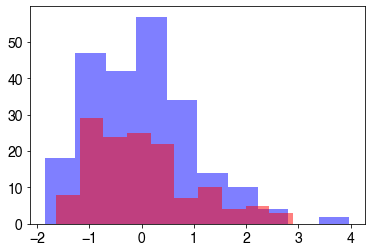

In [123]:
# ((narrow_maxdiam_d2 - np.nanmean(narrow_maxdiam_d2)) / np.nanstd(narrow_maxdiam_d2)).data
# plt.hist(df_narrow_std_d2['Max 10dBZ ETH'].values)
# plt.hist(df_narrow_std_d2['500 hPa RH'].values, color='b', alpha=0.5)
# plt.hist(df_wide_std_d2['500 hPa RH'].values, color='r', alpha=0.5)
plt.hist(df_narrow_std_d2['5km RH'].values, color='b', alpha=0.5)
plt.hist(df_wide_std_d2['5km RH'].values, color='r', alpha=0.5)

# Calculate multivariate linear regression

## Prediction including using cell updraft diameter

### Narrow cells

In [124]:
names

['Max 10dBZ ETH',
 'Max dBZ',
 'Lifetime',
 'Max Diameter',
 'Max W Diameter',
 'Max W Speed',
 'MU LNB',
 '$\\sqrt{2*MUCAPE}$',
 '$\\sqrt{2*(ACBL\\ CAPE)}$',
 '$\\sqrt{2*MUCIN}$',
 'MU LCL Height',
 'MU LFC Height',
 '850 hPa Qv',
 '3 km Qv',
 'TCWV',
 '5km RH',
 '600 hPa RH',
 'ACBL RH',
 'ACBL+1.5km RH',
 'ACBL BWD',
 '0-3 km BWD',
 '0-6 km BWD']

In [125]:
# Multivariate linear regression using reduced set of predictors including max diameter for narrow cells
# predictors_all = ['Max Diameter', 'MU LNB', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', '500 hPa RH', '0-6 km BWD']
# predictors_all = ['Max W Diameter', 'MU LNB', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', 'MU LFC Height', 'TCWV', '5km RH', 'ACBL+1.5km RH', '0-6 km BWD']
# predictors_all = ['Max W Diameter', 'MU LNB', '$\sqrt{2*MUCAPE}$', '$\\sqrt{2*(ACBL\\ CAPE)}$', 'MU LCL Height', 'MU LFC Height', 'TCWV', '850 hPa Qv', '5km RH', 'ACBL+1.5km RH', '0-6 km BWD']
# predictors_all = ['Max W Diameter', 'MU LNB', '$\sqrt{2*MUCAPE}$', '$\\sqrt{2*(ACBL\\ CAPE)}$', 'MU LCL Height', 'MU LFC Height', '850 hPa Qv', '600 hPa RH', 'ACBL+1.5km RH', '0-6 km BWD']
predictors_all = ['Max W Diameter', 'MU LNB', '$\sqrt{2*MUCAPE}$', '$\\sqrt{2*(ACBL\\ CAPE)}$', 'MU LCL Height', '600 hPa RH', 'ACBL+1.5km RH', '0-6 km BWD']
X = df_narrow_std_d2[predictors_all].to_numpy()
Y = df_narrow_std_d2['Max 10dBZ ETH'].to_numpy()

lm_narrow_std_all_eth_d2 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
# #lm_narrow_std_all_eth = pg.linear_regression(X, Y, remove_na=True, weights=weights).round(3)
lm_narrow_std_all_eth_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.007,0.058,0.117,0.907,0.295,0.269,-0.107,0.121,NaN,NaN
1,x1,0.121,0.060,2.006,0.046,0.295,0.269,0.002,0.240,0.021,6.949
2,x2,0.315,0.217,1.451,0.148,0.295,0.269,-0.113,0.742,0.051,17.351
3,x3,-0.673,0.244,-2.758,0.006,0.295,0.269,-1.154,-0.192,0.073,24.901
4,x4,0.137,0.075,1.824,0.069,0.295,0.269,-0.011,0.286,0.015,5.004
5,x5,0.019,0.095,0.201,0.841,0.295,0.269,-0.167,0.205,0.019,6.324
6,x6,0.143,0.080,1.791,0.075,0.295,0.269,-0.014,0.300,0.058,19.795
7,x7,0.236,0.074,3.203,0.002,0.295,0.269,0.091,0.381,0.055,18.546
8,x8,0.031,0.064,0.478,0.633,0.295,0.269,-0.096,0.157,0.003,1.130


In [126]:
# Multivariate linear regression using reduced set of predictors including max diameter for narrow cells
X = df_narrow_std_d3[predictors_all].to_numpy()
Y = df_narrow_std_d3['Max 10dBZ ETH'].to_numpy()

lm_narrow_std_all_eth_d3 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_all_eth_d3

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.011,0.041,0.261,0.794,0.28,0.266,-0.070,0.092,NaN,NaN
1,x1,0.178,0.043,4.159,0.000,0.28,0.266,0.094,0.262,0.040,14.357
2,x2,-0.608,0.136,-4.468,0.000,0.28,0.266,-0.875,-0.340,0.076,26.985
3,x3,0.382,0.167,2.295,0.022,0.28,0.266,0.055,0.710,0.032,11.261
4,x4,0.168,0.052,3.253,0.001,0.28,0.266,0.067,0.270,0.036,12.889
5,x5,0.020,0.080,0.250,0.802,0.28,0.266,-0.137,0.177,0.010,3.548
6,x6,0.180,0.060,3.011,0.003,0.28,0.266,0.063,0.298,0.050,17.756
7,x7,-0.009,0.055,-0.165,0.869,0.28,0.266,-0.118,0.100,0.009,3.157
8,x8,-0.219,0.046,-4.760,0.000,0.28,0.266,-0.310,-0.129,0.028,10.048


In [127]:
# Multivariate linear regression using reduced set of predictors including max diameter for narrow cells
X = df_narrow_std_d4[predictors_all].to_numpy()
Y = df_narrow_std_d4['Max 10dBZ ETH'].to_numpy()

lm_narrow_std_all_eth_d4 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_all_eth_d4

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.019,0.047,0.392,0.696,0.159,0.141,-0.075,0.112,NaN,NaN
1,x1,0.089,0.049,1.814,0.071,0.159,0.141,-0.007,0.185,0.008,4.945
2,x2,-0.180,0.164,-1.102,0.271,0.159,0.141,-0.502,0.141,0.036,22.724
3,x3,-0.089,0.179,-0.496,0.620,0.159,0.141,-0.441,0.263,0.019,12.244
4,x4,0.213,0.058,3.684,0.000,0.159,0.141,0.099,0.327,0.032,19.974
5,x5,-0.165,0.079,-2.085,0.038,0.159,0.141,-0.321,-0.009,0.017,10.874
6,x6,0.142,0.068,2.105,0.036,0.159,0.141,0.009,0.275,0.027,16.979
7,x7,-0.059,0.061,-0.954,0.341,0.159,0.141,-0.179,0.062,0.003,1.748
8,x8,-0.152,0.051,-2.974,0.003,0.159,0.141,-0.253,-0.052,0.017,10.512


### Wide cells

In [128]:
# Multivariate linear regression using reduced set of predictors including max diameter for wide cells
X = df_wide_std_d2[predictors_all].to_numpy()
Y = df_wide_std_d2['Max 10dBZ ETH'].to_numpy()

lm_wide_std_all_eth_d2 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_all_eth_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-0.000,0.082,-0.000,1.000,0.133,0.078,-0.163,0.163,NaN,NaN
1,x1,0.134,0.084,1.586,0.115,0.133,0.078,-0.033,0.301,0.017,12.971
2,x2,-0.465,0.301,-1.548,0.124,0.133,0.078,-1.060,0.129,0.014,10.241
3,x3,0.629,0.325,1.935,0.055,0.133,0.078,-0.014,1.271,0.029,21.924
4,x4,0.013,0.111,0.118,0.906,0.133,0.078,-0.206,0.232,0.013,9.475
5,x5,0.103,0.119,0.861,0.391,0.133,0.078,-0.133,0.339,0.005,3.823
6,x6,0.143,0.125,1.150,0.252,0.133,0.078,-0.103,0.390,0.022,16.680
7,x7,0.146,0.122,1.195,0.234,0.133,0.078,-0.095,0.386,0.029,21.610
8,x8,-0.108,0.097,-1.106,0.271,0.133,0.078,-0.300,0.085,0.004,3.276


In [129]:
# Multivariate linear regression using reduced set of predictors including max diameter for wide cells
X = df_wide_std_d3[predictors_all].to_numpy()
Y = df_wide_std_d3['Max 10dBZ ETH'].to_numpy()

lm_wide_std_all_eth_d3 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_all_eth_d3

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.002,0.056,0.029,0.977,0.322,0.297,-0.109,0.112,NaN,NaN
1,x1,0.245,0.057,4.271,0.000,0.322,0.297,0.132,0.357,0.052,16.304
2,x2,0.432,0.238,1.811,0.072,0.322,0.297,-0.038,0.901,0.078,24.310
3,x3,0.138,0.239,0.578,0.564,0.322,0.297,-0.333,0.610,0.083,25.842
4,x4,-0.024,0.070,-0.347,0.729,0.322,0.297,-0.162,0.113,0.007,2.042
5,x5,-0.306,0.090,-3.382,0.001,0.322,0.297,-0.484,-0.128,0.040,12.511
6,x6,0.294,0.088,3.340,0.001,0.322,0.297,0.121,0.468,0.019,5.855
7,x7,-0.218,0.078,-2.780,0.006,0.322,0.297,-0.372,-0.063,0.010,3.051
8,x8,-0.170,0.068,-2.490,0.014,0.322,0.297,-0.304,-0.035,0.032,10.085


In [130]:
# Multivariate linear regression using reduced set of predictors including max diameter for wide cells
X = df_wide_std_d4[predictors_all].to_numpy()
Y = df_wide_std_d4['Max 10dBZ ETH'].to_numpy()

lm_wide_std_all_eth_d4 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_all_eth_d4

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.061,0.000,1.000,0.345,0.315,-0.121,0.121,NaN,NaN
1,x1,0.434,0.063,6.924,0.000,0.345,0.315,0.310,0.557,0.171,49.739
2,x2,-0.763,0.235,-3.251,0.001,0.345,0.315,-1.227,-0.300,0.046,13.372
3,x3,1.045,0.241,4.343,0.000,0.345,0.315,0.570,1.520,0.088,25.552
4,x4,-0.070,0.078,-0.896,0.372,0.345,0.315,-0.225,0.084,0.013,3.632
5,x5,0.061,0.088,0.697,0.487,0.345,0.315,-0.112,0.234,0.011,3.231
6,x6,-0.032,0.082,-0.392,0.695,0.345,0.315,-0.193,0.129,0.007,2.041
7,x7,0.025,0.075,0.340,0.735,0.345,0.315,-0.122,0.173,0.002,0.639
8,x8,-0.113,0.066,-1.701,0.091,0.345,0.315,-0.244,0.018,0.006,1.794


## Prediction without LNB

### Narrow cells

In [131]:
# Multivariate linear regression using reduced set of predictors including max diameter for narrow cells
# predictors_nolnb = ['Max W Diameter', '$\sqrt{2*MUCAPE}$', '$\\sqrt{2*(ACBL\\ CAPE)}$', 'MU LCL Height', '600 hPa RH', 'ACBL+1.5km RH', '0-6 km BWD']
predictors_nolnb = ['Max W Diameter', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', '600 hPa RH', '0-6 km BWD']
X = df_narrow_std_d2[predictors_nolnb].to_numpy()
Y = df_narrow_std_d2['Max 10dBZ ETH'].to_numpy()

lm_narrow_std_nolnb_eth_d2 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_nolnb_eth_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.058,0.000,1.000,0.246,0.229,-0.115,0.115,NaN,NaN
1,x1,0.163,0.059,2.775,0.006,0.246,0.229,0.047,0.278,0.029,11.928
2,x2,-0.217,0.070,-3.099,0.002,0.246,0.229,-0.355,-0.079,0.083,33.927
3,x3,0.109,0.069,1.583,0.115,0.246,0.229,-0.027,0.246,0.020,8.280
4,x4,0.306,0.065,4.688,0.000,0.246,0.229,0.177,0.434,0.108,43.777
5,x5,0.027,0.064,0.415,0.678,0.246,0.229,-0.099,0.152,0.005,2.087


In [132]:
X = df_narrow_std_d3[predictors_nolnb].to_numpy()
Y = df_narrow_std_d3['Max 10dBZ ETH'].to_numpy()

lm_narrow_std_nolnb_eth_d3 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_nolnb_eth_d3

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.042,0.000,1.000,0.21,0.202,-0.083,0.083,NaN,NaN
1,x1,0.165,0.044,3.788,0.000,0.21,0.202,0.079,0.251,0.037,17.785
2,x2,-0.137,0.057,-2.388,0.017,0.21,0.202,-0.250,-0.024,0.022,10.376
3,x3,-0.211,0.056,-3.790,0.000,0.21,0.202,-0.321,-0.102,0.021,10.036
4,x4,0.336,0.047,7.120,0.000,0.21,0.202,0.244,0.429,0.108,51.524
5,x5,-0.214,0.046,-4.658,0.000,0.21,0.202,-0.304,-0.123,0.022,10.279


In [133]:
X = df_narrow_std_d4[predictors_nolnb].to_numpy()
Y = df_narrow_std_d4['Max 10dBZ ETH'].to_numpy()

lm_narrow_std_nolnb_eth_d4 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_nolnb_eth_d4

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.048,0.000,1.000,0.122,0.111,-0.094,0.094,NaN,NaN
1,x1,0.094,0.049,1.939,0.053,0.122,0.111,-0.001,0.190,0.008,6.630
2,x2,-0.141,0.058,-2.438,0.015,0.122,0.111,-0.255,-0.027,0.019,15.839
3,x3,-0.212,0.055,-3.867,0.000,0.122,0.111,-0.320,-0.104,0.028,23.111
4,x4,0.196,0.056,3.530,0.000,0.122,0.111,0.087,0.306,0.046,37.221
5,x5,-0.199,0.051,-3.935,0.000,0.122,0.111,-0.298,-0.099,0.021,17.199


### Wide cells

In [134]:
X = df_wide_std_d2[predictors_nolnb].to_numpy()
Y = df_wide_std_d2['Max 10dBZ ETH'].to_numpy()

lm_wide_std_nolnb_eth_d2 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_nolnb_eth_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-0.000,0.083,-0.000,1.000,0.106,0.072,-0.163,0.163,NaN,NaN
1,x1,0.134,0.084,1.595,0.113,0.106,0.072,-0.032,0.301,0.018,17.095
2,x2,0.263,0.091,2.874,0.005,0.106,0.072,0.082,0.443,0.043,40.737
3,x3,-0.038,0.085,-0.443,0.658,0.106,0.072,-0.206,0.131,0.005,4.790
4,x4,0.266,0.099,2.681,0.008,0.106,0.072,0.070,0.462,0.036,34.421
5,x5,-0.074,0.094,-0.779,0.437,0.106,0.072,-0.260,0.113,0.003,2.958


In [135]:
X = df_wide_std_d3[predictors_nolnb].to_numpy()
Y = df_wide_std_d3['Max 10dBZ ETH'].to_numpy()

lm_wide_std_nolnb_eth_d3 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_nolnb_eth_d3

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.057,0.000,1.000,0.287,0.271,-0.112,0.112,NaN,NaN
1,x1,0.253,0.058,4.397,0.000,0.287,0.271,0.140,0.366,0.051,17.735
2,x2,0.429,0.067,6.416,0.000,0.287,0.271,0.297,0.560,0.149,51.818
3,x3,-0.169,0.060,-2.845,0.005,0.287,0.271,-0.287,-0.052,0.029,10.181
4,x4,0.132,0.067,1.952,0.052,0.287,0.271,-0.001,0.264,0.011,3.943
5,x5,-0.227,0.063,-3.577,0.000,0.287,0.271,-0.352,-0.102,0.047,16.323


In [136]:
X = df_wide_std_d4[predictors_nolnb].to_numpy()
Y = df_wide_std_d4['Max 10dBZ ETH'].to_numpy()

lm_wide_std_nolnb_eth_d4 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_nolnb_eth_d4

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.063,0.000,1.000,0.305,0.285,-0.124,0.124,NaN,NaN
1,x1,0.410,0.063,6.490,0.000,0.305,0.285,0.285,0.534,0.172,56.565
2,x2,0.315,0.069,4.534,0.000,0.305,0.285,0.178,0.451,0.106,34.734
3,x3,-0.118,0.066,-1.805,0.073,0.305,0.285,-0.248,0.011,0.012,3.864
4,x4,0.009,0.069,0.131,0.896,0.305,0.285,-0.128,0.146,0.009,2.957
5,x5,-0.081,0.067,-1.205,0.230,0.305,0.285,-0.213,0.051,0.006,1.881


In [137]:
lm_wide_std_nolnb_eth_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-0.000,0.083,-0.000,1.000,0.106,0.072,-0.163,0.163,NaN,NaN
1,x1,0.134,0.084,1.595,0.113,0.106,0.072,-0.032,0.301,0.018,17.095
2,x2,0.263,0.091,2.874,0.005,0.106,0.072,0.082,0.443,0.043,40.737
3,x3,-0.038,0.085,-0.443,0.658,0.106,0.072,-0.206,0.131,0.005,4.790
4,x4,0.266,0.099,2.681,0.008,0.106,0.072,0.070,0.462,0.036,34.421
5,x5,-0.074,0.094,-0.779,0.437,0.106,0.072,-0.260,0.113,0.003,2.958


In [138]:
df_wide_d2.keys()

Index(['Max 10dBZ ETH', 'Max dBZ', 'Lifetime', 'Max Diameter',
       'Max W Diameter', 'Max W Speed', 'MU LNB', '$\sqrt{2*MUCAPE}$',
       '$\sqrt{2*(ACBL\ CAPE)}$', '$\sqrt{2*MUCIN}$', 'MU LCL Height',
       'MU LFC Height', '850 hPa Qv', '3 km Qv', 'TCWV', '5km RH',
       '600 hPa RH', 'ACBL RH', 'ACBL+1.5km RH', 'ACBL BWD', '0-3 km BWD',
       '0-6 km BWD'],
      dtype='object')

In [139]:
df_wide_std_d2

,Max 10dBZ ETH,Max dBZ,Lifetime,Max Diameter,Max W Diameter,Max W Speed,MU LNB,$\sqrt{2*MUCAPE}$,$\sqrt{2*(ACBL\ CAPE)}$,$\sqrt{2*MUCIN}$,...,TCWV,5km RH,600 hPa RH,ACBL RH,ACBL+1.5km RH,ACBL BWD,0-3 km BWD,0-6 km BWD,MU LCL Temp,3km Qv
0,0.077222,NaN,NaN,NaN,-0.510209,NaN,-1.377191,-1.019216,0.518641,NaN,...,-1.126479,1.035333,0.201620,NaN,-1.011857,0.449653,0.016172,0.380539,-0.984123,-1.813689
1,-1.179735,NaN,NaN,NaN,-0.728899,NaN,-1.620309,-1.257669,-0.970398,NaN,...,-1.359964,0.554144,-0.016188,NaN,-0.543076,-0.075953,-0.115685,0.723595,-1.382299,-0.730794
2,0.705700,NaN,NaN,NaN,0.401659,NaN,-1.430373,-0.824924,-0.840623,NaN,...,-1.077451,0.870200,0.583669,NaN,-0.385779,-0.541726,-0.042032,0.127669,-0.967756,-0.547780
3,0.286715,NaN,NaN,NaN,1.135972,NaN,-0.814979,-0.796892,0.888112,NaN,...,-0.206367,0.088052,0.447583,NaN,1.212039,1.192241,1.256799,1.273037,-0.599974,-1.228819
4,-0.865496,NaN,NaN,NaN,-0.728899,NaN,-1.521542,-0.836448,-0.687015,NaN,...,-1.230113,0.775509,0.674710,NaN,-0.331009,-0.070261,0.967795,0.580207,-1.046888,-0.463455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,2.381643,NaN,NaN,NaN,1.135972,NaN,-0.397119,-0.076566,-1.407707,NaN,...,-1.291746,-1.106185,-1.073947,NaN,-1.393557,1.412118,0.528728,-2.001774,-0.444693,0.598574
133,0.077222,NaN,NaN,NaN,0.237329,NaN,0.393016,0.367950,-0.862465,NaN,...,0.311293,-1.001227,-0.468328,NaN,-0.722679,0.463380,0.728600,0.471957,0.407282,-0.378749
134,0.286715,NaN,NaN,NaN,0.857266,NaN,0.187884,0.539971,0.720666,NaN,...,-0.492301,-0.298525,-1.220474,NaN,-1.183802,-1.037177,0.636780,-0.168900,0.187089,0.276232
135,0.077222,NaN,NaN,NaN,0.237329,NaN,0.180287,0.464989,0.634016,NaN,...,-0.291342,-0.434496,-0.936137,NaN,0.484310,0.587317,1.182683,0.427940,0.335307,0.376015


## Prediction using environmental variables only

### Narrow cells

In [140]:
# Multivariate linear regression using reduced set of predictors including max diameter for narrow cells
# predictors_subset = ['MU LNB', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', '500 hPa RH', '0-6 km BWD']
# predictors_subset = ['MU LNB', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', 'MU LFC Height', 'TCWV', '5km RH', 'ACBL+1.5km RH', '0-6 km BWD']
# predictors_subset = ['MU LNB', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', 'MU LFC Height', '5km RH', 'ACBL+1.5km RH', '0-6 km BWD']
# predictors_subset = ['MU LNB', '$\sqrt{2*MUCAPE}$', '$\\sqrt{2*(ACBL\\ CAPE)}$', 'MU LCL Height', 'MU LFC Height', 'TCWV', '850 hPa Qv', '5km RH', 'ACBL+1.5km RH', '0-6 km BWD']
# predictors_subset = ['MU LNB', '$\sqrt{2*MUCAPE}$', '$\\sqrt{2*(ACBL\\ CAPE)}$', 'MU LCL Height', '600 hPa RH', 'ACBL+1.5km RH', '0-6 km BWD']
predictors_envonly = ['MU LNB', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', '600 hPa RH', '0-6 km BWD']

X = df_narrow_std_d2[predictors_envonly].to_numpy()
Y = df_narrow_std_d2['Max 10dBZ ETH'].to_numpy()

lm_narrow_std_envonly_eth_d2 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_envonly_eth_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.059,0.000,1.000,0.22,0.202,-0.117,0.117,NaN,NaN
1,x1,0.022,0.203,0.111,0.912,0.22,0.202,-0.377,0.422,0.049,22.118
2,x2,-0.251,0.212,-1.186,0.237,0.22,0.202,-0.669,0.166,0.056,25.428
3,x3,0.096,0.089,1.081,0.281,0.22,0.202,-0.079,0.271,0.017,7.744
4,x4,0.313,0.070,4.503,0.000,0.22,0.202,0.176,0.450,0.095,43.144
5,x5,0.011,0.065,0.168,0.867,0.22,0.202,-0.118,0.140,0.003,1.566


In [141]:
# Multivariate linear regression using reduced set of predictors including max diameter for narrow cells
X = df_narrow_std_d3[predictors_envonly].to_numpy()
Y = df_narrow_std_d3['Max 10dBZ ETH'].to_numpy()

lm_narrow_std_envonly_eth_d3 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_envonly_eth_d3

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.041,0.000,1.000,0.238,0.23,-0.081,0.081,NaN,NaN
1,x1,-0.720,0.129,-5.579,0.000,0.238,0.23,-0.974,-0.466,0.081,33.987
2,x2,0.558,0.145,3.859,0.000,0.238,0.23,0.274,0.843,0.032,13.396
3,x3,0.040,0.074,0.542,0.588,0.238,0.23,-0.106,0.187,0.015,6.156
4,x4,0.242,0.049,4.911,0.000,0.238,0.23,0.145,0.338,0.079,33.183
5,x5,-0.257,0.045,-5.670,0.000,0.238,0.23,-0.346,-0.168,0.032,13.278


In [142]:
# Multivariate linear regression using reduced set of predictors including max diameter for narrow cells
X = df_narrow_std_d4[predictors_envonly].to_numpy()
Y = df_narrow_std_d4['Max 10dBZ ETH'].to_numpy()

lm_narrow_std_envonly_eth_d4 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_envonly_eth_d4

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.048,0.000,1.000,0.123,0.112,-0.094,0.094,NaN,NaN
1,x1,-0.324,0.157,-2.063,0.040,0.123,0.112,-0.633,-0.015,0.035,28.319
2,x2,0.158,0.162,0.979,0.328,0.123,0.112,-0.160,0.477,0.015,12.107
3,x3,-0.092,0.077,-1.205,0.229,0.123,0.112,-0.243,0.058,0.017,13.383
4,x4,0.168,0.057,2.945,0.003,0.123,0.112,0.056,0.281,0.035,28.045
5,x5,-0.193,0.050,-3.834,0.000,0.123,0.112,-0.292,-0.094,0.022,18.145


### Wide cells

In [143]:
# Multivariate linear regression using reduced set of predictors including max diameter for wide cells
X = df_wide_std_d2[predictors_envonly].to_numpy()
Y = df_wide_std_d2['Max 10dBZ ETH'].to_numpy()

lm_wide_std_envonly_eth_d2 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_envonly_eth_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-0.000,0.083,-0.000,1.000,0.107,0.073,-0.163,0.163,NaN,NaN
1,x1,-0.430,0.265,-1.625,0.106,0.107,0.073,-0.954,0.093,0.018,17.247
2,x2,0.659,0.263,2.503,0.014,0.107,0.073,0.138,1.180,0.043,40.195
3,x3,0.069,0.110,0.631,0.529,0.107,0.073,-0.148,0.287,0.006,5.820
4,x4,0.233,0.102,2.293,0.023,0.107,0.073,0.032,0.434,0.036,33.870
5,x5,-0.058,0.093,-0.620,0.536,0.107,0.073,-0.243,0.127,0.003,2.867


In [144]:
# Multivariate linear regression using reduced set of predictors including max diameter for wide cells
X = df_wide_std_d3[predictors_envonly].to_numpy()
Y = df_wide_std_d3['Max 10dBZ ETH'].to_numpy()

lm_wide_std_envonly_eth_d3 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_envonly_eth_d3

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.059,0.000,1.000,0.24,0.223,-0.116,0.116,NaN,NaN
1,x1,0.501,0.234,2.138,0.034,0.24,0.223,0.039,0.963,0.078,32.482
2,x2,-0.061,0.225,-0.272,0.786,0.24,0.223,-0.505,0.382,0.078,32.415
3,x3,-0.300,0.085,-3.535,0.000,0.24,0.223,-0.467,-0.133,0.041,17.008
4,x4,0.135,0.070,1.943,0.053,0.24,0.223,-0.002,0.272,0.011,4.675
5,x5,-0.164,0.070,-2.344,0.020,0.24,0.223,-0.301,-0.026,0.032,13.420


In [145]:
# Multivariate linear regression using reduced set of predictors including max diameter for wide cells
X = df_wide_std_d4[predictors_envonly].to_numpy()
Y = df_wide_std_d4['Max 10dBZ ETH'].to_numpy()

lm_wide_std_envonly_eth_d4 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_envonly_eth_d4

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.069,0.000,1.000,0.162,0.138,-0.136,0.136,NaN,NaN
1,x1,-0.532,0.244,-2.180,0.031,0.162,0.138,-1.013,-0.050,0.049,30.138
2,x2,0.843,0.238,3.549,0.000,0.162,0.138,0.374,1.312,0.094,58.006
3,x3,0.026,0.089,0.295,0.768,0.162,0.138,-0.149,0.201,0.009,5.312
4,x4,-0.015,0.077,-0.191,0.849,0.162,0.138,-0.166,0.137,0.007,4.119
5,x5,-0.068,0.074,-0.921,0.358,0.162,0.138,-0.214,0.078,0.004,2.424


## Plot contributions to r<sup>2</sup> (including diameter)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+1h/Narrow_Cell_All_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png


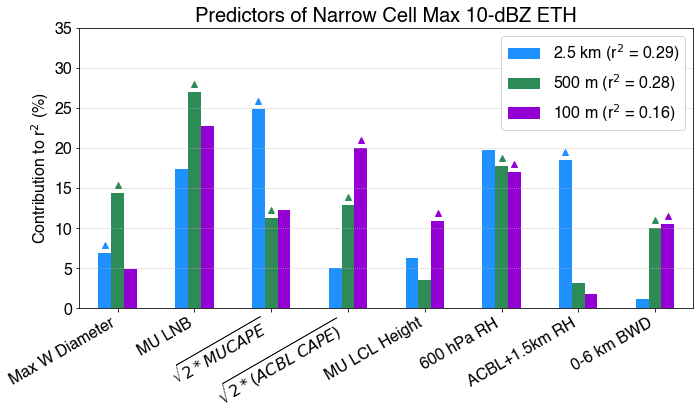

In [146]:
pval_thresh = 0.05

# Plot contributions to r**2 with r**2 values
relimp_perc_d2 = lm_narrow_std_all_eth_d2[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d3 = lm_narrow_std_all_eth_d3[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d4 = lm_narrow_std_all_eth_d4[['relimp_perc']].to_numpy()[1:].squeeze()

df = pd.DataFrame({f"2.5 km (r$^2$ = {lm_narrow_std_all_eth_d2['r2'][0]:.2f})": relimp_perc_d2,
                   f"500 m (r$^2$ = {lm_narrow_std_all_eth_d3['r2'][0]:.2f})": relimp_perc_d3,
                   f"100 m (r$^2$ = {lm_narrow_std_all_eth_d4['r2'][0]:.2f})": relimp_perc_d4,}, index=predictors_all)
# p-values
df_pval = pd.DataFrame({"2.5 km":lm_narrow_std_all_eth_d2['pval'].to_numpy()[1:].squeeze(),
                        "500 m":lm_narrow_std_all_eth_d3['pval'].to_numpy()[1:].squeeze(),
                        "100 m":lm_narrow_std_all_eth_d4['pval'].to_numpy()[1:].squeeze(),}, index=predictors_all)

fig, ax = plt.subplots(1,1, figsize=(10,6))
color_dict = {f"2.5 km (r$^2$ = {lm_narrow_std_all_eth_d2['r2'][0]:.2f})": 'dodgerblue', 
              f"500 m (r$^2$ = {lm_narrow_std_all_eth_d3['r2'][0]:.2f})": 'seagreen',
              f"100 m (r$^2$ = {lm_narrow_std_all_eth_d4['r2'][0]:.2f})": 'darkviolet'}
df.plot.bar(ax=ax, rot=30, fontsize=16, color=color_dict)

# Loop through each container (corresponding to each column in the DataFrame)
for i, container in enumerate(ax.containers):
    column = df.columns[i]  # Get the column name for the current container

    # Iterate through each bar in the container
    for j, bar in enumerate(container):
        bar_x = bar.get_x() + bar.get_width() / 2  # Get the center x position of the bar
        bar_height = bar.get_height()  # Get the bar height
        bar_color = bar.get_facecolor()  # Get the color of the bar
        
        # Get the center x position of the bar
        bar_x = bar.get_x() + bar.get_width() / 2
        bar_height = bar.get_height()
        
        # Check the corresponding p-value
        if df_pval.iloc[j,i] < pval_thresh:
            ax.plot(bar_x, bar_height + 1, marker='^', color=bar_color)
        
ax.legend(fontsize=16)
ax.set_ylabel('Contribution to r$^2$ (%)', fontsize=16)
ax.set_title('Predictors of Narrow Cell Max 10-dBZ ETH', fontsize=20)
ax.set_ylim(0,35)
plt.xticks(horizontalalignment='right')
ax.grid(axis='y', ls=':')

fig.tight_layout()
figname = f'{figdir}Narrow_Cell_All_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
print(figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+1h/Wide_Cell_All_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png


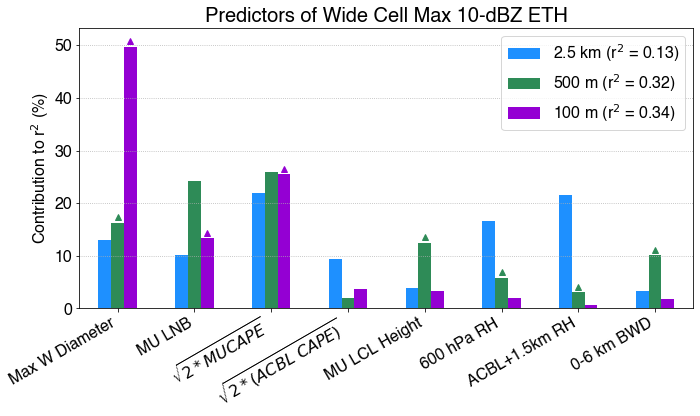

In [147]:
pval_thresh = 0.05

# Plot contributions to r**2 with r**2 values
relimp_perc_d2 = lm_wide_std_all_eth_d2[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d3 = lm_wide_std_all_eth_d3[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d4 = lm_wide_std_all_eth_d4[['relimp_perc']].to_numpy()[1:].squeeze()

df = pd.DataFrame({f"2.5 km (r$^2$ = {lm_wide_std_all_eth_d2['r2'][0]:.2f})": relimp_perc_d2,
                   f"500 m (r$^2$ = {lm_wide_std_all_eth_d3['r2'][0]:.2f})": relimp_perc_d3,
                   f"100 m (r$^2$ = {lm_wide_std_all_eth_d4['r2'][0]:.2f})": relimp_perc_d4,}, index=predictors_all)
# p-values
df_pval = pd.DataFrame({"2.5 km":lm_wide_std_all_eth_d2['pval'].to_numpy()[1:].squeeze(),
                        "500 m":lm_wide_std_all_eth_d3['pval'].to_numpy()[1:].squeeze(),
                        "100 m":lm_wide_std_all_eth_d4['pval'].to_numpy()[1:].squeeze(),}, index=predictors_all)

fig, ax = plt.subplots(1,1, figsize=(10,6))
color_dict = {f"2.5 km (r$^2$ = {lm_wide_std_all_eth_d2['r2'][0]:.2f})": 'dodgerblue', 
              f"500 m (r$^2$ = {lm_wide_std_all_eth_d3['r2'][0]:.2f})": 'seagreen',
              f"100 m (r$^2$ = {lm_wide_std_all_eth_d4['r2'][0]:.2f})": 'darkviolet'}
df.plot.bar(ax=ax, rot=30, fontsize=16, color=color_dict)

# Loop through each container (corresponding to each column in the DataFrame)
for i, container in enumerate(ax.containers):
    column = df.columns[i]  # Get the column name for the current container

    # Iterate through each bar in the container
    for j, bar in enumerate(container):
        bar_x = bar.get_x() + bar.get_width() / 2  # Get the center x position of the bar
        bar_height = bar.get_height()  # Get the bar height
        bar_color = bar.get_facecolor()  # Get the color of the bar
        
        # Get the center x position of the bar
        bar_x = bar.get_x() + bar.get_width() / 2
        bar_height = bar.get_height()
        
        # Check the corresponding p-value
        if df_pval.iloc[j,i] < pval_thresh:
            ax.plot(bar_x, bar_height + 1, marker='^', color=bar_color)
            
ax.legend(fontsize=16)
ax.set_ylabel('Contribution to r$^2$ (%)', fontsize=16)
ax.set_title('Predictors of Wide Cell Max 10-dBZ ETH', fontsize=20)
# ax.set_ylim(0,60)
plt.xticks(horizontalalignment='right')
ax.grid(axis='y', ls=':')

fig.tight_layout()
figname = f'{figdir}Wide_Cell_All_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
print(figname)

## Plot contributions to r<sup>2</sup> (No LNB)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+1h/Narrow_Cell_NoLNB_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png


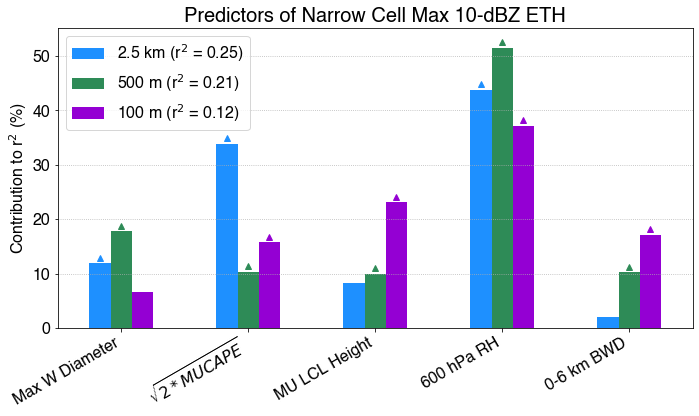

In [148]:
pval_thresh = 0.05

# Plot contributions to r**2 with r**2 values
relimp_perc_d2 = lm_narrow_std_nolnb_eth_d2[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d3 = lm_narrow_std_nolnb_eth_d3[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d4 = lm_narrow_std_nolnb_eth_d4[['relimp_perc']].to_numpy()[1:].squeeze()

df = pd.DataFrame({f"2.5 km (r$^2$ = {lm_narrow_std_nolnb_eth_d2['r2'][0]:.2f})": relimp_perc_d2,
                   f"500 m (r$^2$ = {lm_narrow_std_nolnb_eth_d3['r2'][0]:.2f})": relimp_perc_d3,
                   f"100 m (r$^2$ = {lm_narrow_std_nolnb_eth_d4['r2'][0]:.2f})": relimp_perc_d4,}, index=predictors_nolnb)
# p-values
df_pval = pd.DataFrame({"2.5 km":lm_narrow_std_nolnb_eth_d2['pval'].to_numpy()[1:].squeeze(),
                        "500 m":lm_narrow_std_nolnb_eth_d3['pval'].to_numpy()[1:].squeeze(),
                        "100 m":lm_narrow_std_nolnb_eth_d4['pval'].to_numpy()[1:].squeeze(),}, index=predictors_nolnb)

fig, ax = plt.subplots(1,1, figsize=(10,6))
color_dict = {f"2.5 km (r$^2$ = {lm_narrow_std_nolnb_eth_d2['r2'][0]:.2f})": 'dodgerblue', 
              f"500 m (r$^2$ = {lm_narrow_std_nolnb_eth_d3['r2'][0]:.2f})": 'seagreen',
              f"100 m (r$^2$ = {lm_narrow_std_nolnb_eth_d4['r2'][0]:.2f})": 'darkviolet'}
df.plot.bar(ax=ax, rot=30, fontsize=16, color=color_dict)

# Loop through each container (corresponding to each column in the DataFrame)
for i, container in enumerate(ax.containers):
    column = df.columns[i]  # Get the column name for the current container

    # Iterate through each bar in the container
    for j, bar in enumerate(container):
        bar_x = bar.get_x() + bar.get_width() / 2  # Get the center x position of the bar
        bar_height = bar.get_height()  # Get the bar height
        bar_color = bar.get_facecolor()  # Get the color of the bar
        
        # Get the center x position of the bar
        bar_x = bar.get_x() + bar.get_width() / 2
        bar_height = bar.get_height()
        
        # Check the corresponding p-value
        if df_pval.iloc[j,i] < pval_thresh:
            ax.plot(bar_x, bar_height + 1, marker='^', color=bar_color)
        
ax.legend(fontsize=16)
ax.set_ylabel('Contribution to r$^2$ (%)', fontsize=16)
ax.set_title('Predictors of Narrow Cell Max 10-dBZ ETH', fontsize=20)
# ax.set_ylim(0,50)
plt.xticks(horizontalalignment='right')
ax.grid(axis='y', ls=':')

fig.tight_layout()
figname = f'{figdir}Narrow_Cell_NoLNB_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
print(figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+1h/Wide_Cell_NoLNB_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png


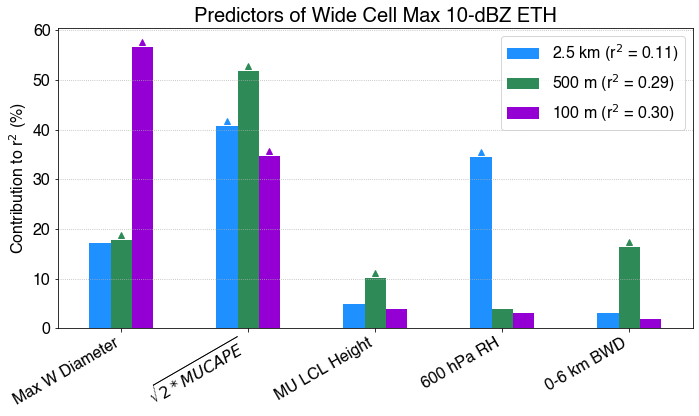

In [149]:
pval_thresh = 0.05

# Plot contributions to r**2 with r**2 values
relimp_perc_d2 = lm_wide_std_nolnb_eth_d2[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d3 = lm_wide_std_nolnb_eth_d3[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d4 = lm_wide_std_nolnb_eth_d4[['relimp_perc']].to_numpy()[1:].squeeze()

df = pd.DataFrame({f"2.5 km (r$^2$ = {lm_wide_std_nolnb_eth_d2['r2'][0]:.2f})": relimp_perc_d2,
                   f"500 m (r$^2$ = {lm_wide_std_nolnb_eth_d3['r2'][0]:.2f})": relimp_perc_d3,
                   f"100 m (r$^2$ = {lm_wide_std_nolnb_eth_d4['r2'][0]:.2f})": relimp_perc_d4,}, index=predictors_nolnb)
# p-values
df_pval = pd.DataFrame({"2.5 km":lm_wide_std_nolnb_eth_d2['pval'].to_numpy()[1:].squeeze(),
                        "500 m":lm_wide_std_nolnb_eth_d3['pval'].to_numpy()[1:].squeeze(),
                        "100 m":lm_wide_std_nolnb_eth_d4['pval'].to_numpy()[1:].squeeze(),}, index=predictors_nolnb)

fig, ax = plt.subplots(1,1, figsize=(10,6))
color_dict = {f"2.5 km (r$^2$ = {lm_wide_std_nolnb_eth_d2['r2'][0]:.2f})": 'dodgerblue', 
              f"500 m (r$^2$ = {lm_wide_std_nolnb_eth_d3['r2'][0]:.2f})": 'seagreen',
              f"100 m (r$^2$ = {lm_wide_std_nolnb_eth_d4['r2'][0]:.2f})": 'darkviolet'}
df.plot.bar(ax=ax, rot=30, fontsize=16, color=color_dict)

# Loop through each container (corresponding to each column in the DataFrame)
for i, container in enumerate(ax.containers):
    column = df.columns[i]  # Get the column name for the current container

    # Iterate through each bar in the container
    for j, bar in enumerate(container):
        bar_x = bar.get_x() + bar.get_width() / 2  # Get the center x position of the bar
        bar_height = bar.get_height()  # Get the bar height
        bar_color = bar.get_facecolor()  # Get the color of the bar
        
        # Get the center x position of the bar
        bar_x = bar.get_x() + bar.get_width() / 2
        bar_height = bar.get_height()
        
        # Check the corresponding p-value
        if df_pval.iloc[j,i] < pval_thresh:
            ax.plot(bar_x, bar_height + 1, marker='^', color=bar_color)
        
ax.legend(fontsize=16)
ax.set_ylabel('Contribution to r$^2$ (%)', fontsize=16)
ax.set_title('Predictors of Wide Cell Max 10-dBZ ETH', fontsize=20)
# ax.set_ylim(0,60)
plt.xticks(horizontalalignment='right')
ax.grid(axis='y', ls=':')

fig.tight_layout()
figname = f'{figdir}Wide_Cell_NoLNB_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
print(figname)

## Plot contributions to r<sup>2</sup> (environmental variables only)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+1h/Narrow_Cell_EnvOnly_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png


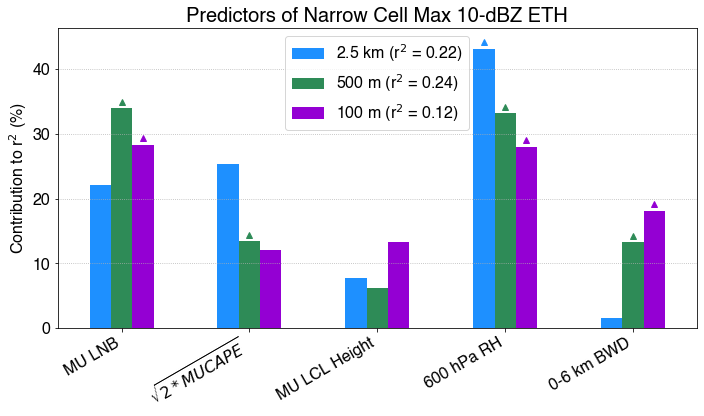

In [150]:
pval_thresh = 0.05

# Plot contributions to r**2 with r**2 values
relimp_perc_d2 = lm_narrow_std_envonly_eth_d2[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d3 = lm_narrow_std_envonly_eth_d3[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d4 = lm_narrow_std_envonly_eth_d4[['relimp_perc']].to_numpy()[1:].squeeze()

df = pd.DataFrame({f"2.5 km (r$^2$ = {lm_narrow_std_envonly_eth_d2['r2'][0]:.2f})": relimp_perc_d2,
                   f"500 m (r$^2$ = {lm_narrow_std_envonly_eth_d3['r2'][0]:.2f})": relimp_perc_d3,
                   f"100 m (r$^2$ = {lm_narrow_std_envonly_eth_d4['r2'][0]:.2f})": relimp_perc_d4,}, index=predictors_envonly)
# p-values
df_pval = pd.DataFrame({"2.5 km":lm_narrow_std_envonly_eth_d2['pval'].to_numpy()[1:].squeeze(),
                        "500 m":lm_narrow_std_envonly_eth_d3['pval'].to_numpy()[1:].squeeze(),
                        "100 m":lm_narrow_std_envonly_eth_d4['pval'].to_numpy()[1:].squeeze(),}, index=predictors_envonly)

fig, ax = plt.subplots(1,1, figsize=(10,6))
color_dict = {f"2.5 km (r$^2$ = {lm_narrow_std_envonly_eth_d2['r2'][0]:.2f})": 'dodgerblue', 
              f"500 m (r$^2$ = {lm_narrow_std_envonly_eth_d3['r2'][0]:.2f})": 'seagreen',
              f"100 m (r$^2$ = {lm_narrow_std_envonly_eth_d4['r2'][0]:.2f})": 'darkviolet'}
df.plot.bar(ax=ax, rot=30, fontsize=16, color=color_dict)

# Loop through each container (corresponding to each column in the DataFrame)
for i, container in enumerate(ax.containers):
    column = df.columns[i]  # Get the column name for the current container

    # Iterate through each bar in the container
    for j, bar in enumerate(container):
        bar_x = bar.get_x() + bar.get_width() / 2  # Get the center x position of the bar
        bar_height = bar.get_height()  # Get the bar height
        bar_color = bar.get_facecolor()  # Get the color of the bar
        
        # Get the center x position of the bar
        bar_x = bar.get_x() + bar.get_width() / 2
        bar_height = bar.get_height()
        
        # Check the corresponding p-value
        if df_pval.iloc[j,i] < pval_thresh:
            ax.plot(bar_x, bar_height + 1, marker='^', color=bar_color)
            
ax.legend(fontsize=16, ncol=1)
ax.set_ylabel('Contribution to r$^2$ (%)', fontsize=16)
ax.set_title('Predictors of Narrow Cell Max 10-dBZ ETH', fontsize=20)
# ax.set_ylim(0,35)
plt.xticks(horizontalalignment='right')
ax.grid(axis='y', ls=':')

fig.tight_layout()
figname = f'{figdir}Narrow_Cell_EnvOnly_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
print(figname)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+1h/Wide_Cell_EnvOnly_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png


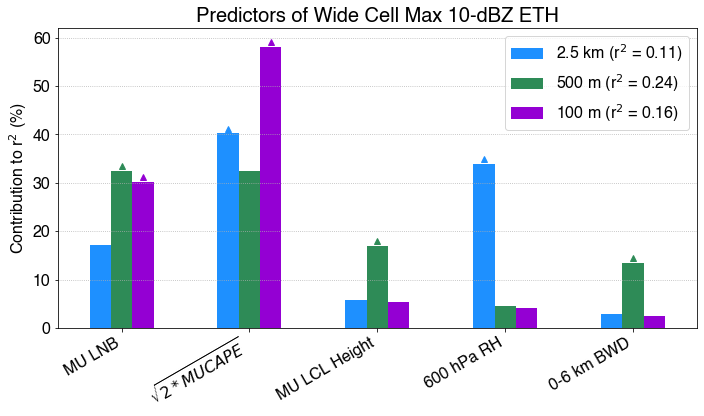

In [151]:
pval_thresh = 0.05

# Plot contributions to r**2 with r**2 values
relimp_perc_d2 = lm_wide_std_envonly_eth_d2[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d3 = lm_wide_std_envonly_eth_d3[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d4 = lm_wide_std_envonly_eth_d4[['relimp_perc']].to_numpy()[1:].squeeze()

# index = ['MU LNB', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', '500 hPa RH', '0-6 km BWD']
df = pd.DataFrame({f"2.5 km (r$^2$ = {lm_wide_std_envonly_eth_d2['r2'][0]:.2f})": relimp_perc_d2,
                   f"500 m (r$^2$ = {lm_wide_std_envonly_eth_d3['r2'][0]:.2f})": relimp_perc_d3,
                   f"100 m (r$^2$ = {lm_wide_std_envonly_eth_d4['r2'][0]:.2f})": relimp_perc_d4,}, index=predictors_envonly)
# p-values
df_pval = pd.DataFrame({"2.5 km":lm_wide_std_envonly_eth_d2['pval'].to_numpy()[1:].squeeze(),
                        "500 m":lm_wide_std_envonly_eth_d3['pval'].to_numpy()[1:].squeeze(),
                        "100 m":lm_wide_std_envonly_eth_d4['pval'].to_numpy()[1:].squeeze(),}, index=predictors_envonly)

fig, ax = plt.subplots(1,1, figsize=(10,6))
color_dict = {f"2.5 km (r$^2$ = {lm_wide_std_envonly_eth_d2['r2'][0]:.2f})": 'dodgerblue', 
              f"500 m (r$^2$ = {lm_wide_std_envonly_eth_d3['r2'][0]:.2f})": 'seagreen',
              f"100 m (r$^2$ = {lm_wide_std_envonly_eth_d4['r2'][0]:.2f})": 'darkviolet'}
df.plot.bar(ax=ax, rot=30, fontsize=16, color=color_dict)

# Loop through each container (corresponding to each column in the DataFrame)
for i, container in enumerate(ax.containers):
    column = df.columns[i]  # Get the column name for the current container

    # Iterate through each bar in the container
    for j, bar in enumerate(container):
        bar_x = bar.get_x() + bar.get_width() / 2  # Get the center x position of the bar
        bar_height = bar.get_height()  # Get the bar height
        bar_color = bar.get_facecolor()  # Get the color of the bar
        
        # Get the center x position of the bar
        bar_x = bar.get_x() + bar.get_width() / 2
        bar_height = bar.get_height()
        
        # Check the corresponding p-value
        if df_pval.iloc[j,i] < pval_thresh:
            ax.plot(bar_x, bar_height + 1, marker='^', color=bar_color)
            
ax.legend(fontsize=16)
ax.set_ylabel('Contribution to r$^2$ (%)', fontsize=16)
ax.set_title('Predictors of Wide Cell Max 10-dBZ ETH', fontsize=20)
# ax.set_ylim(0,60)
plt.xticks(horizontalalignment='right')
ax.grid(axis='y', ls=':')

fig.tight_layout()
figname = f'{figdir}Wide_Cell_EnvOnly_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
print(figname)

In [152]:
figname

'/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+1h/Wide_Cell_EnvOnly_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png'

## Function to plot MLR coefficients & error bars

In [153]:
def plot_coef_errbar(x_n_dict, y_n_dict, err_n_dict, x_w_dict, y_w_dict, err_w_dict, 
                     errbar_lw=3, markersize=None, fontsize=None,
                     xticklabels=None, xlims=None, ylims=None, yticks=None, ylabel=None, labels=None, legend_loc=None,
                     xlabel_list=None, xlabel_pos=None, x_divide=None, xtick1_rot=30, xtick2_rot=30, xtick1_ha='right', xtick2_ha='center',
                     figsize=None, figname=None, dpi=300):
    
    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    fig, ax = plt.subplots(1,1, figsize=figsize, dpi=dpi)

    lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}

    # Plot narrow cells
    ax.plot(x_n_dict['d2'], y_n_dict['d2'], 'D', markersize=markersize, color=lcolors['d2'], label=labels['d2'])
    ax.plot(x_n_dict['d3'], y_n_dict['d3'], 'D', markersize=markersize, color=lcolors['d3'], label=labels['d3'])
    ax.plot(x_n_dict['d4'], y_n_dict['d4'], 'D', markersize=markersize, color=lcolors['d4'], label=labels['d4'])
    for ii in range(len(x_n_dict['d2'])):
        ax.plot([x_n_dict['d2'][ii],x_n_dict['d2'][ii]], [err_n_dict['d2'][0][ii],err_n_dict['d2'][1][ii]], lw=errbar_lw, color=lcolors['d2'])
        ax.plot([x_n_dict['d3'][ii],x_n_dict['d3'][ii]], [err_n_dict['d3'][0][ii],err_n_dict['d3'][1][ii]], lw=errbar_lw, color=lcolors['d3'])
        ax.plot([x_n_dict['d4'][ii],x_n_dict['d4'][ii]], [err_n_dict['d4'][0][ii],err_n_dict['d4'][1][ii]], lw=errbar_lw, color=lcolors['d4'])
    # Plot wide cells
    ax.plot(x_w_dict['d2'], y_w_dict['d2'], 'D', markersize=markersize, color=lcolors['d2'])
    ax.plot(x_w_dict['d3'], y_w_dict['d3'], 'D', markersize=markersize, color=lcolors['d3'])
    ax.plot(x_w_dict['d4'], y_w_dict['d4'], 'D', markersize=markersize, color=lcolors['d4'])
    for ii in range(len(x_w_dict['d2'])):
        ax.plot([x_w_dict['d2'][ii],x_w_dict['d2'][ii]], [err_w_dict['d2'][0][ii],err_w_dict['d2'][1][ii]], lw=errbar_lw, color=lcolors['d2'])
        ax.plot([x_w_dict['d3'][ii],x_w_dict['d3'][ii]], [err_w_dict['d3'][0][ii],err_w_dict['d3'][1][ii]], lw=errbar_lw, color=lcolors['d3'])
        ax.plot([x_w_dict['d4'][ii],x_w_dict['d4'][ii]], [err_w_dict['d4'][0][ii],err_w_dict['d4'][1][ii]], lw=errbar_lw, color=lcolors['d4'])

    # Plot vertical divide lines
    if x_divide is not None:
        for ii in range(len(x_divide)):
            ax.axvline(x=x_divide[ii], color='k', lw=1)
    
    # Set axes
    ax.axhline(y=0, color='k')
    ax.set_xlim(xlims[0], xlims[1])
    if ylims is not None: ax.set_ylim(ylims[0], ylims[1])
    if yticks is not None: ax.set_yticks(yticks)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', ls='--')
    ax.legend(loc=legend_loc)
    
    # Label xaxis
    ax.tick_params('x', length=6)
    xticks = np.arange(1, len(xticklabels)+1)
    plt.xticks(ticks=xticks, labels=xticklabels, rotation=xtick1_rot, ha=xtick1_ha)
    
    # Secondary xaxis for variable names
    secax = ax.secondary_xaxis('top')
    secax.tick_params('x', length=6)
    secax.set_xticks(ticks=xlabel_pos)
    secax.set_xticklabels(xlabel_list)
    secax.xaxis.set_tick_params(rotation=xtick2_rot)
    # Set horizontal alignment for all tick labels to 'right'
    plt.setp(secax.get_xticklabels(), ha=xtick2_ha)
    
    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=dpi, facecolor='w')
    return fig

## Convert Pandas tables to numpy arrays for plotting

In [154]:
lm_wide_std_all_eth_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-0.000,0.082,-0.000,1.000,0.133,0.078,-0.163,0.163,NaN,NaN
1,x1,0.134,0.084,1.586,0.115,0.133,0.078,-0.033,0.301,0.017,12.971
2,x2,-0.465,0.301,-1.548,0.124,0.133,0.078,-1.060,0.129,0.014,10.241
3,x3,0.629,0.325,1.935,0.055,0.133,0.078,-0.014,1.271,0.029,21.924
4,x4,0.013,0.111,0.118,0.906,0.133,0.078,-0.206,0.232,0.013,9.475
5,x5,0.103,0.119,0.861,0.391,0.133,0.078,-0.133,0.339,0.005,3.823
6,x6,0.143,0.125,1.150,0.252,0.133,0.078,-0.103,0.390,0.022,16.680
7,x7,0.146,0.122,1.195,0.234,0.133,0.078,-0.095,0.386,0.029,21.610
8,x8,-0.108,0.097,-1.106,0.271,0.133,0.078,-0.300,0.085,0.004,3.276


In [155]:
# Coefficient
narrow_stdcoef_all_eth_d2 = lm_narrow_std_all_eth_d2[['coef']].to_numpy()[1:].squeeze()
n_predictor_all = len(narrow_stdcoef_all_eth_d2)
# Coefficient Confidence Intervals
narrow_stdcoefCI_all_eth_d2 = np.full((2, n_predictor_all), np.NaN)
narrow_stdcoefCI_all_eth_d2[0,:] = lm_narrow_std_all_eth_d2[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_all_eth_d2[1,:] = lm_narrow_std_all_eth_d2[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_all_eth_d2 = lm_wide_std_all_eth_d2[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_all_eth_d2 = np.full((2, n_predictor_all), np.NaN)
wide_stdcoefCI_all_eth_d2[0,:] = lm_wide_std_all_eth_d2[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_all_eth_d2[1,:] = lm_wide_std_all_eth_d2[['CI[97.5%]']].to_numpy()[1:].squeeze()

narrow_stdcoef_all_eth_d3 = lm_narrow_std_all_eth_d3[['coef']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_all_eth_d3 = np.full((2, n_predictor_all), np.NaN)
narrow_stdcoefCI_all_eth_d3[0,:] = lm_narrow_std_all_eth_d3[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_all_eth_d3[1,:] = lm_narrow_std_all_eth_d3[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_all_eth_d3 = lm_wide_std_all_eth_d3[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_all_eth_d3 = np.full((2, n_predictor_all), np.NaN)
wide_stdcoefCI_all_eth_d3[0,:] = lm_wide_std_all_eth_d3[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_all_eth_d3[1,:] = lm_wide_std_all_eth_d3[['CI[97.5%]']].to_numpy()[1:].squeeze()

narrow_stdcoef_all_eth_d4 = lm_narrow_std_all_eth_d4[['coef']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_all_eth_d4 = np.full((2, n_predictor_all), np.NaN)
narrow_stdcoefCI_all_eth_d4[0,:] = lm_narrow_std_all_eth_d4[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_all_eth_d4[1,:] = lm_narrow_std_all_eth_d4[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_all_eth_d4 = lm_wide_std_all_eth_d4[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_all_eth_d4 = np.full((2, n_predictor_all), np.NaN)
wide_stdcoefCI_all_eth_d4[0,:] = lm_wide_std_all_eth_d4[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_all_eth_d4[1,:] = lm_wide_std_all_eth_d4[['CI[97.5%]']].to_numpy()[1:].squeeze()

# Make narrow predictor x positions
x_n_d2 = np.arange(1, 2*n_predictor_all, 2)-0.2
x_n_d3 = np.arange(1, 2*n_predictor_all, 2)
x_n_d4 = np.arange(1, 2*n_predictor_all, 2)+0.2
print(x_n_d2, x_n_d3, x_n_d4)

# Make wide predictor x positions
x_w_d2 = np.arange(2, 2*n_predictor_all+1, 2)-0.2
x_w_d3 = np.arange(2, 2*n_predictor_all+1, 2)
x_w_d4 = np.arange(2, 2*n_predictor_all+1, 2)+0.2
print(x_w_d2, x_w_d3, x_w_d4)

[ 0.8  2.8  4.8  6.8  8.8 10.8 12.8 14.8] [ 1  3  5  7  9 11 13 15] [ 1.2  3.2  5.2  7.2  9.2 11.2 13.2 15.2]
[ 1.8  3.8  5.8  7.8  9.8 11.8 13.8 15.8] [ 2  4  6  8 10 12 14 16] [ 2.2  4.2  6.2  8.2 10.2 12.2 14.2 16.2]


/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+1h/MLR_ETH_Standardized_Coefficients_All.png


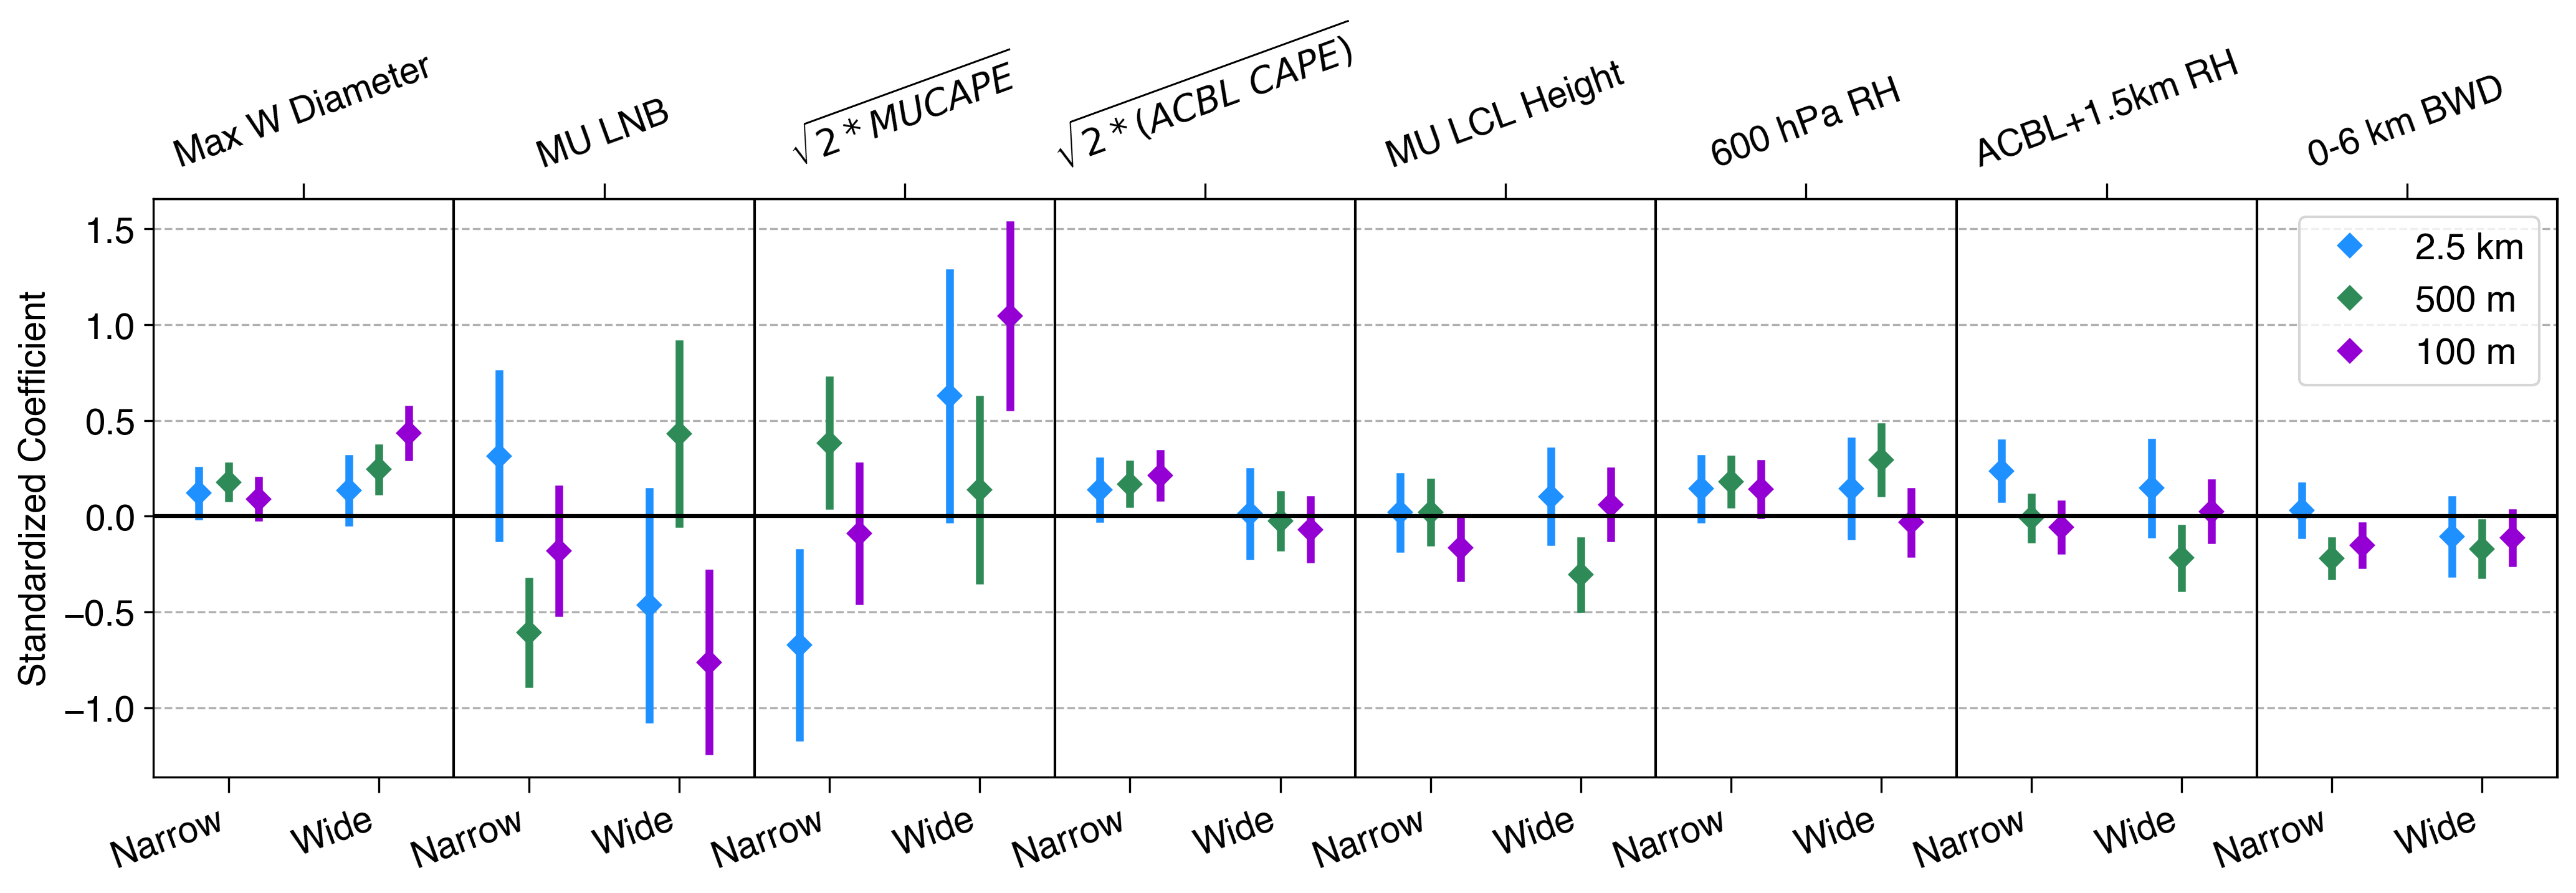

In [156]:
x_n_dict = {'d2':x_n_d2, 'd3':x_n_d3, 'd4':x_n_d4}
y_n_dict = {'d2':narrow_stdcoef_all_eth_d2, 'd3':narrow_stdcoef_all_eth_d3, 'd4':narrow_stdcoef_all_eth_d4}
err_n_dict = {'d2':narrow_stdcoefCI_all_eth_d2, 'd3':narrow_stdcoefCI_all_eth_d3, 'd4':narrow_stdcoefCI_all_eth_d4}
x_w_dict = {'d2':x_w_d2, 'd3':x_w_d3, 'd4':x_w_d4}
y_w_dict = {'d2':wide_stdcoef_all_eth_d2, 'd3':wide_stdcoef_all_eth_d3, 'd4':wide_stdcoef_all_eth_d4}
err_w_dict = {'d2':wide_stdcoefCI_all_eth_d2, 'd3':wide_stdcoefCI_all_eth_d3, 'd4':wide_stdcoefCI_all_eth_d4}
x_divide = np.arange(0, 2*n_predictor_all+1, 2)+0.5
xticklabels = ['Narrow','Wide']*n_predictor_all
xlabel_list = predictors_all
xlabel_pos = (x_divide[:-1] + x_divide[1:])/2
xlims = (np.min(x_divide), np.max(x_divide))
ylims = None
yticks = None
# ylims = (-1.8, 1.5)
# yticks = np.arange(-1.8, 1.51, 0.3)
ylabel = 'Standardized Coefficient'
labels = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}
legend_loc = 'upper right'
markersize = 6
errbar_lw = 3
xtick1_rot = 20
xtick2_rot = 20
fontsize = 14
figsize = (14,5)
figname = f'{figdir}MLR_ETH_Standardized_Coefficients_All.png'
print(figname)
fig = plot_coef_errbar(x_n_dict, y_n_dict, err_n_dict, x_w_dict, y_w_dict, err_w_dict, 
                       errbar_lw=errbar_lw, markersize=markersize, fontsize=fontsize,
                       xticklabels=xticklabels, xlims=xlims, ylims=ylims, yticks=yticks, ylabel=ylabel, labels=labels, legend_loc=legend_loc,
                       xlabel_list=xlabel_list, xlabel_pos=xlabel_pos, x_divide=x_divide, xtick1_rot=xtick1_rot, xtick2_rot=xtick2_rot,
                       figname=figname, figsize=figsize, dpi=300)

In [157]:
# Coefficient
narrow_stdcoef_nolnb_eth_d2 = lm_narrow_std_nolnb_eth_d2[['coef']].to_numpy()[1:].squeeze()
n_predictor_nolnb = len(narrow_stdcoef_nolnb_eth_d2)
# Coefficient Confidence Intervals
narrow_stdcoefCI_nolnb_eth_d2 = np.full((2, n_predictor_nolnb), np.NaN)
narrow_stdcoefCI_nolnb_eth_d2[0,:] = lm_narrow_std_nolnb_eth_d2[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_nolnb_eth_d2[1,:] = lm_narrow_std_nolnb_eth_d2[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_nolnb_eth_d2 = lm_wide_std_nolnb_eth_d2[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_nolnb_eth_d2 = np.full((2, n_predictor_nolnb), np.NaN)
wide_stdcoefCI_nolnb_eth_d2[0,:] = lm_wide_std_nolnb_eth_d2[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_nolnb_eth_d2[1,:] = lm_wide_std_nolnb_eth_d2[['CI[97.5%]']].to_numpy()[1:].squeeze()

narrow_stdcoef_nolnb_eth_d3 = lm_narrow_std_nolnb_eth_d3[['coef']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_nolnb_eth_d3 = np.full((2, n_predictor_nolnb), np.NaN)
narrow_stdcoefCI_nolnb_eth_d3[0,:] = lm_narrow_std_nolnb_eth_d3[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_nolnb_eth_d3[1,:] = lm_narrow_std_nolnb_eth_d3[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_nolnb_eth_d3 = lm_wide_std_nolnb_eth_d3[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_nolnb_eth_d3 = np.full((2, n_predictor_nolnb), np.NaN)
wide_stdcoefCI_nolnb_eth_d3[0,:] = lm_wide_std_nolnb_eth_d3[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_nolnb_eth_d3[1,:] = lm_wide_std_nolnb_eth_d3[['CI[97.5%]']].to_numpy()[1:].squeeze()

narrow_stdcoef_nolnb_eth_d4 = lm_narrow_std_nolnb_eth_d4[['coef']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_nolnb_eth_d4 = np.full((2, n_predictor_nolnb), np.NaN)
narrow_stdcoefCI_nolnb_eth_d4[0,:] = lm_narrow_std_nolnb_eth_d4[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_nolnb_eth_d4[1,:] = lm_narrow_std_nolnb_eth_d4[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_nolnb_eth_d4 = lm_wide_std_nolnb_eth_d4[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_nolnb_eth_d4 = np.full((2, n_predictor_nolnb), np.NaN)
wide_stdcoefCI_nolnb_eth_d4[0,:] = lm_wide_std_nolnb_eth_d4[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_nolnb_eth_d4[1,:] = lm_wide_std_nolnb_eth_d4[['CI[97.5%]']].to_numpy()[1:].squeeze()

# Make narrow predictor x positions
x_n_d2 = np.arange(1, 2*n_predictor_nolnb, 2)-0.2
x_n_d3 = np.arange(1, 2*n_predictor_nolnb, 2)
x_n_d4 = np.arange(1, 2*n_predictor_nolnb, 2)+0.2
print(x_n_d2, x_n_d3, x_n_d4)

# Make wide predictor x positions
x_w_d2 = np.arange(2, 2*n_predictor_nolnb+1, 2)-0.2
x_w_d3 = np.arange(2, 2*n_predictor_nolnb+1, 2)
x_w_d4 = np.arange(2, 2*n_predictor_nolnb+1, 2)+0.2
print(x_w_d2, x_w_d3, x_w_d4)

[0.8 2.8 4.8 6.8 8.8] [1 3 5 7 9] [1.2 3.2 5.2 7.2 9.2]
[1.8 3.8 5.8 7.8 9.8] [ 2  4  6  8 10] [ 2.2  4.2  6.2  8.2 10.2]


/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+1h/MLR_ETH_Standardized_Coefficients_NoLNB.png


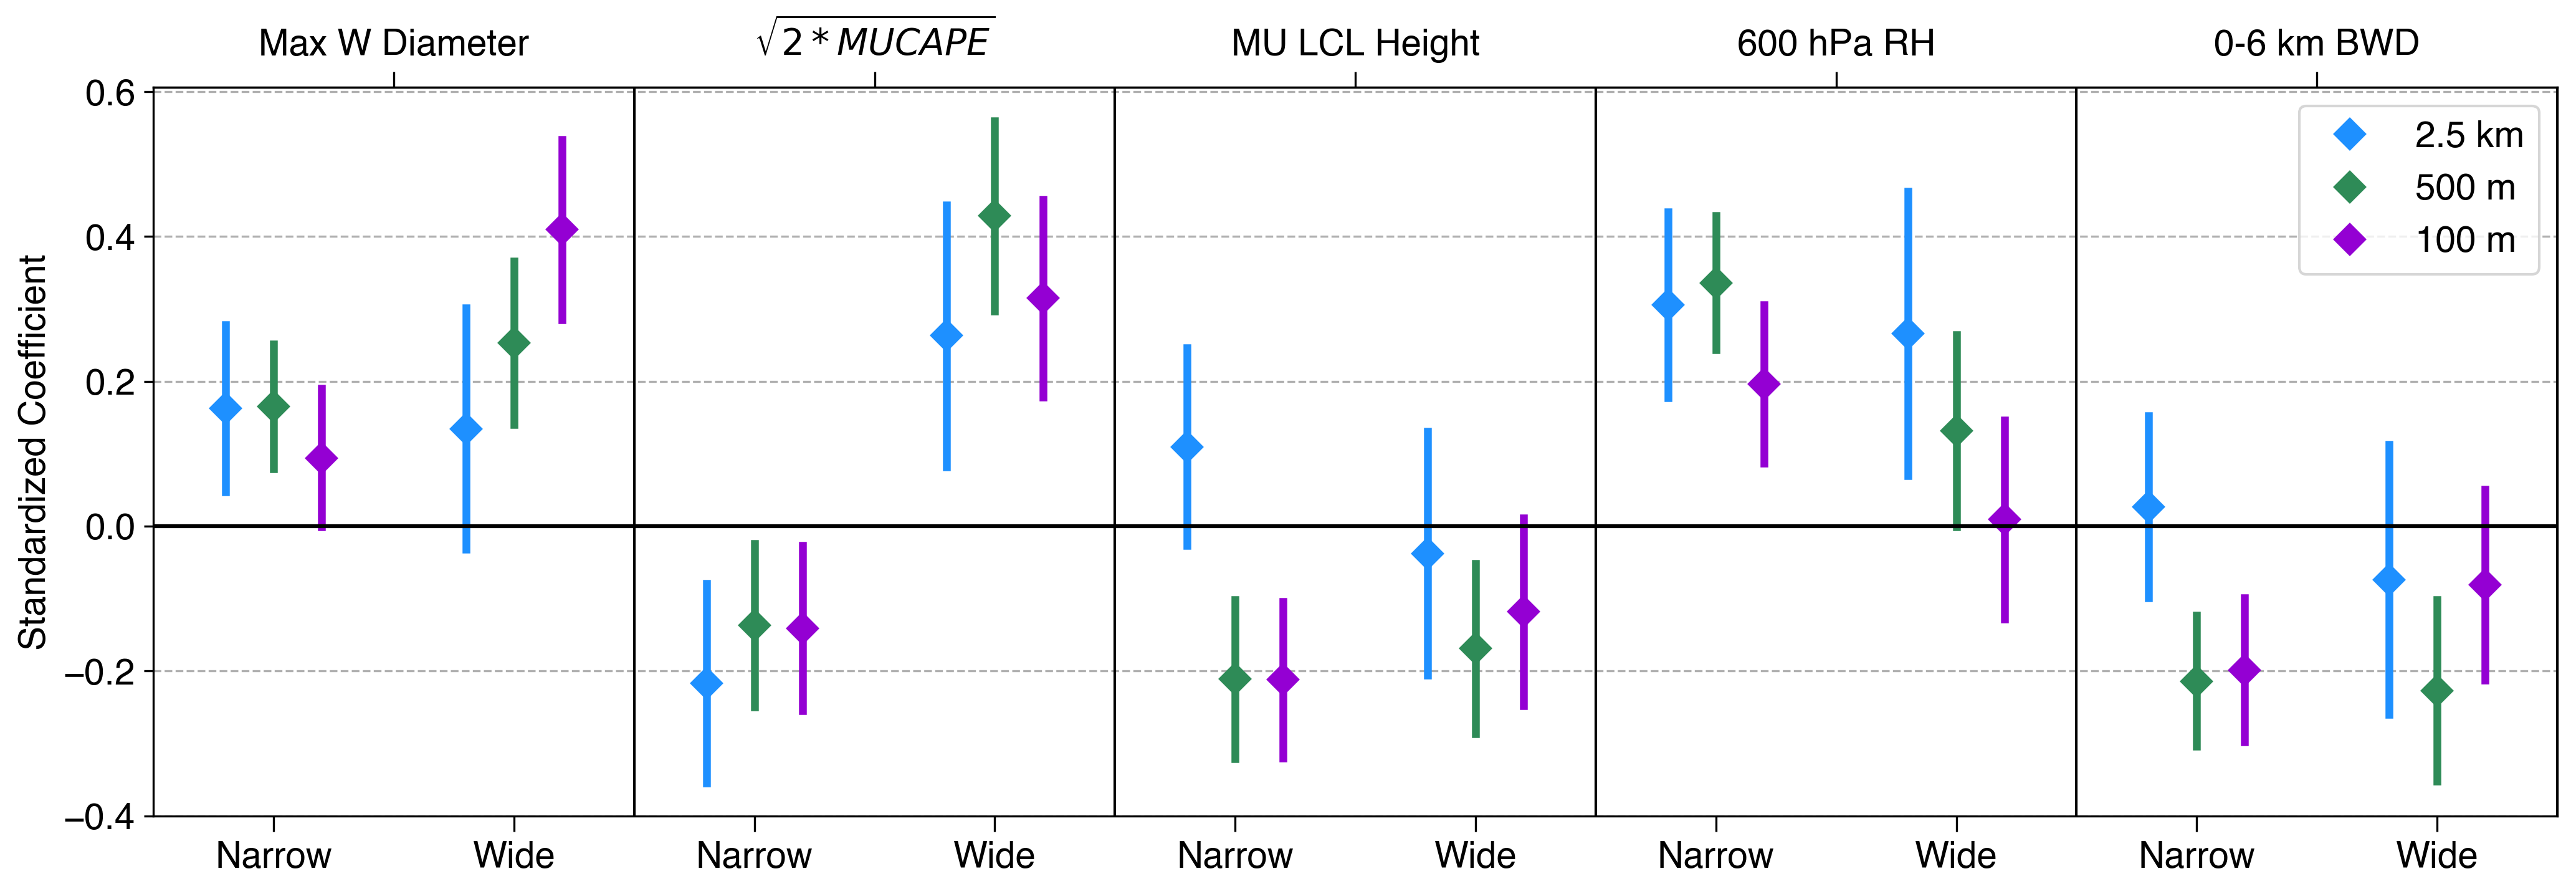

In [158]:
x_n_dict = {'d2':x_n_d2, 'd3':x_n_d3, 'd4':x_n_d4}
y_n_dict = {'d2':narrow_stdcoef_nolnb_eth_d2, 'd3':narrow_stdcoef_nolnb_eth_d3, 'd4':narrow_stdcoef_nolnb_eth_d4}
err_n_dict = {'d2':narrow_stdcoefCI_nolnb_eth_d2, 'd3':narrow_stdcoefCI_nolnb_eth_d3, 'd4':narrow_stdcoefCI_nolnb_eth_d4}
x_w_dict = {'d2':x_w_d2, 'd3':x_w_d3, 'd4':x_w_d4}
y_w_dict = {'d2':wide_stdcoef_nolnb_eth_d2, 'd3':wide_stdcoef_nolnb_eth_d3, 'd4':wide_stdcoef_nolnb_eth_d4}
err_w_dict = {'d2':wide_stdcoefCI_nolnb_eth_d2, 'd3':wide_stdcoefCI_nolnb_eth_d3, 'd4':wide_stdcoefCI_nolnb_eth_d4}
x_divide = np.arange(0, 2*n_predictor_nolnb+1, 2)+0.5
xticklabels = ['Narrow','Wide']*n_predictor_nolnb
xlabel_list = predictors_nolnb
xlabel_pos = (x_divide[:-1] + x_divide[1:])/2
xlims = (np.min(x_divide), np.max(x_divide))
ylims = None
yticks = None
# ylims = (-1.8, 1.5)
# yticks = np.arange(-1.8, 1.51, 0.3)
ylabel = 'Standardized Coefficient'
labels = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}
legend_loc = 'upper right'
markersize = 8
errbar_lw = 3
xtick1_rot = 0
xtick2_rot = 0
xtick1_ha = 'center'
xtick2_ha = 'center'
fontsize = 14
figsize = (14,5)
figname = f'{figdir}MLR_ETH_Standardized_Coefficients_NoLNB.png'
print(figname)
fig = plot_coef_errbar(x_n_dict, y_n_dict, err_n_dict, x_w_dict, y_w_dict, err_w_dict, 
                       errbar_lw=errbar_lw, markersize=markersize, fontsize=fontsize,
                       xticklabels=xticklabels, xlims=xlims, ylims=ylims, yticks=yticks, ylabel=ylabel, labels=labels, legend_loc=legend_loc,
                       xlabel_list=xlabel_list, xlabel_pos=xlabel_pos, x_divide=x_divide, xtick1_rot=xtick1_rot, xtick2_rot=xtick2_rot, xtick1_ha=xtick1_ha, xtick2_ha=xtick2_ha,
                       figname=figname, figsize=figsize, dpi=300)

In [159]:
lm_wide_std_envonly_eth_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-0.000,0.083,-0.000,1.000,0.107,0.073,-0.163,0.163,NaN,NaN
1,x1,-0.430,0.265,-1.625,0.106,0.107,0.073,-0.954,0.093,0.018,17.247
2,x2,0.659,0.263,2.503,0.014,0.107,0.073,0.138,1.180,0.043,40.195
3,x3,0.069,0.110,0.631,0.529,0.107,0.073,-0.148,0.287,0.006,5.820
4,x4,0.233,0.102,2.293,0.023,0.107,0.073,0.032,0.434,0.036,33.870
5,x5,-0.058,0.093,-0.620,0.536,0.107,0.073,-0.243,0.127,0.003,2.867


In [160]:
# Coefficient
narrow_stdcoef_envonly_eth_d2 = lm_narrow_std_envonly_eth_d2[['coef']].to_numpy()[1:].squeeze()
n_predictor_envonly = len(narrow_stdcoef_envonly_eth_d2)
# Coefficient Confidence Intervals
narrow_stdcoefCI_envonly_eth_d2 = np.full((2, n_predictor_envonly), np.NaN)
narrow_stdcoefCI_envonly_eth_d2[0,:] = lm_narrow_std_envonly_eth_d2[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_envonly_eth_d2[1,:] = lm_narrow_std_envonly_eth_d2[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_envonly_eth_d2 = lm_wide_std_envonly_eth_d2[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_envonly_eth_d2 = np.full((2, n_predictor_envonly), np.NaN)
wide_stdcoefCI_envonly_eth_d2[0,:] = lm_wide_std_envonly_eth_d2[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_envonly_eth_d2[1,:] = lm_wide_std_envonly_eth_d2[['CI[97.5%]']].to_numpy()[1:].squeeze()

narrow_stdcoef_envonly_eth_d3 = lm_narrow_std_envonly_eth_d3[['coef']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_envonly_eth_d3 = np.full((2, n_predictor_envonly), np.NaN)
narrow_stdcoefCI_envonly_eth_d3[0,:] = lm_narrow_std_envonly_eth_d3[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_envonly_eth_d3[1,:] = lm_narrow_std_envonly_eth_d3[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_envonly_eth_d3 = lm_wide_std_envonly_eth_d3[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_envonly_eth_d3 = np.full((2, n_predictor_envonly), np.NaN)
wide_stdcoefCI_envonly_eth_d3[0,:] = lm_wide_std_envonly_eth_d3[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_envonly_eth_d3[1,:] = lm_wide_std_envonly_eth_d3[['CI[97.5%]']].to_numpy()[1:].squeeze()

narrow_stdcoef_envonly_eth_d4 = lm_narrow_std_envonly_eth_d4[['coef']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_envonly_eth_d4 = np.full((2, n_predictor_envonly), np.NaN)
narrow_stdcoefCI_envonly_eth_d4[0,:] = lm_narrow_std_envonly_eth_d4[['CI[2.5%]']].to_numpy()[1:].squeeze()
narrow_stdcoefCI_envonly_eth_d4[1,:] = lm_narrow_std_envonly_eth_d4[['CI[97.5%]']].to_numpy()[1:].squeeze()

wide_stdcoef_envonly_eth_d4 = lm_wide_std_envonly_eth_d4[['coef']].to_numpy()[1:].squeeze()
wide_stdcoefCI_envonly_eth_d4 = np.full((2, n_predictor_envonly), np.NaN)
wide_stdcoefCI_envonly_eth_d4[0,:] = lm_wide_std_envonly_eth_d4[['CI[2.5%]']].to_numpy()[1:].squeeze()
wide_stdcoefCI_envonly_eth_d4[1,:] = lm_wide_std_envonly_eth_d4[['CI[97.5%]']].to_numpy()[1:].squeeze()

# Make narrow predictor x positions
x_n_d2 = np.arange(1, 2*n_predictor_envonly, 2)-0.2
x_n_d3 = np.arange(1, 2*n_predictor_envonly, 2)
x_n_d4 = np.arange(1, 2*n_predictor_envonly, 2)+0.2
print(x_n_d2, x_n_d3, x_n_d4)

# Make wide predictor x positions
x_w_d2 = np.arange(2, 2*n_predictor_envonly+1, 2)-0.2
x_w_d3 = np.arange(2, 2*n_predictor_envonly+1, 2)
x_w_d4 = np.arange(2, 2*n_predictor_envonly+1, 2)+0.2
print(x_w_d2, x_w_d3, x_w_d4)

[0.8 2.8 4.8 6.8 8.8] [1 3 5 7 9] [1.2 3.2 5.2 7.2 9.2]
[1.8 3.8 5.8 7.8 9.8] [ 2  4  6  8 10] [ 2.2  4.2  6.2  8.2 10.2]


/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+1h/MLR_ETH_Standardized_Coefficients_EnvOnlys.png


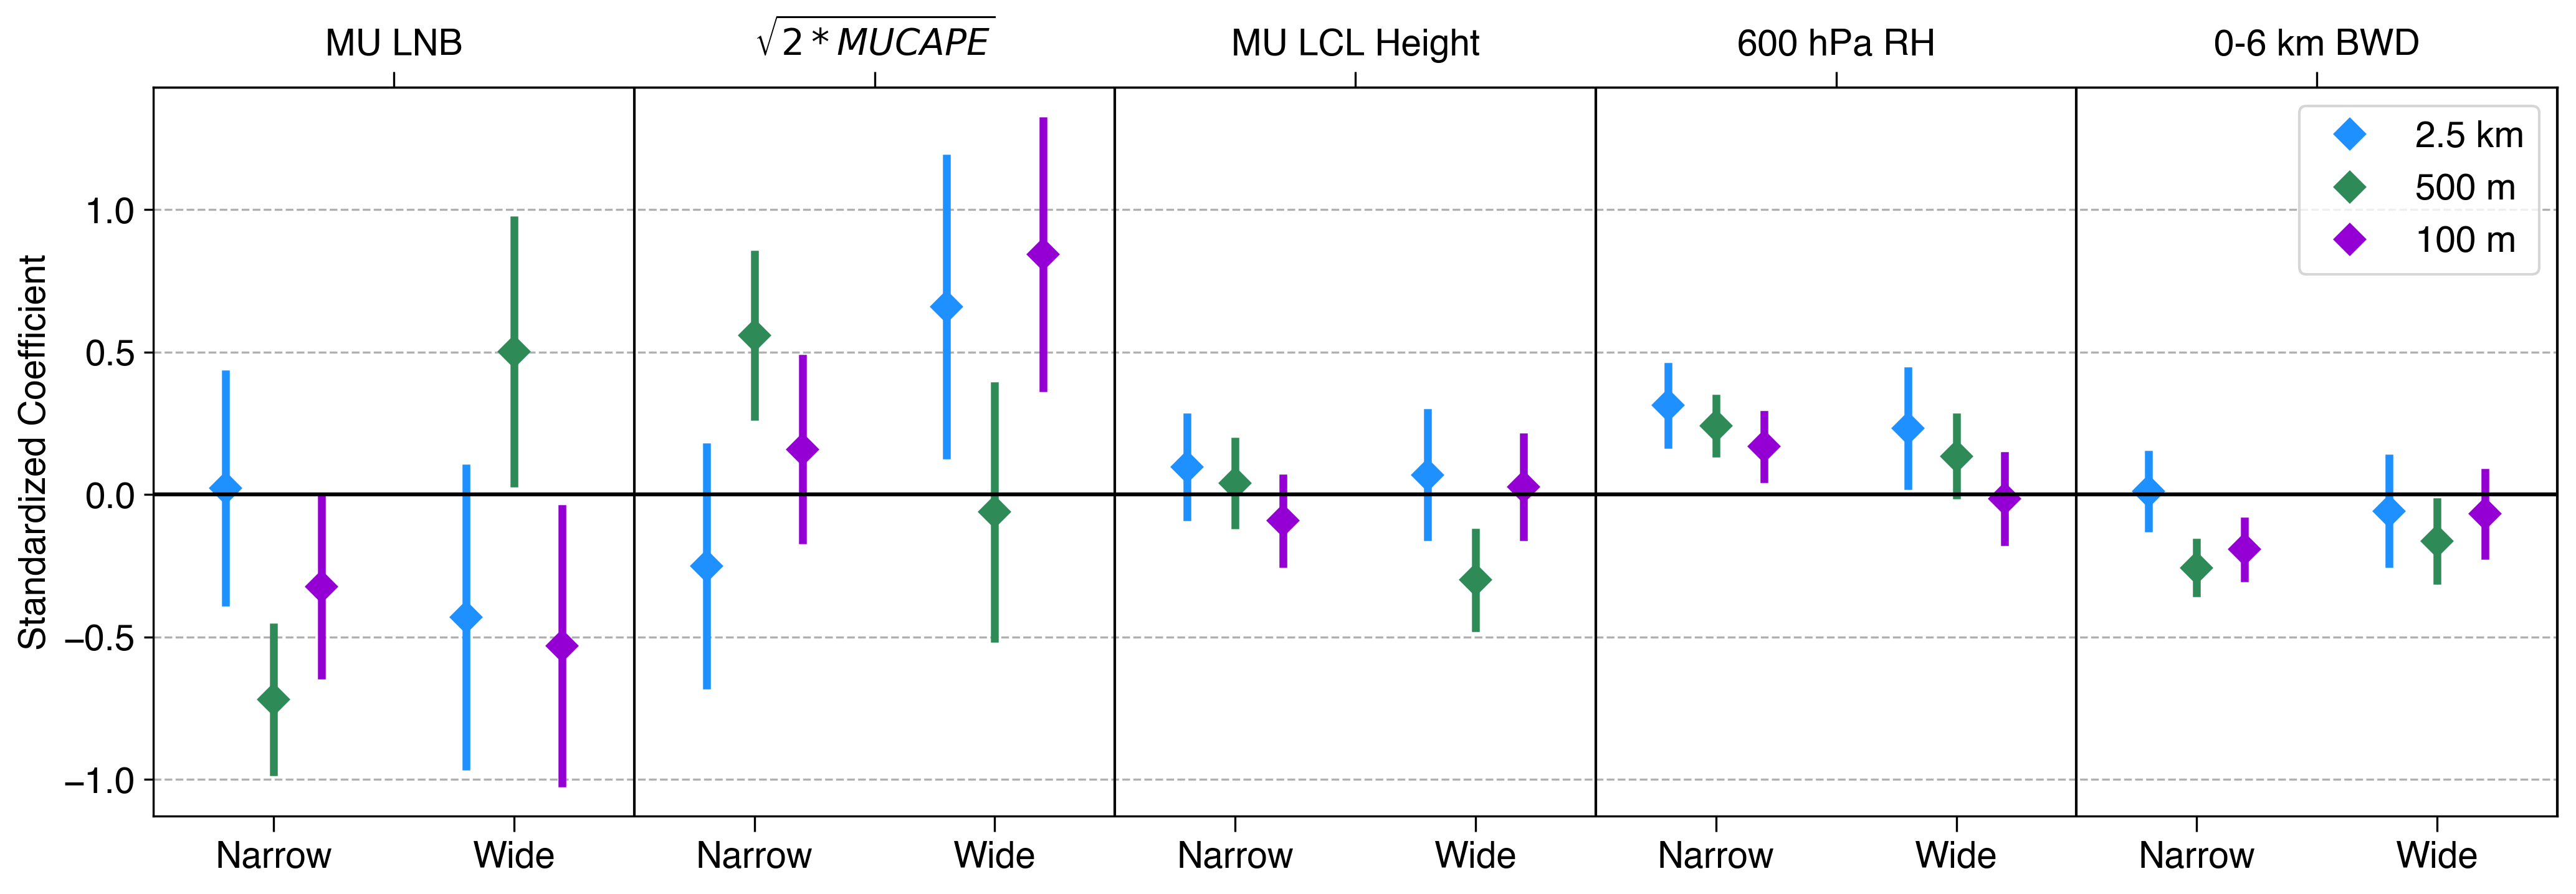

In [161]:
x_n_dict = {'d2':x_n_d2, 'd3':x_n_d3, 'd4':x_n_d4}
y_n_dict = {'d2':narrow_stdcoef_envonly_eth_d2, 'd3':narrow_stdcoef_envonly_eth_d3, 'd4':narrow_stdcoef_envonly_eth_d4}
err_n_dict = {'d2':narrow_stdcoefCI_envonly_eth_d2, 'd3':narrow_stdcoefCI_envonly_eth_d3, 'd4':narrow_stdcoefCI_envonly_eth_d4}
x_w_dict = {'d2':x_w_d2, 'd3':x_w_d3, 'd4':x_w_d4}
y_w_dict = {'d2':wide_stdcoef_envonly_eth_d2, 'd3':wide_stdcoef_envonly_eth_d3, 'd4':wide_stdcoef_envonly_eth_d4}
err_w_dict = {'d2':wide_stdcoefCI_envonly_eth_d2, 'd3':wide_stdcoefCI_envonly_eth_d3, 'd4':wide_stdcoefCI_envonly_eth_d4}
x_divide = np.arange(0, 2*n_predictor_envonly+1, 2)+0.5
xticklabels = ['Narrow','Wide']*n_predictor_envonly
xlabel_list = predictors_envonly
xlabel_pos = (x_divide[:-1] + x_divide[1:])/2
xlims = (np.min(x_divide), np.max(x_divide))
ylims = None
yticks = None
# ylims = (-1.8, 1.5)
# yticks = np.arange(-1.8, 1.51, 0.3)
ylabel = 'Standardized Coefficient'
labels = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}
legend_loc = 'upper right'
markersize = 8
errbar_lw = 3
xtick1_rot = 0
xtick2_rot = 0
xtick1_ha = 'center'
xtick2_ha = 'center'
fontsize = 14
figsize = (14,5)
figname = f'{figdir}MLR_ETH_Standardized_Coefficients_EnvOnlys.png'
print(figname)
fig = plot_coef_errbar(x_n_dict, y_n_dict, err_n_dict, x_w_dict, y_w_dict, err_w_dict, 
                       errbar_lw=errbar_lw, markersize=markersize, fontsize=fontsize,
                       xticklabels=xticklabels, xlims=xlims, ylims=ylims, yticks=yticks, ylabel=ylabel, labels=labels, legend_loc=legend_loc,
                       xlabel_list=xlabel_list, xlabel_pos=xlabel_pos, x_divide=x_divide, xtick1_rot=xtick1_rot, xtick2_rot=xtick2_rot, xtick1_ha=xtick1_ha, xtick2_ha=xtick2_ha,
                       figname=figname, figsize=figsize, dpi=300)

In [162]:
lm_narrow_std_nolnb_eth_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.058,0.000,1.000,0.246,0.229,-0.115,0.115,NaN,NaN
1,x1,0.163,0.059,2.775,0.006,0.246,0.229,0.047,0.278,0.029,11.928
2,x2,-0.217,0.070,-3.099,0.002,0.246,0.229,-0.355,-0.079,0.083,33.927
3,x3,0.109,0.069,1.583,0.115,0.246,0.229,-0.027,0.246,0.020,8.280
4,x4,0.306,0.065,4.688,0.000,0.246,0.229,0.177,0.434,0.108,43.777
5,x5,0.027,0.064,0.415,0.678,0.246,0.229,-0.099,0.152,0.005,2.087


In [163]:
predictors_nolnb

['Max W Diameter',
 '$\\sqrt{2*MUCAPE}$',
 'MU LCL Height',
 '600 hPa RH',
 '0-6 km BWD']

In [164]:
# narrow_nolnb_eth_predicted_d2 = narrow_stdcoef_nolnb_eth_d2[0]*df_narrow_std_d2['Max W Diameter'] + \
#                                 narrow_stdcoef_nolnb_eth_d2[1]*df_narrow_std_d2['$\\sqrt{2*MUCAPE}$'] + \
#                                 narrow_stdcoef_nolnb_eth_d2[2]*df_narrow_std_d2['MU LCL Height'] + \
#                                 narrow_stdcoef_nolnb_eth_d2[3]*df_narrow_std_d2['600 hPa RH'] + \
#                                 narrow_stdcoef_nolnb_eth_d2[4]*df_narrow_std_d2['0-6 km BWD']
# # Convert standardized values back to actual values
# narrow_nolnb_eth_predicted2_d2 = np.std(df_narrow_d2['Max 10dBZ ETH']) * narrow_nolnb_eth_predicted_d2 + np.nanmean(df_narrow_d2['Max 10dBZ ETH'])

In [165]:
# # Compute ETH from MLR
# narrow_nolnb_eth_predicted_d2 = np.full(df_narrow_std_d2.shape[0], 0, dtype=float)
# # Loop over each predictor
# for ii, var in enumerate(predictors_nolnb):
#     narrow_nolnb_eth_predicted_d2[:] += narrow_stdcoef_nolnb_eth_d2[ii]*df_narrow_std_d2[var].values
# # Convert standardized values back to actual values
# narrow_nolnb_eth_predicted2_d2 = np.std(df_narrow_d2['Max 10dBZ ETH']) * tmp + np.nanmean(df_narrow_d2['Max 10dBZ ETH'])

## Compute predicted values from MLR

In [166]:
def calc_mlr_predict(df_std, df, coef_std, predictors, predictand_name):
    """
    Calculate predicted values from MLR
    
    Args:
        df_std: Pandas DataFrame
            DataFrame with standardized predictor variables.
        df: Pandas DataFrame
            DataFrame with original predictor variables.
        coef_std: array-like
            Standardized coefficients from MLR.
        predictors: list
            A list containing the names of predictors. Length must match coef_std.
        predictand_name: string
            Name of the predictand.        
        
    Returns:
        predicted: array-like
            Predicted values from MLR.
    """
    # Check if length of predictors is the same with coef_std
    if len(predictors) != len(coef_std):
        print(f"WARNING: length of predictors does NOT match length of coef_std!")
        
    # Make an array to store predicted values
    predicted_std = np.full(df.shape[0], 0, dtype=float)
    # Loop over each predictor
    for ii, var in enumerate(predictors):
        # Sum(coeficient[i] * standardized_value[i])
        predicted_std[:] += coef_std[ii] * df_std[var].values

    # Convert standardized values back to actual values
    predicted = np.nanstd(df[predictand_name]) * predicted_std + np.nanmean(df[predictand_name])
    
    return predicted

In [167]:
predictand_name = 'Max 10dBZ ETH'
narrow_nolnb_eth_predicted_d2 = calc_mlr_predict(df_narrow_std_d2, df_narrow_d2, narrow_stdcoef_nolnb_eth_d2, predictors_nolnb, predictand_name)
wide_nolnb_eth_predicted_d2 = calc_mlr_predict(df_wide_std_d2, df_wide_d2, wide_stdcoef_nolnb_eth_d2, predictors_nolnb, predictand_name)

narrow_nolnb_eth_predicted_d3 = calc_mlr_predict(df_narrow_std_d3, df_narrow_d3, narrow_stdcoef_nolnb_eth_d3, predictors_nolnb, predictand_name)
wide_nolnb_eth_predicted_d3 = calc_mlr_predict(df_wide_std_d3, df_wide_d3, wide_stdcoef_nolnb_eth_d3, predictors_nolnb, predictand_name)

narrow_nolnb_eth_predicted_d4 = calc_mlr_predict(df_narrow_std_d4, df_narrow_d4, narrow_stdcoef_nolnb_eth_d4, predictors_nolnb, predictand_name)
wide_nolnb_eth_predicted_d4 = calc_mlr_predict(df_wide_std_d4, df_wide_d4, wide_stdcoef_nolnb_eth_d4, predictors_nolnb, predictand_name)

In [168]:
predictand_name = 'Max 10dBZ ETH'
narrow_all_eth_predicted_d2 = calc_mlr_predict(df_narrow_std_d2, df_narrow_d2, narrow_stdcoef_all_eth_d2, predictors_all, predictand_name)
wide_all_eth_predicted_d2 = calc_mlr_predict(df_wide_std_d2, df_wide_d2, wide_stdcoef_all_eth_d2, predictors_all, predictand_name)

narrow_all_eth_predicted_d3 = calc_mlr_predict(df_narrow_std_d3, df_narrow_d3, narrow_stdcoef_all_eth_d3, predictors_all, predictand_name)
wide_all_eth_predicted_d3 = calc_mlr_predict(df_wide_std_d3, df_wide_d3, wide_stdcoef_all_eth_d3, predictors_all, predictand_name)

narrow_all_eth_predicted_d4 = calc_mlr_predict(df_narrow_std_d4, df_narrow_d4, narrow_stdcoef_all_eth_d4, predictors_all, predictand_name)
wide_all_eth_predicted_d4 = calc_mlr_predict(df_wide_std_d4, df_wide_d4, wide_stdcoef_all_eth_d4, predictors_all, predictand_name)

In [169]:
# df_narrow_obs_predicted_d2 = pd.DataFrame({'WRF':df_narrow_d2['Max 10dBZ ETH'], 'MLR-Predicted':narrow_nolnb_eth_predicted2_d2})
# df_narrow_obs_predicted_d2
# np.arange(0,20.1,1)
z_coord

<xarray.DataArray 'z' (z: 40)> Size: 320B
array([ 0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,  1.75,  2.  ,  2.25,
        2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,  4.  ,  4.25,  4.5 ,
        4.75,  5.  ,  5.25,  5.5 ,  6.  ,  6.5 ,  7.  ,  7.5 ,  8.  ,
        9.  , 10.  , 11.  , 12.  , 13.  , 14.  , 15.  , 16.  , 17.  ,
       18.  , 19.  , 20.  , 21.  ])
Coordinates:
    location  int64 8B 1
  * z         (z) float64 320B 250.0 500.0 750.0 1e+03 ... 1.9e+04 2e+04 2.1e+04
    core      int64 8B 0

## Function to plot nrow x ncol heatmaps

In [170]:
def mxn_heatmap(nrow, ncol, x_arr, y_arr, bins_hist=None, bin_range=None, cmaps=None, cbar_labels=None, kde_levels=None, kde_colors=None, 
                wspace=None, hspace=None, xticks=None, yticks=None, vmin=None, vmax=None, suptitle=None,
                xlims=None, ylims=None, xlabels=None, ylabels=None, titles=None, fontsize=None, figsize=None, figname=None, dpi=None):
    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    
    # scatter_kws = {'s':16, 'color':'k'}
    # line_kws = {'color':'r', 'linewidth':4}
    # vmin, vmax = 0, 10

    fig = plt.figure(figsize=figsize, dpi=dpi)
    # Setup two columns (left: plots, right: colorbar)
    gs0 = gridspec.GridSpec(1, 2, figure=fig, height_ratios=[1], width_ratios=[1,0.02], wspace=0.05)
    # Setup panels to the left
    h_ratios = list(np.repeat(1,nrow))
    w_ratios = list(np.repeat(1,ncol))
    gs = gridspec.GridSpecFromSubplotSpec(nrow, ncol, subplot_spec=gs0[0], height_ratios=h_ratios, width_ratios=w_ratios, wspace=wspace, hspace=hspace)
    # Colorbar axis
    cax = plt.subplot(gs0[1])

    # Loop over rows and columns
    for row in range(nrow):
        for col in range(ncol):
            xx = x_arr[row][col]
            yy = y_arr[row][col]
            ax = plt.subplot(gs[row, col])
            pcm = sns.histplot(x=xx, y=yy,  bins=bins_hist, stat='percent',
                               cbar=True, ax=ax, cbar_ax=cax, cmap=cmaps, cbar_kws={'label':cbar_labels}, vmin=vmin, vmax=vmax)
            
            ax.set_xlim(xlims[0], xlims[1])
            ax.set_ylim(ylims[0], ylims[1])
            ax.set_xlabel(xlabels[row][col])
            ax.set_ylabel(ylabels[row][col])
            ax.grid(ls=':')
            ax.set_title(titles[row][col], loc='left')
            ax.set_xticks(xticks)
            ax.set_yticks(yticks)
            # Plot 1-to-1 line
            ax.plot((xlims[0],xlims[1]),(ylims[0],ylims[1]), color='k')
            
    if suptitle is not None:
        fig.suptitle(suptitle)
    fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='w')
    return fig

In [171]:
# xlabels = [['WRF ETH (km)']*ncol]
# ylabels = [['MLR-Predicted ETH (km)']*ncol]
# xlabels

# [[(0,16)]*ncol]*nrow
# [['']*ncol,['WRF ETH (km)']*ncol]
# [['MLR-Predicted ETH (km)']*ncol]
# [['MLR-Predicted ETH (km)','','']]*nrow

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+1h/Predicted_vs_Actual_ETH_NoLNB.png


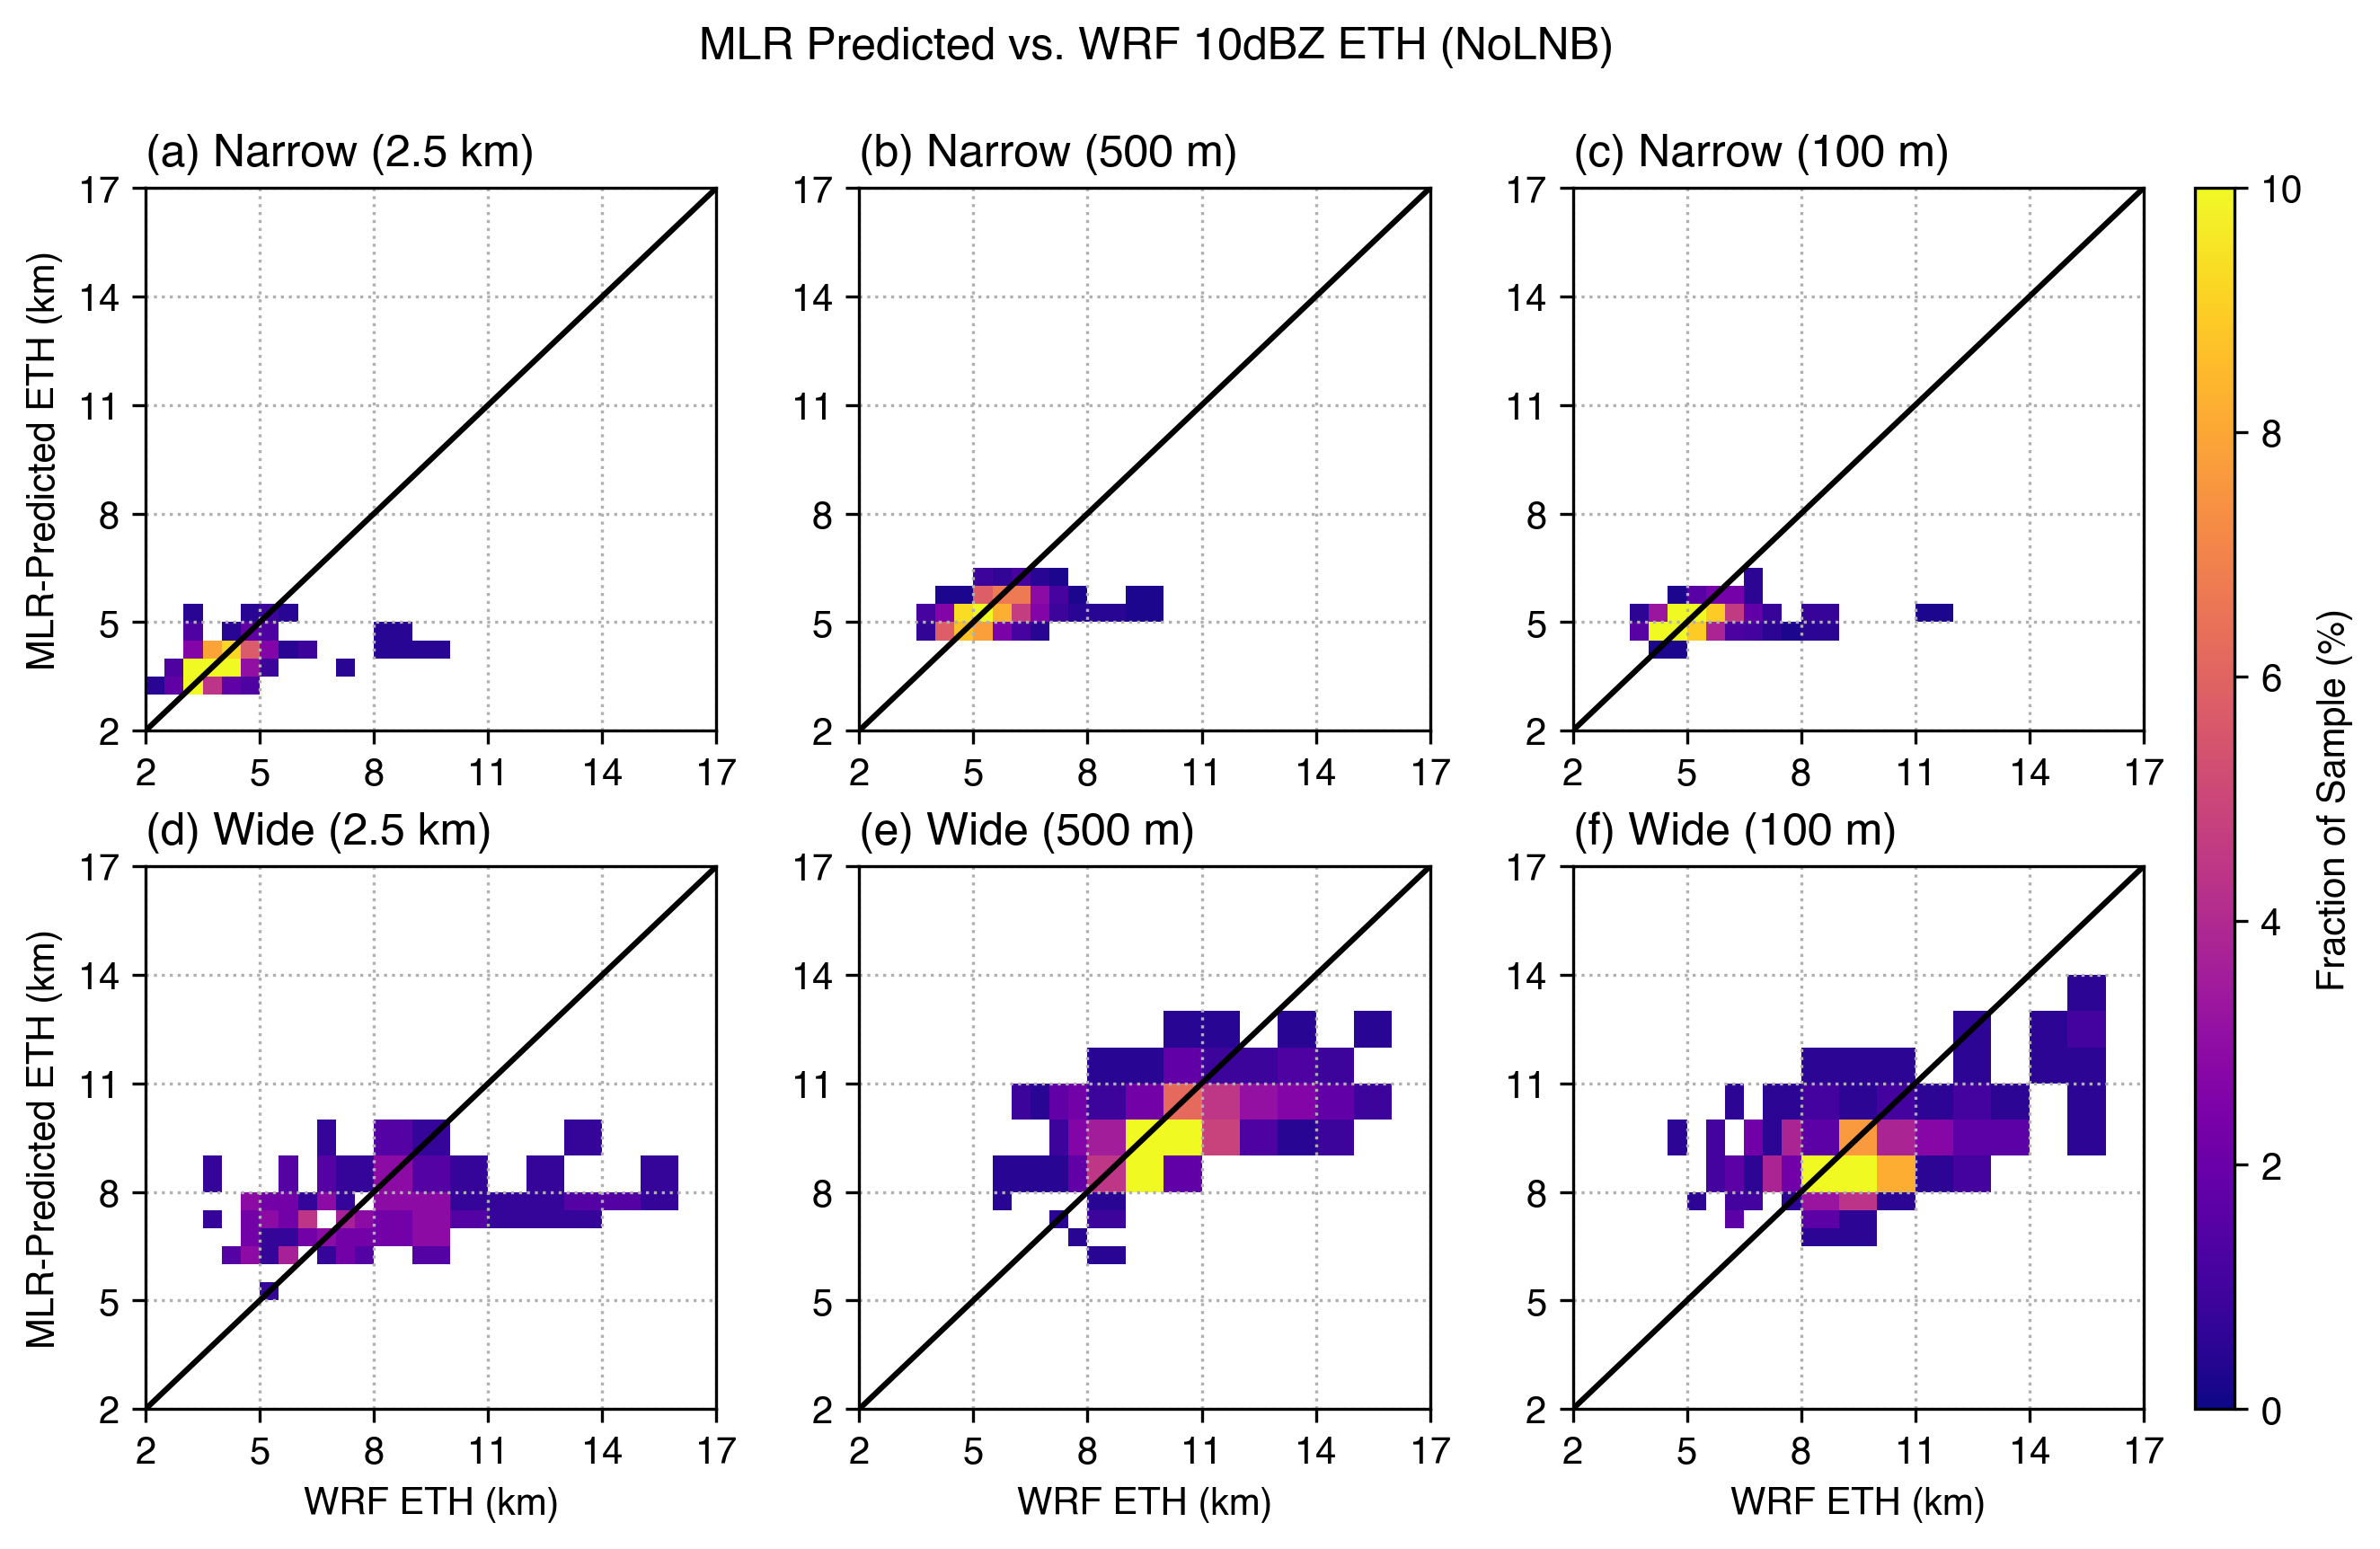

In [172]:
ETH_bins = [np.hstack((np.arange(0,8.1,0.5), np.arange(8,16.1,1)))]*2

suptitle = 'MLR Predicted vs. WRF 10dBZ ETH (NoLNB)'
x_arr = [
    [df_narrow_d2['Max 10dBZ ETH'], df_narrow_d3['Max 10dBZ ETH'], df_narrow_d4['Max 10dBZ ETH']],
    [df_wide_d2['Max 10dBZ ETH'], df_wide_d3['Max 10dBZ ETH'], df_wide_d4['Max 10dBZ ETH']],
]
y_arr = [
    [narrow_nolnb_eth_predicted_d2, narrow_nolnb_eth_predicted_d3, narrow_nolnb_eth_predicted_d4],
    [wide_nolnb_eth_predicted_d2, wide_nolnb_eth_predicted_d3, wide_nolnb_eth_predicted_d4],
]
nrow = len(x_arr)
ncol = len(x_arr[0])

# Axes, labels
xlims = (2,17)
ylims = (2,17)
xticks = np.arange(xlims[0], xlims[1]+0.1, 3)
yticks = np.arange(ylims[0], ylims[1]+0.1, 3)
xlabels = [['']*ncol,['WRF ETH (km)']*ncol]
ylabels = [['MLR-Predicted ETH (km)','','']]*nrow
titles = [['(a) Narrow (2.5 km)', '(b) Narrow (500 m)', '(c) Narrow (100 m)'],
          ['(d) Wide (2.5 km)', '(e) Wide (500 m)', '(f) Wide (100 m)']]
cbar_labels = 'Fraction of Sample (%)'
cmaps = 'plasma'
vmin, vmax = 0, 10
# Figure
fontsize = 10
figsize = (10,6)
figname = f'{figdir}Predicted_vs_Actual_ETH_NoLNB.png'
wspace = 0.25
hspace = 0.25
dpi = 300
print(figname)
fig = mxn_heatmap(nrow, ncol, x_arr, y_arr, bins_hist=ETH_bins, cmaps=cmaps, cbar_labels=cbar_labels,
                  wspace=wspace, hspace=hspace, xticks=xticks, yticks=yticks, vmin=vmin, vmax=vmax, suptitle=suptitle,
                  xlims=xlims, ylims=ylims, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/narrow_wide_CI_2.5km+1h/Predicted_vs_Actual_ETH_All.png


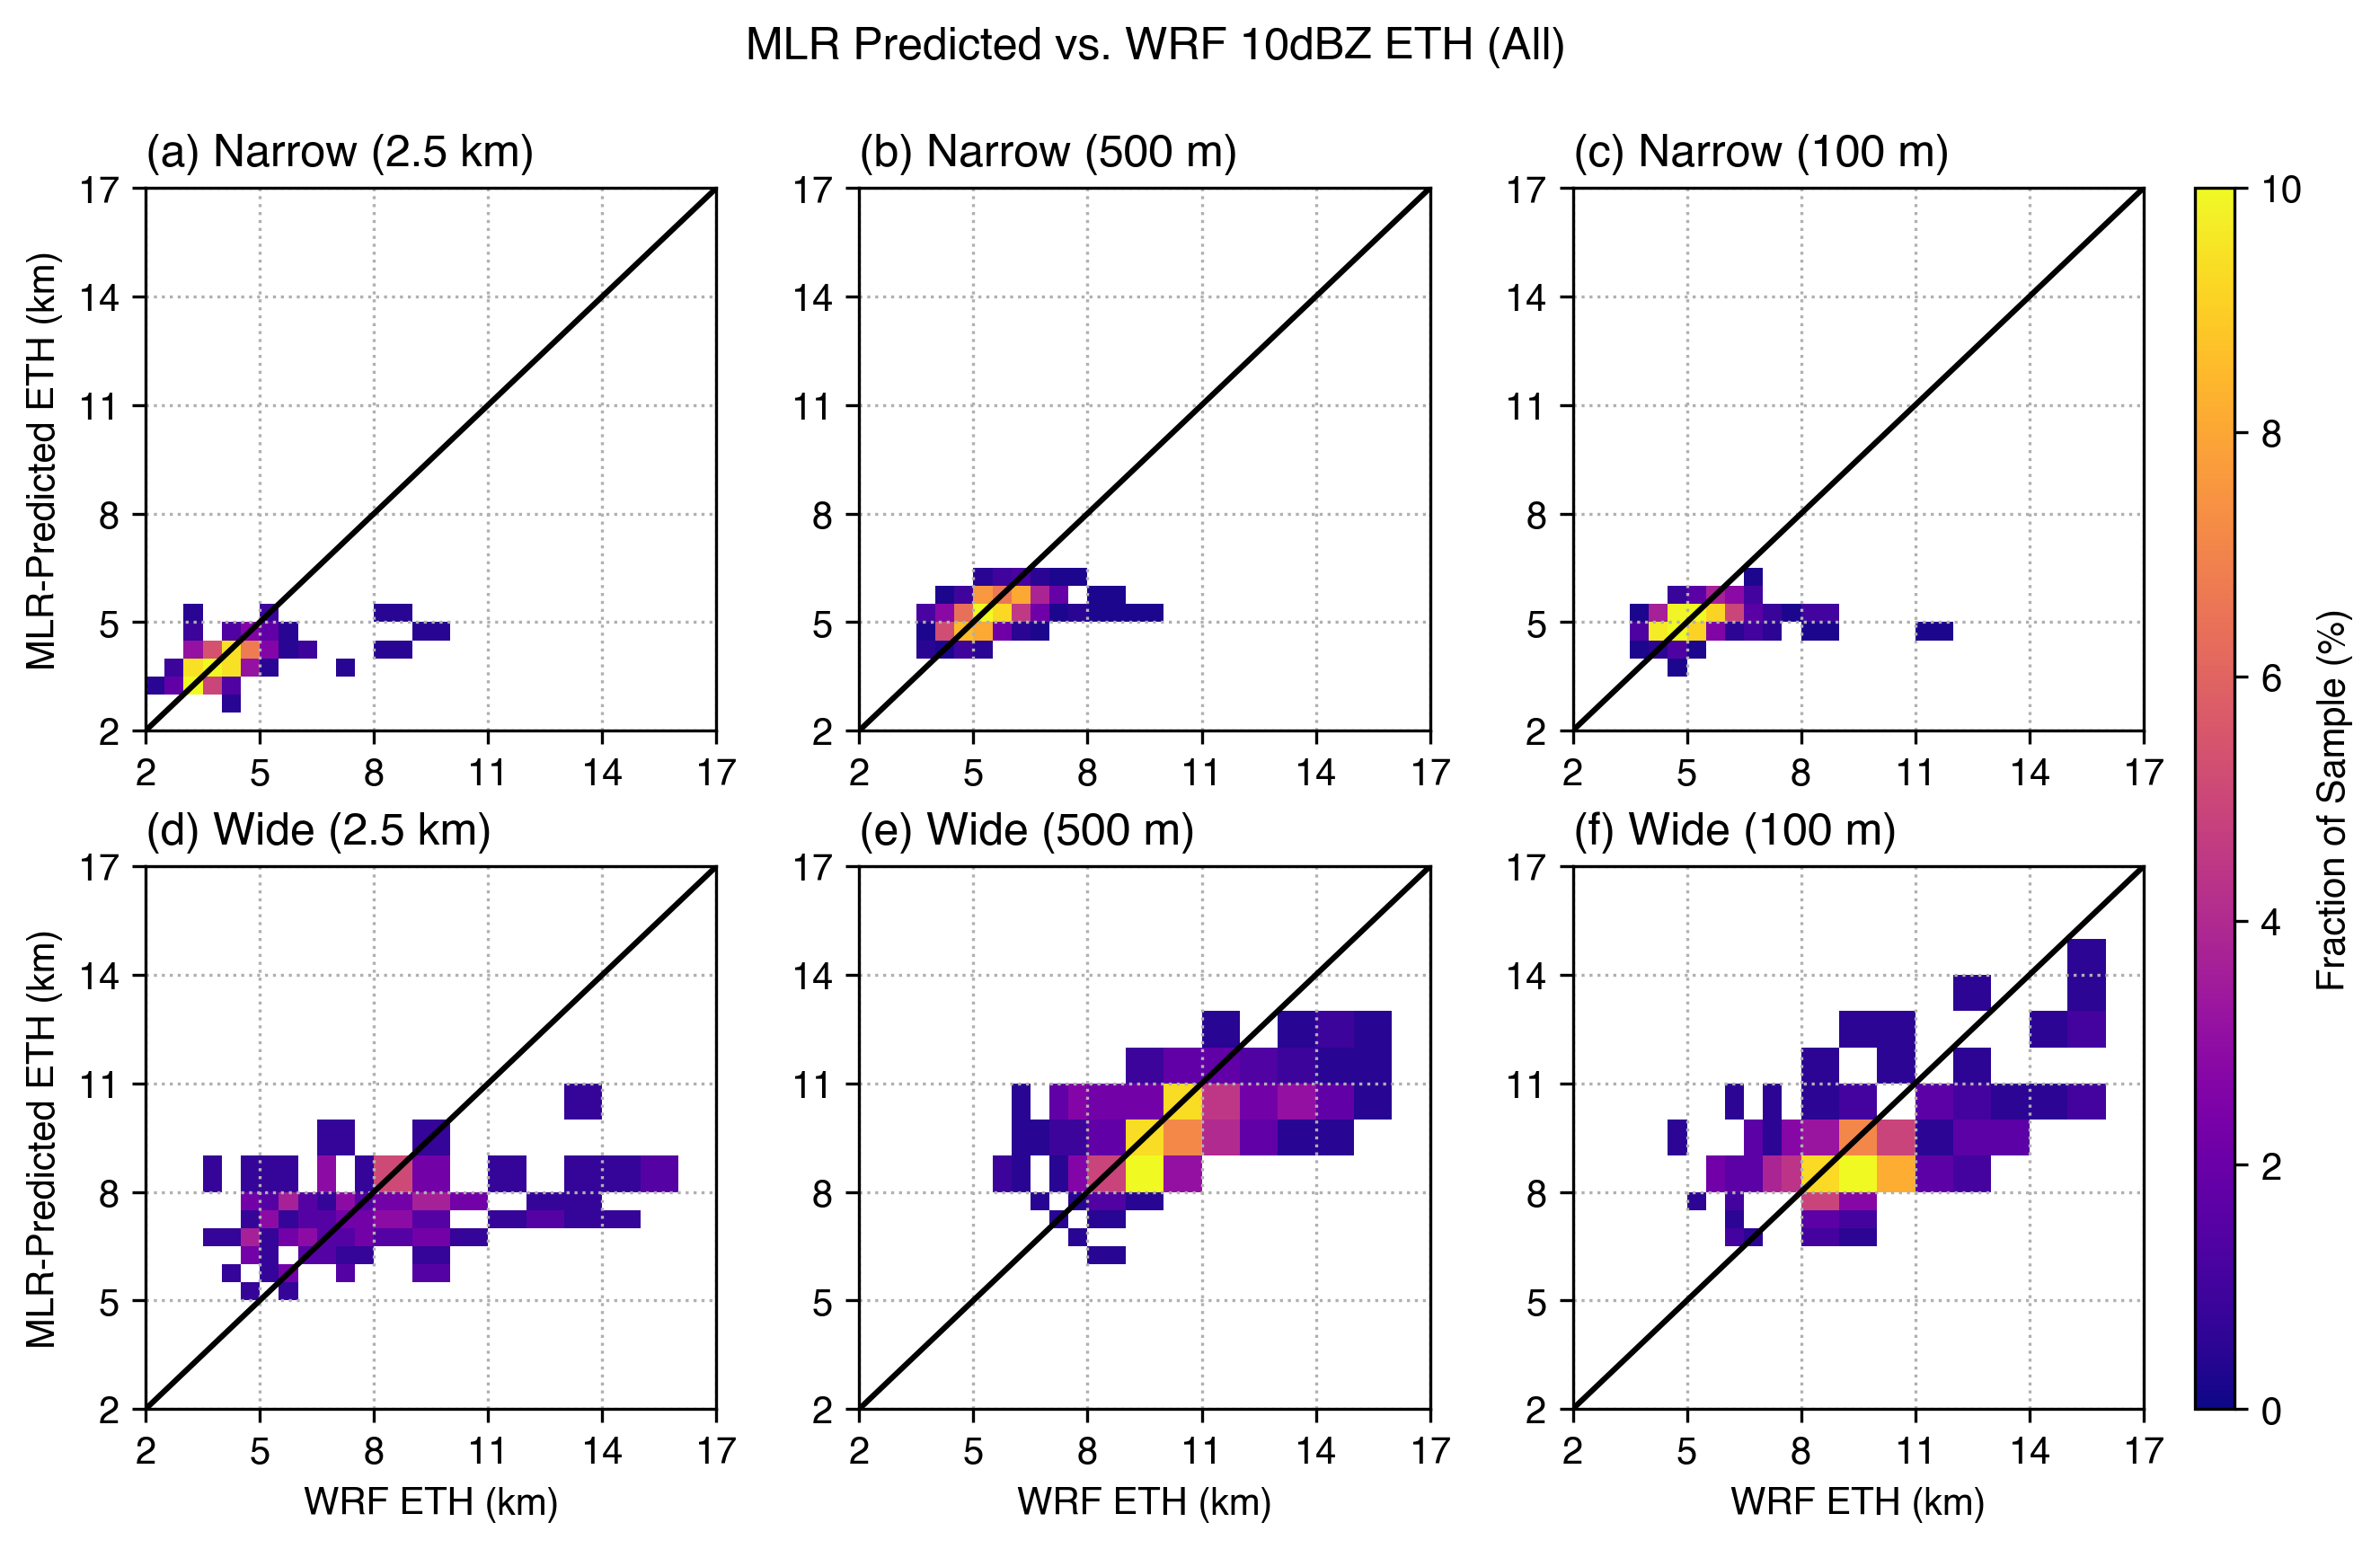

In [173]:
ETH_bins = [np.hstack((np.arange(0,8.1,0.5), np.arange(8,16.1,1)))]*2

suptitle = 'MLR Predicted vs. WRF 10dBZ ETH (All)'
x_arr = [
    [df_narrow_d2['Max 10dBZ ETH'], df_narrow_d3['Max 10dBZ ETH'], df_narrow_d4['Max 10dBZ ETH']],
    [df_wide_d2['Max 10dBZ ETH'], df_wide_d3['Max 10dBZ ETH'], df_wide_d4['Max 10dBZ ETH']],
]
y_arr = [
    [narrow_all_eth_predicted_d2, narrow_all_eth_predicted_d3, narrow_all_eth_predicted_d4],
    [wide_all_eth_predicted_d2, wide_all_eth_predicted_d3, wide_all_eth_predicted_d4],
]
nrow = len(x_arr)
ncol = len(x_arr[0])

# Axes, labels
xlims = (2,17)
ylims = (2,17)
xticks = np.arange(xlims[0], xlims[1]+0.1, 3)
yticks = np.arange(ylims[0], ylims[1]+0.1, 3)
xlabels = [['']*ncol,['WRF ETH (km)']*ncol]
ylabels = [['MLR-Predicted ETH (km)','','']]*nrow
titles = [['(a) Narrow (2.5 km)', '(b) Narrow (500 m)', '(c) Narrow (100 m)'],
          ['(d) Wide (2.5 km)', '(e) Wide (500 m)', '(f) Wide (100 m)']]
cbar_labels = 'Fraction of Sample (%)'
cmaps = 'plasma'
vmin, vmax = 0, 10
# Figure
fontsize = 10
figsize = (10,6)
figname = f'{figdir}Predicted_vs_Actual_ETH_All.png'
wspace = 0.25
hspace = 0.25
dpi = 300
print(figname)
fig = mxn_heatmap(nrow, ncol, x_arr, y_arr, bins_hist=ETH_bins, cmaps=cmaps, cbar_labels=cbar_labels,
                  wspace=wspace, hspace=hspace, xticks=xticks, yticks=yticks, vmin=vmin, vmax=vmax, suptitle=suptitle,
                  xlims=xlims, ylims=ylims, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)

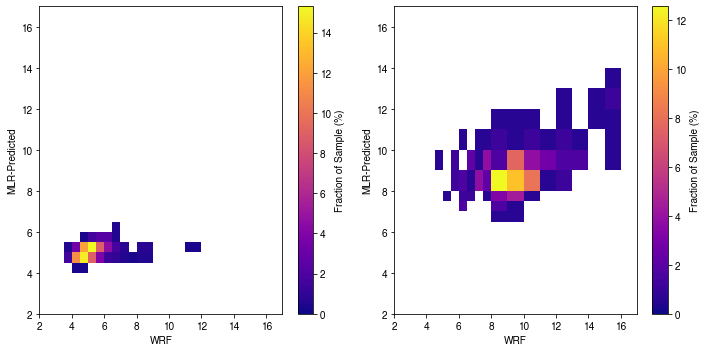

In [174]:
fig, axes = plt.subplots(1,2, figsize=(10,5))
# ETH_bins = [z_coord.values] * 2
# ETH_bins = [np.arange(0,20.1,1)]*2
ETH_bins = [np.hstack((np.arange(0,8.1,0.5), np.arange(8,16.1,1)))]*2
xlims = (2,17)
ylims = (2,17)
ax = axes[0]
pcm = sns.histplot(x=df_narrow_d4['Max 10dBZ ETH'], y=narrow_nolnb_eth_predicted_d4,  bins=ETH_bins, stat='percent',
                   cbar=True, ax=ax, cmap='plasma', cbar_kws={'label':'Fraction of Sample (%)'})
ax.set_xlim(xlims[0], xlims[1])
ax.set_ylim(ylims[0], ylims[1])
ax.set_xlabel('WRF')
ax.set_ylabel('MLR-Predicted')

ax = axes[1]
pcm = sns.histplot(x=df_wide_d4['Max 10dBZ ETH'], y=wide_nolnb_eth_predicted_d4,  bins=ETH_bins, stat='percent',
                   cbar=True, ax=ax, cmap='plasma', cbar_kws={'label':'Fraction of Sample (%)'})
ax.set_xlim(xlims[0], xlims[1])
ax.set_ylim(ylims[0], ylims[1])
ax.set_xlabel('WRF')
ax.set_ylabel('MLR-Predicted')

fig.tight_layout()